# Auto-Labeling Pipeline — Stage 1: Image-Only, Single Frame, CAM_FRONT

**Modules:**
1. SAM3 segmentation (inline text-prompted, all object classes)
2. SAM3D Body inference (pedestrians)
3. SAM3D Objects inference (all other classes, seeded with SAM3 masks + MoGe pointmap)
4. Orientation estimation (`facing_direction` for pedestrians; ambiguous long axis for objects)
5. OBB fitting (oriented bounding box in ego frame)
6. 3D visualization (k3d)

**Assumptions for stage 1:**
- No LiDAR integration (image-only; MoGe depth is relative/non-metric)
- No ground removal
- Single frame, no temporal context
- Object yaw has 180° ambiguity (pedestrians are fully resolved via skeleton)

## 0. Imports

In [1]:
import sys
import os
import shutil
import tempfile
from pathlib import Path

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes

import plotly.graph_objects as go

## 1. Config

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Dataset selector  →  change this one variable to switch datasets
# ══════════════════════════════════════════════════════════════════════════════
DATASET = 'ecp'           # 'ecp'  or  'nuscenes_mini'

# ── Per-dataset defaults ───────────────────────────────────────────────────────
if DATASET == 'nuscenes_mini':
    DATA_ROOT    = '/workspace/data/nuScenes_mini'
    NUSCENES_VER = 'v1.0-mini'
    SCENE_IDX    = 1     # mini has 10 scenes (0–9)
    FRAME_IDX    = 30
    # LiDAR aggregation — 32-beam sensor → more sweeps to compensate sparse density
    N_BEFORE = 5
    N_AFTER  = 5
    LIDAR_LINES = 32          # nuScenes: 32-beam Velodyne
    # All cameras available in nuScenes
    ALL_DATASET_CAMERAS = [
        'CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT',
        'CAM_BACK',  'CAM_BACK_LEFT',  'CAM_BACK_RIGHT',
    ]
elif DATASET == 'ecp':
    DATA_ROOT    = '/workspace/data/ecp'
    NUSCENES_VER = 'v1.0-trainval'
    SCENE_IDX    = 10    # ECP scene (GT available for 10, 11, 15)
    FRAME_IDX    = 601
    # LiDAR aggregation — 64-beam sensor → single sweep already dense
    N_BEFORE = 2
    N_AFTER  = 2
    LIDAR_LINES = 64          # ECP: 64-beam LiDAR
    # ECP frontal cameras (left-to-right order)
    ALL_DATASET_CAMERAS = [
        'CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
    ]
else:
    raise ValueError(f"Unknown DATASET: {DATASET!r}  (must be 'ecp' or 'nuscenes_mini')")

# ── Camera selection ──────────────────────────────────────────────────────────
# CAMERA      : primary / reference camera (used for single-camera visualisations
#               and as the alias target when ALL_CAMERAS=True)
# ALL_CAMERAS : True  → run on every camera in ALL_DATASET_CAMERAS
#               False → run on CAMERA only  (set CAMERA to any single camera you want)
CAMERA      = 'CAM_FRONT'
ALL_CAMERAS = False
CAMERAS     = ALL_DATASET_CAMERAS if ALL_CAMERAS else [CAMERA]

# ── LiDAR aggregation toggle ──────────────────────────────────────────────────
# When True, N_BEFORE + anchor + N_AFTER sweeps are combined after ego-motion
# compensation.  N_BEFORE / N_AFTER are set per-dataset above.
USE_AGGREGATION = True

# ── ICP motion compensation ──────────────────────────────────────────────────
# When True, per-object SE(2) ICP is run after multi-sweep tracking to
# compensate dynamic object motion.  Requires USE_AGGREGATION=True.
# ICP_N_BEFORE/AFTER control how many sweeps are used for ICP specifically
# (can be larger than N_BEFORE/N_AFTER used for the pointmap).
USE_ICP = False

# ── SAM3D result cache ────────────────────────────────────────────────────────
# When True, body_results_all / obj_results_all are saved to disk after the
# first run and loaded automatically on subsequent runs, skipping all SAM3D
# inference. Cache is keyed by dataset/scene/frame/cameras/pointmap so stale
# results from a different config are never loaded accidentally.
USE_SAM3D_CACHE = True
SAM3D_CACHE_DIR = Path('/workspace/cache/sam3d')

# ── Model checkpoints ─────────────────────────────────────────────────────────
DEV_ROOT = Path('/workspace')

from huggingface_hub import hf_hub_download
SAM3_CKPT = DEV_ROOT / 'models' / 'SAM3' / 'checkpoints' / 'sam3.pt'
SAM3_BPE  = DEV_ROOT / 'models' / 'SAM3' / 'checkpoints' / 'bpe_simple_vocab_16e6.txt.gz'

SAM3D_BODY_REPO = DEV_ROOT / 'models' / 'SAM3D' / 'sam-3d-body'
SAM3D_BODY_CKPT = SAM3D_BODY_REPO / 'checkpoints' / 'sam-3d-body-dinov3' / 'model.ckpt'
SAM3D_BODY_MHR  = SAM3D_BODY_REPO / 'checkpoints' / 'sam-3d-body-dinov3' / 'assets' / 'mhr_model.pt'

SAM3D_OBJ_REPO  = DEV_ROOT / 'models' / 'SAM3D' / 'sam-3d-objects'
SAM3D_OBJ_CFG   = SAM3D_OBJ_REPO / 'checkpoints' / 'hf' / 'pipeline.yaml'

CFORMER_ROOT = DEV_ROOT / 'models' / 'CompletionFormer'
CFORMER_CKPT = CFORMER_ROOT / 'checkpoints' / 'KITTIDC' / 'KITTIDC_L1L2.pt'

# ── SAM3 text prompts per class ───────────────────────────────────────────────
SAM3_PROMPTS = {
    'pedestrian':           'body',
    'car':                  'objects',
    'bicycle':              'objects',
    'motorcycle':           'objects',
    'bus':                  'objects',
    'truck':                'objects',
    'construction vehicle': 'objects',
    'trailer':              'objects',
}

# ── Detection thresholds ──────────────────────────────────────────────────────
SAM3_SCORE_THRESH     = 0.5
MIN_MASK_PX           = 100
BODY_BBOX_THRESH      = 0.8
SAM3_IOU_MERGE_THRESH = 0.4

# ── Pointmap mode ─────────────────────────────────────────────────────────────
#   'baseline'        — dense MoGe relative-depth pointmap (no LiDAR)
#   'o1_lidar'        — sparse metric LiDAR pointmap
#   'o2_moge_affine'  — dense MoGe + global affine fit to LiDAR
#   'o3_local_affine' — dense MoGe + per-object affine fit (HDBSCAN-filtered)
#   'o4_ground_filter'  — CompletionFormer + global PseudoLabeler ground filter (no MoGe)
#   'o5_mask_hdbscan'   — CompletionFormer + per-mask HDBSCAN anchor cleaning (no ground filter)
#   'o6_hybrid'         — CompletionFormer + PL ground filter + HDBSCAN + zero-LiDAR mask blanking
POINTMAP_MODE = 'o3_local_affine'

# ── Ego-body exclusion zone ───────────────────────────────────────────────────
USE_EGO_BODY_FILTER = True
EGO_BOX_HALF_X = 4.0
EGO_BOX_HALF_Y = 1.5
EGO_BOX_Z_MIN  = 0.5
EGO_BOX_Z_MAX  = 2.5

# ── Ego-body OBB filter ─────────────────────────────────────────────────────
# Per-camera exclusion: OBBs whose center falls within EGO_OBB_DEPTH metres
# in front of the camera (along its optical axis) are dropped as ego-vehicle
# artefacts (e.g. hood/bumper detected as 'car').
# Depth is read from camera extrinsics: t_c2e places the camera in ego space.
# Front/back cameras have more bodywork in view → larger depth;
# side/diagonal cameras are near the car edge → smaller depth.
EGO_OBB_DEPTH = {
    'CAM_FRONT':       1.0,   # [m] full hood visible
    'CAM_BACK':        1.0,   # [m] trunk visible
    'CAM_FRONT_LEFT':  1.0,   # [m] diagonal — shorter hood corner
    'CAM_FRONT_RIGHT': 1.0,
    'CAM_BACK_LEFT':   1.0,
    'CAM_BACK_RIGHT':  1.0,
    'CAM_LEFT':        0.5,   # [m] side — nearly at car edge
    'CAM_RIGHT':       0.5,
}
EGO_OBB_DEPTH_DEFAULT = 1.0   # fallback for unlisted cameras

# ── Max LiDAR range filter ────────────────────────────────────────────────────
MAX_LIDAR_RANGE_M = 100

# ── PseudoLabeler ground filter ──────────────────────────────────────────────
# Max height above the predicted road surface for a LiDAR point to be
# classified as a ground return (used in O4 sparse anchor filtering).
# Model default is 0.40 m (for semantic labeling); 0.15 m targets road-surface
# returns only, staying below the lowest bicycle frame / bumper (~0.20 m).
PL_GROUND_INLIER_THRES = 0.10   # m


# ── OBB minimum dimension filter (lenient — only catches obviously broken OBBs) ──
# Pedestrian OBB is camera-space [W, H, D]; only H (vertical) is reliable.
# Object OBBs are ego-space [L, W, H]; L = long axis from PCA.
# Set a key to None or omit it to skip that dimension check.
OBB_MIN_DIMS = {
    'pedestrian':           dict(min_h=0.5),   # H < 0.5 m → ghost/bad depth
    'bicycle':              dict(min_l=0.4),
    'motorcycle':           dict(min_l=0.6),
    'car':                  dict(min_l=1.5),
    'truck':                dict(min_l=2.0),
    'bus':                  dict(min_l=3.0),
    'trailer':              dict(min_l=2.0),
    'construction vehicle': dict(min_l=1.2),
}

USE_OBB_MIN_DIMS_FILTER = False   # per-axis dimension check

# Per-class minimum OBB volume [m^3] — volume = L x W x H (ego space for objects,
# camera space for pedestrians). Catches bad reconstructions from small/thin masks
# where depth estimation gives a collapsed or micro-sized 3-D box.
OBB_MIN_VOLUME = {
    'pedestrian':           0.1,
    'bicycle':              1.5,
    'motorcycle':           1.5,
    'car':                 10.0,
    'truck':               15.0,
    'bus':                 15.0,
    'trailer':             15.0,
    'construction vehicle':15.0,
}
USE_OBB_VOLUME_FILTER = False   # set False to skip volume check

# Per-class maximum OBB volume [m^3]. Catches badly inflated reconstructions
# (e.g. hood/roof mesh ballooning into a huge box). Set a key to None to disable.
OBB_MAX_VOLUME = {
    'pedestrian':            8.0,
    'bicycle':              15.0,
    'motorcycle':           15.0,
    'car':                  70.0,
    'truck':               300.0,
    'bus':                 300.0,
    'trailer':             300.0,
    'construction vehicle':300.0,
}

# ── BEV: drop non-local ptmap objects ────────────────────────────────────────
# When True, pseudo-label OBBs whose depth was estimated via global_fallback or
# unscaled_fallback are hidden in the BEV plot.  Set False to see everything.
# Only affects the visualisation — re-run just the BEV cell to toggle.
BEV_DROP_NON_LOCAL = False

# ── HDBSCAN — per-class parameters ────────────────────────────────────────────
HDBSCAN_PARAMS = {
    'pedestrian':           dict(min_cluster_size=3, min_samples=1, cluster_eps=0.20),
    'bicycle':              dict(min_cluster_size=3, min_samples=1, cluster_eps=0.20),
    'motorcycle':           dict(min_cluster_size=3, min_samples=1, cluster_eps=0.30),
    'car':                  dict(min_cluster_size=3, min_samples=1, cluster_eps=0.50),
    'truck':                dict(min_cluster_size=5, min_samples=1, cluster_eps=0.60),
    'construction vehicle': dict(min_cluster_size=5, min_samples=1, cluster_eps=0.60),
    'bus':                  dict(min_cluster_size=5, min_samples=1, cluster_eps=0.80),
    'trailer':              dict(min_cluster_size=5, min_samples=1, cluster_eps=0.70),
}

# ── Hull anchoring (O4 / O5 / O6) ─────────────────────────────────────────────
# When True: after CFormer dense depth, clamp depth inside each mask's convex
# hull to be >= min_depth  (= 5th-pct of dominant HDBSCAN cluster − HULL_Z_MARGIN).
# Prevents occluder (pole / sign) depth from bleeding into object interiors.
HULL_ANCHORING  = True
HULL_Z_MARGIN   = 0   # [m]  safety margin subtracted from 5th-pct cluster depth

# ── Proximity selection (O3 / O5 / O6 + hull anchoring) ──────────────────────
# When the two largest HDBSCAN clusters are similar in size
# (second >= PROXIMITY_RATIO × biggest AND biggest >= PROXIMITY_MIN_PTS),
# pick the CLOSER cluster in ego space rather than the larger one.
PROXIMITY_MIN_PTS = 30
PROXIMITY_RATIO   = 0.70

# -- Mask erosion before HDBSCAN point selection --------------------------------
# Erodes SAM3 masks by a fixed number of pixels before selecting in-mask LiDAR
# points for HDBSCAN clustering (O5 sparse map + hull anchoring).
# Removes boundary pixels where mask inaccuracy lets occluders bleed in.
# Applied equally to all connected components — small blobs may disappear.
# MASK_ERODE_MIN_PX = 0 means every mask gets eroded regardless of size.
MASK_ERODE_PX     = 3   # pixels to erode (0 = disabled)
MASK_ERODE_MIN_PX = 0   # min mask area [px] to apply erosion (0 = always)



# ── SAM3D Body B1/B2 correction ───────────────────────────────────────────────
B1_LIDAR_CORRECTION = True   # override pedestrian tz with LiDAR HDBSCAN median depth
B2_GROUND_ANCHORING = True   # anchor mesh feet to ground via PseudoLabeler MLP

_agg_str = f'aggregated ({N_BEFORE}+1+{N_AFTER} sweeps)' if USE_AGGREGATION else 'single sweep'
print(f'Dataset : {DATASET}  |  scene={SCENE_IDX}  frame={FRAME_IDX}')
print(f'Cameras : {CAMERAS}')
print(f'LiDAR   : {_agg_str}')
print(f'Pointmap: {POINTMAP_MODE!r}')
print(f'Ego-body filter: {"ON" if USE_EGO_BODY_FILTER else "OFF"}  '
      f'(|X|<{EGO_BOX_HALF_X}m, |Y|<{EGO_BOX_HALF_Y}m, Z∈[{EGO_BOX_Z_MIN}, {EGO_BOX_Z_MAX}]m)')
print(f'Max range: {MAX_LIDAR_RANGE_M} m')
print(f'SAM3 checkpoint: {SAM3_CKPT}')
if POINTMAP_MODE in ('o4_ground_filter', 'o5_mask_hdbscan', 'o6_hybrid'):
    print(f'CompletionFormer: {CFORMER_CKPT}  exists={CFORMER_CKPT.exists()}')
print(f'Body B1={B1_LIDAR_CORRECTION}  B2={B2_GROUND_ANCHORING}')

Dataset : ecp  |  scene=10  frame=601
Cameras : ['CAM_FRONT']
LiDAR   : aggregated (2+1+2 sweeps)
Pointmap: 'o3_local_affine'
Ego-body filter: ON  (|X|<4.0m, |Y|<1.5m, Z∈[0.5, 2.5]m)
Max range: 100 m
SAM3 checkpoint: /workspace/cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/sam3.pt
Body B1=True  B2=True


In [3]:
# -- Cross-camera duplicate suppression config --------------------------------
# Detections at the seam of two adjacent cameras are compared pairwise.
# A pair is treated as the same physical object when ALL of the following hold:
#   (a) left-cam mask touches the right image edge
#       (rightmost pixel x / W  >=  1 - BORDER_THRESHOLD)
#   (b) right-cam mask touches the left image edge
#       (leftmost pixel x / W   <=  BORDER_THRESHOLD)
#   (c) classes are compatible (same label or in the same compatible group)
#   (d) BEV OBB overlap >= BEV_OVERLAP_THRESH x area(smaller OBB)
# Matched greedily by descending BEV overlap. Any border candidate still
# unmatched after the main pass is paired with the best remaining option
# (fallback pass, no threshold). The detection from the smaller SAM3 mask
# is suppressed — larger mask means more object surface passed to SAM3D.

ENABLE_CROSS_CAM_MERGE = True   # set False to skip entirely
BORDER_THRESHOLD    = 0.15      # mask must reach within this fraction of image width
BEV_OVERLAP_THRESH  = 0.10      # min overlap / area(smaller OBB) for the main pass

COMPATIBLE_CLASS_GROUPS = [
    {'car', 'truck', 'bus'},
    {'motorcycle', 'bicycle'},
    {'truck', 'trailer'},
]

# Adjacent camera pairs (left_cam, right_cam) in angular sweep order
if DATASET == 'nuscenes_mini':
    ADJACENT_CAM_PAIRS = [
        ('CAM_FRONT_LEFT',  'CAM_FRONT'),
        ('CAM_FRONT',       'CAM_FRONT_RIGHT'),
        ('CAM_FRONT_RIGHT', 'CAM_BACK_RIGHT'),
        ('CAM_BACK_RIGHT',  'CAM_BACK'),
        ('CAM_BACK',        'CAM_BACK_LEFT'),
        ('CAM_BACK_LEFT',   'CAM_FRONT_LEFT'),
    ]
elif DATASET == 'ecp':
    ADJACENT_CAM_PAIRS = [
        ('CAM_FRONT_LEFT', 'CAM_FRONT'),
        ('CAM_FRONT',      'CAM_FRONT_RIGHT'),
    ]

_pair_str = [f"{l.split('_',1)[1]}<->{r.split('_',1)[1]}" for l, r in ADJACENT_CAM_PAIRS]
print(f'Cross-cam merge: {"ON" if ENABLE_CROSS_CAM_MERGE else "OFF"}'
      f'  border={BORDER_THRESHOLD}  bev_overlap>={BEV_OVERLAP_THRESH:.0%}'
      f'  pairs={_pair_str}')


Cross-cam merge: ON  border=0.15  bev_overlap>=10%  pairs=['FRONT_LEFT<->FRONT', 'FRONT<->FRONT_RIGHT']


## 2. Path Setup
Models are loaded sequentially — each section loads its model, runs inference, then unloads before the next model is loaded. This keeps peak GPU memory to one model at a time.

In [4]:
import gc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')

# Add all repo paths once here so each section can import without repeating sys.path inserts
sys.path.insert(0, str(SAM3D_BODY_REPO))
sys.path.insert(0, str(SAM3D_OBJ_REPO / 'notebook'))
sys.path.insert(0, str(SAM3D_OBJ_REPO))
os.environ['LIDRA_SKIP_INIT'] = 'true'

print('Paths configured. Models will be loaded sequentially in each section.')

Paths configured. Models will be loaded sequentially in each section.


## 3. Data Loading
Load the selected frame: image, camera intrinsics, and camera-to-ego extrinsics.

Scene index   : 10 → scene-euro-citystrasbourg-scenariolatesession-00002_1
Raw frames    : 2481  (camera ~12 Hz, FRAME_IDX range: 0–2480)
Keyframes     : 2481  (annotated at ~2 Hz, pipeline processes these)

  CAM_FRONT: 1920x1024  /workspace/data/ecp/samples/CAM_FRONT/Euro-cityStrasbourg-scenarioLateSession_00002_1_2016-10-26-18-22-57__CAM_FRONT__1477499050048554240.jpg

Frame 601: KEYFRAME 601/2480 (has GT annotations)


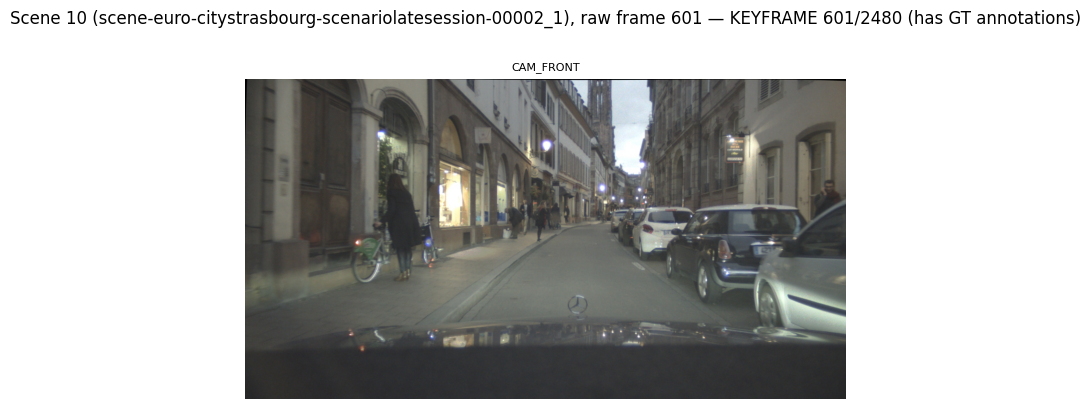

In [5]:
def load_frame(nusc, scene_idx, frame_idx, camera='CAM_FRONT'):
    """
    Load image, intrinsics, and camera-to-ego extrinsics for one frame.

    frame_idx indexes raw sample_data frames (~12 Hz), NOT keyframes (~2 Hz).
    Use is_key_frame to check whether a given frame has GT annotations.

    Returns
    -------
    img_bgr       : (H, W, 3) uint8 BGR image
    img_rgb       : (H, W, 3) uint8 RGB image
    K             : (3, 3) float64 camera intrinsics
    R_c2e         : (3, 3) float64 rotation camera -> ego
    t_c2e         : (3,)   float64 translation camera -> ego
    img_path      : str    absolute path to image file
    cam_sd_token  : str    nuScenes sample_data token for this camera frame
    """
    scene   = nusc.scene[scene_idx]
    token   = nusc.get('sample', scene['first_sample_token'])['data'][camera]
    for _ in range(frame_idx):
        rec   = nusc.get('sample_data', token)
        token = rec['next']
        assert token, f'frame_idx {frame_idx} exceeds scene length'

    rec      = nusc.get('sample_data', token)
    img_path = nusc.get_sample_data_path(token)
    cal      = nusc.get('calibrated_sensor', rec['calibrated_sensor_token'])

    K     = np.array(cal['camera_intrinsic'], dtype=np.float64)
    R_c2e = Quaternion(cal['rotation']).rotation_matrix.astype(np.float64)
    t_c2e = np.array(cal['translation'], dtype=np.float64)

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb, img_bgr, K, R_c2e, t_c2e, img_path, token


nusc = NuScenes(version=NUSCENES_VER, dataroot=DATA_ROOT, verbose=False)

# ── Scene / frame metadata ────────────────────────────────────────────────────
_scene_rec  = nusc.scene[SCENE_IDX]
scene_name  = _scene_rec['name']         # e.g. "scene-0061"
n_keyframes = _scene_rec['nbr_samples']  # annotated frames at 2 Hz

# Total raw camera frames in this scene (walk sample_data chain once for CAM_FRONT)
_t_raw = nusc.get('sample', _scene_rec['first_sample_token'])['data'][CAMERA]
_n_raw = 0
while _t_raw:
    _n_raw += 1
    _t_raw  = nusc.get('sample_data', _t_raw)['next']

print(f'Scene index   : {SCENE_IDX} → {scene_name}')
print(f'Raw frames    : {_n_raw}  (camera ~12 Hz, FRAME_IDX range: 0–{_n_raw-1})')
print(f'Keyframes     : {n_keyframes}  (annotated at ~2 Hz, pipeline processes these)')
print()

# ── Load all requested cameras ────────────────────────────────────────────────
cam_data = {}
for _cam in CAMERAS:
    _img_rgb, _img_bgr, _K, _R_c2e, _t_c2e, _img_path, _sd_token = load_frame(
        nusc, SCENE_IDX, FRAME_IDX, _cam
    )
    _H, _W = _img_rgb.shape[:2]
    _fx, _fy, _cx, _cy = _K[0,0], _K[1,1], _K[0,2], _K[1,2]
    cam_data[_cam] = dict(
        img_rgb=_img_rgb, img_bgr=_img_bgr, K=_K,
        R_c2e=_R_c2e, t_c2e=_t_c2e,
        img_path=_img_path, cam_sd_token=_sd_token,
        H=_H, W=_W, fx=_fx, fy=_fy, cx=_cx, cy=_cy,
    )
    print(f'  {_cam}: {_W}x{_H}  {_img_path}')

# ── Ego pose at anchor timestamp (shared across all cameras at a keyframe) ────
_anchor_sd = nusc.get('sample_data', cam_data[CAMERA]['cam_sd_token'])
_anchor_ep = nusc.get('ego_pose', _anchor_sd['ego_pose_token'])
R_e2g_anchor = Quaternion(_anchor_ep['rotation']).rotation_matrix.astype(np.float64)
t_e2g_anchor = np.array(_anchor_ep['translation'], dtype=np.float64)

# ── Is this frame a keyframe? Which keyframe index / nearest keyframes? ───────
def _keyframe_index(nusc, scene_rec, sample_token):
    """Return 0-based keyframe index for a given sample token."""
    _t, _i = scene_rec['first_sample_token'], 0
    while _t and _t != sample_token:
        _t = nusc.get('sample', _t)['next']
        _i += 1
    return _i

_sd_rec = nusc.get('sample_data', cam_data[CAMERA]['cam_sd_token'])
_is_key = _sd_rec['is_key_frame']

if _is_key:
    _kf_idx      = _keyframe_index(nusc, _scene_rec, _sd_rec['sample_token'])
    _frame_label = f'KEYFRAME {_kf_idx}/{n_keyframes-1} (has GT annotations)'
else:
    # Walk backwards to nearest preceding keyframe
    _t_b, _steps_b, _kf_prev = _sd_rec['prev'], 0, None
    while _t_b:
        _steps_b += 1
        _sd_b = nusc.get('sample_data', _t_b)
        if _sd_b['is_key_frame']:
            _kf_prev = _keyframe_index(nusc, _scene_rec, _sd_b['sample_token'])
            break
        _t_b = _sd_b['prev']

    # Walk forwards to nearest following keyframe
    _t_f, _steps_f, _kf_next = _sd_rec['next'], 0, None
    while _t_f:
        _steps_f += 1
        _sd_f = nusc.get('sample_data', _t_f)
        if _sd_f['is_key_frame']:
            _kf_next = _keyframe_index(nusc, _scene_rec, _sd_f['sample_token'])
            break
        _t_f = _sd_f['next']

    _parts = []
    if _kf_prev is not None:
        _parts.append(f'KF {_kf_prev}/{n_keyframes-1} ({_steps_b} back)')
    if _kf_next is not None:
        _parts.append(f'KF {_kf_next}/{n_keyframes-1} ({_steps_f} ahead)')
    _frame_label = f'non-keyframe — nearest: {" | ".join(_parts)}'

print(f'\nFrame {FRAME_IDX}: {_frame_label}')

# ── Primary camera aliases (used by single-camera downstream cells) ───────────
img_rgb, img_bgr  = cam_data[CAMERA]['img_rgb'], cam_data[CAMERA]['img_bgr']
K                 = cam_data[CAMERA]['K']
R_c2e, t_c2e     = cam_data[CAMERA]['R_c2e'], cam_data[CAMERA]['t_c2e']
img_path          = cam_data[CAMERA]['img_path']
cam_sd_token      = cam_data[CAMERA]['cam_sd_token']
H, W              = cam_data[CAMERA]['H'], cam_data[CAMERA]['W']
fx, fy, cx, cy    = cam_data[CAMERA]['fx'], cam_data[CAMERA]['fy'], cam_data[CAMERA]['cx'], cam_data[CAMERA]['cy']

# ── Show all cameras ──────────────────────────────────────────────────────────
n_cams = len(CAMERAS)
fig, axes = plt.subplots(1, n_cams, figsize=(14 * n_cams / max(n_cams, 1), 4))
if n_cams == 1:
    axes = [axes]
for ax, _cam in zip(axes, CAMERAS):
    ax.imshow(cam_data[_cam]['img_rgb'])
    ax.axis('off')
    ax.set_title(_cam, fontsize=8)
plt.suptitle(f'Scene {SCENE_IDX} ({scene_name}), raw frame {FRAME_IDX} — {_frame_label}', y=1.01)
plt.tight_layout()
plt.show()

## 3.5 LiDAR Loading and Camera Projection
Load the timestamp-synced LIDAR_TOP sweep and project visible points into the camera frame.
Produces `pts_ego_vis`, `pts_cam_vis`, `u_vis`, `v_vis`, `Z_vis` used downstream by O1.

In [6]:
# ── Helper: walk LiDAR linked list, skip ECP duplicate file entries ───────────
def _walk_lidar_tokens(nusc, anchor_token, n_before, n_after):
    anchor_path = nusc.get_sample_data_path(anchor_token)
    seen_paths  = {anchor_path}

    backward = []
    tok = nusc.get('sample_data', anchor_token)['prev']
    while tok and len(backward) < n_before:
        path = nusc.get_sample_data_path(tok)
        if path not in seen_paths:
            backward.append(tok)
            seen_paths.add(path)
        tok = nusc.get('sample_data', tok)['prev']

    tokens = []
    for i, t in enumerate(reversed(backward)):
        tokens.append((-(len(backward) - i), t))
    tokens.append((0, anchor_token))

    count = 0
    tok   = nusc.get('sample_data', anchor_token)['next']
    while tok and count < n_after:
        path = nusc.get_sample_data_path(tok)
        if path not in seen_paths:
            count += 1
            tokens.append((count, tok))
            seen_paths.add(path)
        tok = nusc.get('sample_data', tok)['next']

    return tokens   # (rel_idx, token), chronological


def _load_sweep_ego(nusc, tok, R_e2g_anchor, t_e2g_anchor):
    """Load one sweep, transform to anchor ego frame, return (N,3) float64."""
    sd       = nusc.get('sample_data', tok)
    lid_cal  = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
    ego_pose = nusc.get('ego_pose', sd['ego_pose_token'])
    lid_path = nusc.get_sample_data_path(tok)

    R_l2e    = Quaternion(lid_cal['rotation']).rotation_matrix.astype(np.float64)
    t_l2e    = np.array(lid_cal['translation'], dtype=np.float64)
    R_e2g_sw = Quaternion(ego_pose['rotation']).rotation_matrix.astype(np.float64)
    t_e2g_sw = np.array(ego_pose['translation'], dtype=np.float64)

    pts_raw     = np.fromfile(lid_path, dtype=np.float32).reshape(-1, 5)[:, :3].astype(np.float64)
    pts_ego_sw  = (R_l2e @ pts_raw.T).T + t_l2e
    # ── Ego-body filter in sweep's own ego frame (vehicle always at origin) ──
    if USE_EGO_BODY_FILTER:
        _sw_box = (
            (np.abs(pts_ego_sw[:, 0]) < EGO_BOX_HALF_X) &
            (np.abs(pts_ego_sw[:, 1]) < EGO_BOX_HALF_Y) &
            (pts_ego_sw[:, 2] > EGO_BOX_Z_MIN) &
            (pts_ego_sw[:, 2] < EGO_BOX_Z_MAX)
        )
        pts_ego_sw = pts_ego_sw[~_sw_box]
    pts_global  = (R_e2g_sw @ pts_ego_sw.T).T + t_e2g_sw
    pts_ego_anc = (R_e2g_anchor.T @ (pts_global - t_e2g_anchor).T).T
    return pts_ego_anc, Path(lid_path).name


# ── Find anchor LiDAR sweep ───────────────────────────────────────────────────
# Uses the primary camera's sample_data token; all cameras at a keyframe share
# the same LIDAR_TOP sample, so the choice of camera here doesn't matter.
cam_sd = nusc.get('sample_data', cam_sd_token)
cam_ts = cam_sd['timestamp']

if cam_sd['is_key_frame']:
    _sample     = nusc.get('sample', cam_sd['sample_token'])
    lidar_token = _sample['data']['LIDAR_TOP']
else:
    lidar_token = min(
        (sd for sd in nusc.sample_data if sd['channel'] == 'LIDAR_TOP'),
        key=lambda sd: abs(sd['timestamp'] - cam_ts),
    )['token']

# ── Load: single sweep or aggregated ─────────────────────────────────────────
if not USE_AGGREGATION:
    pts_ego, _fname = _load_sweep_ego(nusc, lidar_token, R_e2g_anchor, t_e2g_anchor)
    _lidar_sd = nusc.get('sample_data', lidar_token)
    _dt_ms    = abs(cam_ts - _lidar_sd['timestamp']) / 1_000.0
    print(f'LiDAR (single sweep): {len(pts_ego):,} pts  dt={_dt_ms:.1f} ms  ({_fname})')
else:
    _sweep_tokens = _walk_lidar_tokens(nusc, lidar_token, N_BEFORE, N_AFTER)
    _all_pts = []
    print(f'LiDAR aggregation: {len(_sweep_tokens)} unique sweep(s)')
    for _rel_idx, _tok in _sweep_tokens:
        _sweep_pts, _fname = _load_sweep_ego(nusc, _tok, R_e2g_anchor, t_e2g_anchor)
        _sd_info = nusc.get('sample_data', _tok)
        _dt_ms   = (_sd_info['timestamp'] - cam_ts) / 1_000.0
        _all_pts.append(_sweep_pts)
        _tag = '  <- anchor' if _rel_idx == 0 else ''
        print(f'  [{_rel_idx:+d}]  {len(_sweep_pts):6,} pts  dt={_dt_ms:+7.1f} ms  {_fname}{_tag}')
    pts_ego = np.concatenate(_all_pts, axis=0)
    print(f'  Total: {len(pts_ego):,} pts')

# ── Per-sweep data for ICP motion compensation ───────────────────────────────
# Per-sweep data for ICP: reuse the same N_BEFORE/N_AFTER window already loaded.
icp_sweep_data = []   # [{rel_idx, dt_ms, pts_ego_anc}], chronological
if USE_ICP and USE_AGGREGATION:
    _icp_tokens = _walk_lidar_tokens(nusc, lidar_token, N_BEFORE, N_AFTER)
    for _ri, _tok in _icp_tokens:
        _sp, _ = _load_sweep_ego(nusc, _tok, R_e2g_anchor, t_e2g_anchor)
        _dt    = (nusc.get('sample_data', _tok)['timestamp'] - cam_ts) / 1_000.0
        icp_sweep_data.append(dict(rel_idx=_ri, dt_ms=_dt,
                                   pts_ego_anc=_sp.astype(np.float32)))
    _n_icp = len(icp_sweep_data)
    _anc_i = next(i for i, s in enumerate(icp_sweep_data) if s['rel_idx'] == 0)
    print(f'ICP sweep data: {_n_icp} sweep(s), anchor at index {_anc_i}')
elif USE_ICP:
    print('USE_ICP=True requires USE_AGGREGATION=True — ICP disabled.')
    USE_ICP = False

# Ego-body filter applied per-sweep above (in each sweep's own ego frame).

# ── Max range filter ──────────────────────────────────────────────────────────
_bev_range = np.sqrt(pts_ego[:, 0]**2 + pts_ego[:, 1]**2)
_n_range   = len(pts_ego)
pts_ego    = pts_ego[_bev_range <= MAX_LIDAR_RANGE_M]
print(f'  Range filter ({MAX_LIDAR_RANGE_M} m): removed {_n_range - len(pts_ego):,} pts → {len(pts_ego):,} remaining')

# ── Project LiDAR into each camera ───────────────────────────────────────────
# pts_ego is camera-independent (ego frame); projection differs per camera.
cam_lidar = {}
print(f'\nProjecting {len(pts_ego):,} pts into {len(CAMERAS)} camera(s):')
for _cam, _cd in cam_data.items():
    _K = _cd['K']
    _fx, _fy, _cx, _cy = _K[0,0], _K[1,1], _K[0,2], _K[1,2]
    _H_c, _W_c = _cd['H'], _cd['W']
    _R_c2e, _t_c2e = _cd['R_c2e'], _cd['t_c2e']

    _pts_cam = (_R_c2e.T @ (pts_ego - _t_c2e).T).T
    _Z_cam   = _pts_cam[:, 2]
    _front   = _Z_cam > 0
    _u_proj  = _pts_cam[_front, 0] / _Z_cam[_front] * _fx + _cx
    _v_proj  = _pts_cam[_front, 1] / _Z_cam[_front] * _fy + _cy
    _in_img  = (_u_proj >= 0) & (_u_proj < _W_c) & (_v_proj >= 0) & (_v_proj < _H_c)

    _pts_ego_vis = pts_ego[_front][_in_img].astype(np.float32)
    _u_vis       = _u_proj[_in_img].astype(np.float32)
    _v_vis       = _v_proj[_in_img].astype(np.float32)
    _Z_vis       = _pts_cam[_front][_in_img][:, 2].astype(np.float32)
    _pts_cam_vis = _pts_cam[_front][_in_img].astype(np.float32)

    cam_lidar[_cam] = dict(
        pts_ego_vis=_pts_ego_vis, pts_cam_vis=_pts_cam_vis,
        u_vis=_u_vis, v_vis=_v_vis, Z_vis=_Z_vis,
        H=_H_c, W=_W_c,
    )
    _z_rng = (f'{float(_Z_vis.min()):.1f}–{float(_Z_vis.max()):.1f} m'
              if len(_Z_vis) else 'no points in image')
    print(f'  {_cam}: {len(_pts_ego_vis):,} visible pts  ({_z_rng})')

# ── Primary camera aliases ────────────────────────────────────────────────────
pts_ego_vis = cam_lidar[CAMERA]['pts_ego_vis']
pts_cam_vis = cam_lidar[CAMERA]['pts_cam_vis']
u_vis       = cam_lidar[CAMERA]['u_vis']
v_vis       = cam_lidar[CAMERA]['v_vis']
Z_vis       = cam_lidar[CAMERA]['Z_vis']
_mode_str = f'aggregated ({N_BEFORE}+1+{N_AFTER} sweeps)' if USE_AGGREGATION else 'single sweep'
print(f'\nPrimary camera ({CAMERA}): {len(pts_ego_vis):,} visible pts  [{_mode_str}]')



LiDAR aggregation: 5 unique sweep(s)
  [-2]  74,492 pts  dt= -158.0 ms  Euro-cityStrasbourg-scenarioLateSession_00002_1_2016-10-26-18-22-57__LIDAR_TOP__1477499049890567936.pcd.bin
  [-1]  74,409 pts  dt=  -90.3 ms  Euro-cityStrasbourg-scenarioLateSession_00002_1_2016-10-26-18-22-57__LIDAR_TOP__1477499049958247936.pcd.bin
  [+0]  74,275 pts  dt=  -22.6 ms  Euro-cityStrasbourg-scenarioLateSession_00002_1_2016-10-26-18-22-57__LIDAR_TOP__1477499050025933056.pcd.bin  <- anchor
  [+1]  74,032 pts  dt=  +45.1 ms  Euro-cityStrasbourg-scenarioLateSession_00002_1_2016-10-26-18-22-57__LIDAR_TOP__1477499050093617920.pcd.bin
  [+2]  74,082 pts  dt= +112.9 ms  Euro-cityStrasbourg-scenarioLateSession_00002_1_2016-10-26-18-22-57__LIDAR_TOP__1477499050161442048.pcd.bin
  Total: 371,290 pts
ICP sweep data: 5 sweep(s), anchor at index 2
  Range filter (100 m): removed 44 pts → 371,246 remaining

Projecting 371,246 pts into 1 camera(s):
  CAM_FRONT: 56,266 visible pts  (2.6–95.2 m)

Primary camera (CAM_FR

In [7]:
# ── 3.6 PseudoLabeler — Ground Surface Fitting (O4 / O6) ────────────────────
# When POINTMAP_MODE in ('o4_ground_filter', 'o6_hybrid'), fit a PseudoLabeler MLP  gθ: R²→R  on
# the full aggregated LiDAR cloud (ego frame).  The fitted model is used to
# strip ground-plane returns from each camera's visible point set before they
# are passed to CompletionFormer as sparse depth anchors.  This fixes the
# misalignment where road-surface returns (4–6 m) are min-depth-selected over
# the actual object surface (e.g. bicycle at 8 m).
#
# The model is stored in `pseudolabeler_model` so it can be reused by SAM3D
# Body B2 ground anchoring (Section 5.6) further below.
# It is ALSO fitted when B2_GROUND_ANCHORING=True (regardless of POINTMAP_MODE).

import sys as _sys_pl
_pl_path = str(DEV_ROOT / 'models' / 'TerraSeg' / 'PseudoLabeler_scripts')
_device_pl = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pseudolabeler_model = None

if POINTMAP_MODE in ('o4_ground_filter', 'o6_hybrid') or B2_GROUND_ANCHORING:
    if _pl_path not in _sys_pl.path:
        _sys_pl.path.insert(0, _pl_path)
    from pseudolabeler_model import PseudoLabeler
    from pseudolabeler_loss  import pseudolabeler_loss as _pl_loss

    _pl_model = PseudoLabeler().to(_device_pl)
    _pl_model.train()

    # Preprocess: remove ego vehicle self-returns and bottom noise
    _pc = torch.tensor(pts_ego, dtype=torch.float32).to(_device_pl)
    _pc = _pl_model.remove_ego_points(_pc)
    _pc = _pl_model.preprocess_denoise_pc(_pc)
    print(f'PseudoLabeler fitting on {len(_pc):,} pts from {len(pts_ego):,} raw...')

    _n_steps  = 2500
    _n_warmup = 200   # steps before early stopping kicks in
    _patience = 300   # stop if loss hasn't improved for this many steps after warmup
    _opt = torch.optim.AdamW(_pl_model.parameters(), lr=1e-2, weight_decay=1e-4)
    _sch = torch.optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=_n_steps, eta_min=1e-4)
    _best_loss, _best_state, _no_improve = float('inf'), None, 0

    for _step in range(_n_steps):
        _opt.zero_grad()
        _pred = _pl_model(_pc)
        _loss = _pl_loss(_pred, _pc[:, 2])
        _l = _loss.item()
        # Track best and count patience only AFTER warmup.  Tracking from step 0 causes
        # the random-init low loss (pred≈0, flat ground≈0) to pollute best_loss, and the
        # recovered model never beats it → patience fires at warmup+patience every time.
        if _step >= _n_warmup:
            if _l < _best_loss:
                _best_loss  = _l
                _best_state = {k: v.detach().cpu() for k, v in _pl_model.state_dict().items()}
                _no_improve = 0
            else:
                _no_improve += 1
                if _no_improve >= _patience:
                    break
        _loss.backward()
        torch.nn.utils.clip_grad_norm_(_pl_model.parameters(), 5.0)
        _opt.step()
        _sch.step()

    if _best_state:
        _pl_model.load_state_dict(_best_state)
    _pl_model.eval().to(_device_pl)
    pseudolabeler_model = _pl_model
    print(f'done  (loss={_best_loss:.5f}, steps={_step + 1})')
else:
    print('Skipping PseudoLabeler fit — not in O4/O6 mode and B2_GROUND_ANCHORING=False.')

PseudoLabeler fitting on 288,485 pts from 371,246 raw...
done  (loss=0.01866, steps=593)


## 4. SAM3 Segmentation
Run SAM3 inline with a text prompt for each class. A separate session is opened per class (same pattern as `get_sam3_masks_for_nuscenes_trainval.py`).

In [8]:
from sam3.model_builder import build_sam3_video_predictor

print('Loading SAM3...')
gpus = range(torch.cuda.device_count())
sam3_predictor = build_sam3_video_predictor(gpus_to_use=gpus, checkpoint_path=str(SAM3_CKPT),
                                            bpe_path=str(SAM3_BPE))
print('  SAM3 ready.')


def run_sam3_single_frame(predictor, img_rgb, text_prompt, score_thresh=0.5, min_mask_px=100):
    """
    Run SAM3 with a text prompt on a single frame.

    The image is written to a temp directory as a single-frame 'video',
    then SAM3 propagates over it and the session is closed.

    Parameters
    ----------
    predictor    : SAM3 video predictor instance
    img_rgb      : (H, W, 3) uint8 RGB image
    text_prompt  : str  e.g. 'car', 'pedestrian', 'bicycle and cyclist'
    score_thresh : float  min object probability to keep
    min_mask_px  : int    min mask area to keep

    Returns
    -------
    detections : list of dicts, each with:
        'binary_mask'  : (H, W) bool
        'score'        : float
        'box_xywh'     : (4,) float  normalised [x, y, w, h]
        'prompt'       : str
    """
    tmp_dir = tempfile.mkdtemp(prefix='sam3_frame_')
    try:
        Image.fromarray(img_rgb).save(os.path.join(tmp_dir, '00000.jpg'))
        resp       = predictor.handle_request(dict(type='start_session', resource_path=tmp_dir))
        session_id = resp['session_id']
        predictor.handle_request(dict(
            type='add_prompt', session_id=session_id, frame_index=0, text=text_prompt
        ))
        frame_outputs = {}
        with torch.autocast('cuda', dtype=torch.bfloat16):
            for resp in predictor.handle_stream_request(dict(
                type='propagate_in_video', session_id=session_id
            )):
                frame_outputs[resp['frame_index']] = resp['outputs']
        predictor.handle_request(dict(type='close_session', session_id=session_id))
    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)

    out      = frame_outputs.get(0, {})
    obj_ids  = out.get('out_obj_ids', [])
    probs    = np.asarray(out.get('out_probs', []), dtype=np.float32)
    masks    = out.get('out_binary_masks', [])
    boxes    = np.asarray(out.get('out_boxes_xywh', []), dtype=np.float32)

    detections = []
    for i, (oid, prob) in enumerate(zip(obj_ids, probs)):
        if prob < score_thresh:
            continue
        bm = np.asarray(masks[i], dtype=bool)
        if bm.sum() < min_mask_px:
            continue
        detections.append({
            'binary_mask': bm,
            'score':       float(prob),
            'box_xywh':    boxes[i] if len(boxes) > i else None,
            'prompt':      text_prompt,
        })
    return detections




# ── Run SAM3 for all cameras ──────────────────────────────────────────────────
sam3_results_all = {}
for _cam in CAMERAS:
    print(f'\n─── {_cam} ───')
    _img_rgb  = cam_data[_cam]['img_rgb']
    _cam_res  = {}
    for prompt, pipeline in SAM3_PROMPTS.items():
        print(f'  "{prompt}" ...', end=' ', flush=True)
        dets = run_sam3_single_frame(
            sam3_predictor, _img_rgb, prompt,
            score_thresh=SAM3_SCORE_THRESH, min_mask_px=MIN_MASK_PX
        )
        _cam_res[prompt] = dets
        print(f'{len(dets)} det(s)')
    sam3_results_all[_cam] = _cam_res
    print(f'  Total: {sum(len(v) for v in _cam_res.values())} detection(s)')

# ── Primary camera alias ──────────────────────────────────────────────────────
sam3_results = sam3_results_all[CAMERA]


INFO 2026-09-20 16:24:45,552 35317 sam3_video_predictor.py: 299: using the following GPU IDs: [0]
INFO 2026-09-20 16:24:45,553 35317 sam3_video_predictor.py: 315: 


	*** START loading model on all ranks ***


INFO 2026-09-20 16:24:45,553 35317 sam3_video_predictor.py: 317: loading model on rank=0 with world_size=1 -- this could take a while ...


Loading SAM3...


INFO 2026-09-20 16:24:52,610 35317 sam3_video_base.py: 124: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-09-20 16:25:05,132 35317 sam3_video_predictor.py: 319: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-09-20 16:25:05,198 35317 sam3_video_predictor.py: 330: 


	*** DONE loading model on all ranks ***




  SAM3 ready.

─── CAM_FRONT ───
  "pedestrian" ... 

frame loading (image folder) [rank=0]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.54it/s]


...

frame loading (image folder) [rank=0]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 45.52it/s]


propagate_in_video:   0%|          | 0/1 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-09-20 16:25:23,003 35317 sam3_video_predictor.py: 250: removed session 53a741ed-fc6b-4420-9de8-b8080ba354bf; live sessions: [], GPU memory: 5551 MiB used and 6736 MiB reserved (max over time: 6255 MiB used and 6736 MiB reserved)


0 det(s)
  Total: 16 detection(s)


In [9]:
# ── Cross-class deduplication ─────────────────────────────────────────────────
CROSS_CLASS_PRIORITY = {
    'pedestrian':           0,
    'car':                  1,
    'bicycle':              2,
    'truck':                3,
    'motorcycle':           4,
    'trailer':              5,
    'bus':                  6,
    'construction vehicle': 7,
}
CROSS_CLASS_IOU_THRESH = 0.5


def dedup_cross_class(results, iou_thresh=CROSS_CLASS_IOU_THRESH, priority=CROSS_CLASS_PRIORITY):
    flat = [(p, d) for p, dets in results.items() for d in dets]
    keep = [True] * len(flat)
    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            if not keep[i] or not keep[j]:
                continue
            p_i, d_i = flat[i]
            p_j, d_j = flat[j]
            if p_i == p_j:
                continue
            a, b  = d_i['binary_mask'], d_j['binary_mask']
            inter = np.logical_and(a, b).sum()
            if inter == 0:
                continue
            iou = inter / np.logical_or(a, b).sum()
            if iou < iou_thresh:
                continue
            if priority.get(p_i, 0) >= priority.get(p_j, 0):
                keep[j] = False
            else:
                keep[i] = False

    out = {p: [] for p in results}
    for (p, d), k in zip(flat, keep):
        if k:
            out[p].append(d)

    removed = sum(1 for k in keep if not k)
    print(f'  removed {removed} duplicate(s)  (IoU thresh={iou_thresh})')
    return out


# ── Apply dedup per camera ────────────────────────────────────────────────────
for _cam in CAMERAS:
    print(f'\n─── {_cam} ───')
    sam3_results_all[_cam] = dedup_cross_class(sam3_results_all[_cam])
    _total = sum(len(v) for v in sam3_results_all[_cam].values())
    for p, dets in sam3_results_all[_cam].items():
        if dets:
            print(f'    {p}: {len(dets)}')
    print(f'  → {_total} detection(s)')

# ── Primary camera alias ──────────────────────────────────────────────────────
sam3_results = sam3_results_all[CAMERA]



─── CAM_FRONT ───
  removed 0 duplicate(s)  (IoU thresh=0.5)
    pedestrian: 8
    car: 6
    bicycle: 2
  → 16 detection(s)


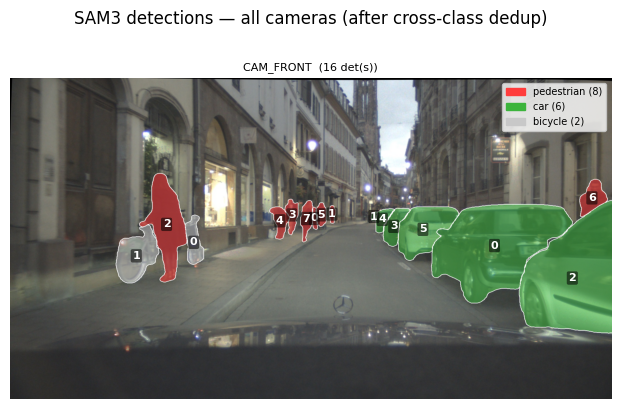

In [10]:
# ── Class colour map ──────────────────────────────────────────────────────────
CLASS_COLORS = {
    'pedestrian':           np.array([255,  60,  60], dtype=np.float32),
    'car':                  np.array([ 60, 180,  60], dtype=np.float32),
    'bicycle and cyclist':  np.array([ 60, 120, 255], dtype=np.float32),
    'motorcycle':           np.array([255, 160,   0], dtype=np.float32),
    'bus':                  np.array([180,  60, 255], dtype=np.float32),
    'truck':                np.array([  0, 210, 210], dtype=np.float32),
    'construction vehicle': np.array([255,  80, 180], dtype=np.float32),
    'trailer':              np.array([140, 200,  60], dtype=np.float32),
}
OUTLINE_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# ── Visualise SAM3 masks for every camera ─────────────────────────────────────
n_cams = len(CAMERAS)
_ncols = min(n_cams, 3)
_nrows = (n_cams + _ncols - 1) // _ncols
fig, axes = plt.subplots(_nrows, _ncols, figsize=(14, 4 * _nrows), squeeze=False)
axes_flat = [ax for row in axes for ax in row]

for _i, _cam in enumerate(CAMERAS):
    ax = axes_flat[_i]
    _img_rgb = cam_data[_cam]['img_rgb']
    _sam3    = sam3_results_all[_cam]
    _H_c, _W_c = _img_rgb.shape[:2]

    overlay = _img_rgb.copy().astype(np.float32)
    outline_layer = np.zeros((_H_c, _W_c), dtype=bool)

    for prompt, dets in _sam3.items():
        col = CLASS_COLORS.get(prompt, np.array([200, 200, 200], dtype=np.float32))
        for d in dets:
            mask = d['binary_mask']
            overlay[mask] = overlay[mask] * 0.45 + col * 0.55

    for prompt, dets in _sam3.items():
        for d in dets:
            mask_u8 = d['binary_mask'].astype(np.uint8) * 255
            dilated = cv2.dilate(mask_u8, OUTLINE_KERNEL)
            outline = (dilated > 0) & ~d['binary_mask']
            outline_layer |= outline
    overlay[outline_layer] = np.array([255, 255, 255], dtype=np.float32)

    ax.imshow(overlay.astype(np.uint8))
    ax.axis('off')
    n_dets = sum(len(v) for v in _sam3.values())
    ax.set_title(f'{_cam}  ({n_dets} det(s))', fontsize=8)

    for prompt, dets in _sam3.items():
        for i, d in enumerate(dets):
            ys, xs = np.where(d['binary_mask'])
            if not len(xs):
                continue
            ax.text(float(xs.mean()), float(ys.mean()), str(i),
                    color='white', fontsize=8, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.55, ec='none'))

# Legend — total counts across ALL cameras
_class_totals = {}
for _cam in CAMERAS:
    for prompt, dets in sam3_results_all[_cam].items():
        _class_totals[prompt] = _class_totals.get(prompt, 0) + len(dets)
legend_patches = [
    patches.Patch(
        color=CLASS_COLORS.get(prompt, np.array([200, 200, 200], dtype=np.float32)) / 255,
        label=f'{prompt} ({count})',
    )
    for prompt, count in _class_totals.items() if count > 0
]
# Hide unused axes
for ax in axes_flat[n_cams:]:
    ax.axis('off')

if legend_patches and n_cams > 0:
    axes_flat[n_cams - 1].legend(handles=legend_patches, loc='upper right', fontsize=7,
                                  bbox_to_anchor=(1.0, 1.0))

plt.suptitle('SAM3 detections — all cameras (after cross-class dedup)', y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# Unload SAM3 before loading the next model
del sam3_predictor
gc.collect()
torch.cuda.empty_cache()
print(f'SAM3 unloaded. GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB')

SAM3 unloaded. GPU free: 41.7 GB


## 4.5 ICP Motion Compensation

For each camera × SAM3 mask, two phases run before classification:

**Phase 1 — Tracking** (no alignment): Starting from the anchor sweep (t=0), walks
forward then backward in time, cropping a local ROI around the last known centroid
and running HDBSCAN to find the object cluster in each sweep. Z pre-filtered before
HDBSCAN using `anchor_z_min + CLASS_MAX_HEIGHT_M` as ceiling (robust even when roof
is not visible). Centroid trail used for turning detection.

**Phase 2 — ICP alignment** (grows target): Processes sweeps in alternating order
`t+1, t-1, t+2, t-2, …` aligning each sweep to a growing cloud `_agg_pts` (starts
as anchor, accumulates compensated sweeps). This gives ICP increasingly richer shape
coverage. Sweeps where Phase 1 found no cluster are skipped (gate on `_sw_cents[i]`).

**ICP details**:
- `allow_yaw=True` only for turning objects (detected via `_icp_trajectory_yaw_rate`)
- `metric='p2l'` (point-to-plane) for flat-surface classes (car, truck, bus, van, construction vehicle)
- `metric='p2p'` (point-to-point) for 3D-structure classes (pedestrian, bicycle, motorcycle)
- `ICP_MAX_CORRESP=0.4 m` — tight because centroid init already handles coarse offset

**Final cloud**:
- Dynamic: concatenation of all ICP-compensated per-sweep clusters
- Static: all raw in-mask points from all sweeps → HDBSCAN dominant cluster

**Fallback** when `USE_ICP=False` or no sweep data: single-sweep anchor in-mask points
→ HDBSCAN → dominant cluster → same output format for downstream SAM3D compatibility.

Results in `motion_results_all[cam][mask_idx]`:
- `pts_comp_all` — motion-compensated ego-frame cloud fed to SAM3D Objects
- `velocity_mps`, `heading_rad`, `is_dynamic`


In [12]:
import cv2 as _cv2_icp
import open3d as _o3d_icp
import hdbscan as _hdbscan_icp
from itertools import zip_longest as _zip_longest

# ══════════════════════════════════════════════════════════════════════════════
# ICP config
# ══════════════════════════════════════════════════════════════════════════════
_ICP_MASK_ERODE_PX       = 4
_ICP_MAX_CORRESP         = 0.4    # [m] max point-pair distance in ICP (centroid init → small residual)
_ICP_MAX_ITER            = 60
_ICP_MIN_PTS             = 2      # min pts for any cluster to be valid
_ICP_MIN_PTS_ICP         = 8      # min pts to attempt ICP (else centroid-only)
_ICP_Z_FLOOR_SLACK       = 0.20   # [m] extra slack below anchor bottom
_ICP_TURNING_YAW_RATE    = 5.0    # [deg/s] threshold — above: turning (yaw in ICP), below: translation-only

_ICP_CLASS_MAX_HEIGHT_M = {       # ceiling = anchor_z_min + this (bottom is always visible; robust to invisible roof)
    'car': 2.2, 'van': 2.7, 'truck': 4.5, 'bus': 5.0,
    'motorcycle': 2.2, 'bicycle': 2.5, 'pedestrian': 2.5,
    'construction vehicle': 5.0, 'construction_vehicle': 5.0, 'trailer': 4.5,
}
_ICP_DEFAULT_MAX_HEIGHT_M = 3.5

_ICP_CLASS_METRIC = {             # ICP correspondence metric per class
    'car': 'p2l', 'van': 'p2l', 'truck': 'p2l', 'bus': 'p2l',
    'construction vehicle': 'p2l', 'construction_vehicle': 'p2l',
    'motorcycle': 'p2p', 'bicycle': 'p2p', 'pedestrian': 'p2p', 'trailer': 'p2p',
}
_ICP_DEFAULT_METRIC = 'p2p'

_ICP_HDB_PARAMS = {
    'pedestrian':           dict(min_cluster_size=2, min_samples=1, cluster_eps=0.20),
    'bicycle':              dict(min_cluster_size=2, min_samples=1, cluster_eps=0.20),
    'motorcycle':           dict(min_cluster_size=2, min_samples=1, cluster_eps=0.30),
    'car':                  dict(min_cluster_size=2, min_samples=1, cluster_eps=0.50),
    'truck':                dict(min_cluster_size=2, min_samples=1, cluster_eps=0.60),
    'construction vehicle': dict(min_cluster_size=2, min_samples=1, cluster_eps=0.60),
    'construction_vehicle': dict(min_cluster_size=2, min_samples=1, cluster_eps=0.60),
    'bus':                  dict(min_cluster_size=2, min_samples=1, cluster_eps=0.80),
    'trailer':              dict(min_cluster_size=2, min_samples=1, cluster_eps=0.70),
}
_ICP_HDB_DEFAULT = dict(min_cluster_size=2, min_samples=1, cluster_eps=0.50)

_ICP_DYN_THRESH = {
    'car': 2.5, 'truck': 2.5, 'bus': 2.5, 'van': 2.5, 'trailer': 2.5,
    'motorcycle': 1.5, 'bicycle': 1.0, 'pedestrian': 0.8,
    'construction vehicle': 2.5, 'construction_vehicle': 2.5,
}
_ICP_RADIUS = {
    'car': 2.5, 'truck': 3.5, 'bus': 4.0, 'van': 3.0, 'trailer': 4.0,
    'motorcycle': 1.5, 'bicycle': 1.2, 'pedestrian': 1.0,
    'construction vehicle': 4.0, 'construction_vehicle': 4.0,
}
_ICP_MAX_SPD = {
    'car': 20.0, 'truck': 15.0, 'bus': 15.0, 'van': 18.0, 'trailer': 10.0,
    'motorcycle': 25.0, 'bicycle': 8.0, 'pedestrian': 3.0,
    'construction vehicle': 10.0, 'construction_vehicle': 10.0,
}

import sys as _sys_icp
_AL_SRC_ICP = '/workspace/autolabeling/src'
if _AL_SRC_ICP not in _sys_icp.path:
    _sys_icp.path.insert(0, _AL_SRC_ICP)
from autolabeling.utils.lidar import filter_inmask_lidar_hdbscan as _fimh

# ══════════════════════════════════════════════════════════════════════════════
# Helper functions
# ══════════════════════════════════════════════════════════════════════════════

def _icp_erode(mask, px):
    if px <= 0: return mask
    k = _cv2_icp.getStructuringElement(_cv2_icp.MORPH_ELLIPSE, (2*px+1, 2*px+1))
    return _cv2_icp.erode(mask.astype(np.uint8), k).astype(bool)

def _icp_dominant(pts, hdb):
    if len(pts) < _ICP_MIN_PTS: return None, None
    keep = _fimh(pts, min_cluster_size=hdb['min_cluster_size'],
                 min_samples=hdb['min_samples'], cluster_eps=hdb['cluster_eps'])
    if keep is None: return None, None
    cl = pts[keep]
    return (cl, cl[:, :2].mean(0)) if len(cl) >= _ICP_MIN_PTS else (None, None)

def _icp_dominant_near(pts, search_xy, hdb):
    if len(pts) < _ICP_MIN_PTS: return None, None
    labels = _hdbscan_icp.HDBSCAN(
        min_cluster_size=hdb['min_cluster_size'], min_samples=hdb['min_samples'],
        metric='euclidean', cluster_selection_epsilon=hdb['cluster_eps'],
    ).fit_predict(pts)
    unique = [l for l in np.unique(labels) if l >= 0]
    if not unique: return None, None
    clusters = sorted(
        [(pts[labels == l], pts[labels == l][:, :2].mean(0)) for l in unique],
        key=lambda x: -len(x[0]),
    )
    cl, cent = min(clusters[:3], key=lambda x: np.linalg.norm(x[1] - search_xy))
    return (cl, cent) if len(cl) >= _ICP_MIN_PTS else (None, None)

def _icp_crop(pts, cx, r):
    m = ((pts[:, 0] >= cx[0]-r) & (pts[:, 0] <= cx[0]+r) &
         (pts[:, 1] >= cx[1]-r) & (pts[:, 1] <= cx[1]+r))
    return pts[m]

def _icp_project_into_cam(pts_ego, cd):
    K, R_c2e, t_c2e = cd['K'], cd['R_c2e'], cd['t_c2e']
    H, W = cd['H'], cd['W']
    fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
    p = (R_c2e.T @ (pts_ego.astype(np.float64) - t_c2e).T).T
    fwd = p[:, 2] > 0
    u = p[fwd, 0] / p[fwd, 2] * fx + cx
    v = p[fwd, 1] / p[fwd, 2] * fy + cy
    in_img = (u >= 0) & (u < W) & (v >= 0) & (v < H)
    vis_idx = np.where(fwd)[0][in_img]
    return pts_ego[vis_idx].astype(np.float32), u[in_img].astype(np.float32), v[in_img].astype(np.float32), p[fwd][in_img][:, 2].astype(np.float32)

def _icp_centroid_T(src, tgt):
    d = tgt[:, :2].mean(0) - src[:, :2].mean(0)
    T = np.eye(4); T[0,3]=d[0]; T[1,3]=d[1]
    return T, float(d[0]), float(d[1])

def _icp_apply(pts, T):
    return (T @ np.hstack([pts, np.ones((len(pts),1))]).T).T[:,:3]

def _icp_se2(src, tgt, init_T, allow_yaw=False, metric='p2p'):
    """SE(2) ICP.  allow_yaw=True only for turning objects (trajectory-detected).
    metric='p2p': point-to-point (pedestrian, cyclist — 3D structure).
    metric='p2l': point-to-plane (car/truck — flat side walls, fixes lateral smear).
    """
    def _fp(p, with_normals=False):
        f = p.copy(); f[:,2] = 0.
        pc = _o3d_icp.geometry.PointCloud()
        pc.points = _o3d_icp.utility.Vector3dVector(f.astype(np.float64))
        if with_normals:
            pc.estimate_normals(_o3d_icp.geometry.KDTreeSearchParamHybrid(
                radius=_ICP_MAX_CORRESP * 3, max_nn=30))
            pc.orient_normals_towards_camera_location([0., 0., 100.])
        return pc
    if metric == 'p2l':
        pcd_src = _fp(src, False); pcd_tgt = _fp(tgt, True)
        estimation = _o3d_icp.pipelines.registration.TransformationEstimationPointToPlane()
    else:
        pcd_src = _fp(src); pcd_tgt = _fp(tgt)
        estimation = _o3d_icp.pipelines.registration.TransformationEstimationPointToPoint()
    res = _o3d_icp.pipelines.registration.registration_icp(
        pcd_src, pcd_tgt, _ICP_MAX_CORRESP, init_T, estimation,
        _o3d_icp.pipelines.registration.ICPConvergenceCriteria(max_iteration=_ICP_MAX_ITER),
    )
    T = np.asarray(res.transformation)
    yaw = float(np.arctan2(T[1,0], T[0,0]))
    tx, ty = float(T[0,3]), float(T[1,3])
    T2 = np.eye(4)
    if allow_yaw:
        T2[0,0]=np.cos(yaw); T2[0,1]=-np.sin(yaw)
        T2[1,0]=np.sin(yaw); T2[1,1]= np.cos(yaw)
    T2[0,3]=tx; T2[1,3]=ty
    return T2, float(res.fitness), float(res.inlier_rmse), tx, ty, float(np.degrees(yaw))

def _icp_trajectory_yaw_rate(sw_cents, sw_data):
    """Estimate yaw rate (deg/s) from centroid trail — two-half lstsq regression.
    Robust to per-sweep centroid noise: random jitter averages within each half
    instead of accumulating step-by-step.  Returns 0 if trail is too short or
    total displacement < 1 m (static object).
    """
    txy = [(s['dt_ms']/1000., c[0], c[1])
           for s, c in zip(sw_data, sw_cents) if c is not None]
    if len(txy) < 4: return 0.
    txy = np.array(txy)
    t, x, y = txy[:,0], txy[:,1], txy[:,2]
    if np.hypot(x[-1]-x[0], y[-1]-y[0]) < 1.0: return 0.
    def _fit_h(ts, xs, ys):
        A = np.stack([ts, np.ones(len(ts))], 1)
        vx = np.linalg.lstsq(A, xs, rcond=None)[0][0]
        vy = np.linalg.lstsq(A, ys, rcond=None)[0][0]
        return float(np.degrees(np.arctan2(vy, vx))) if np.hypot(vx, vy) >= 0.1 else None
    mid = len(txy)//2
    h1 = _fit_h(t[:mid], x[:mid], y[:mid])
    h2 = _fit_h(t[mid:], x[mid:], y[mid:])
    if h1 is None or h2 is None: return 0.
    dh = (h2-h1+180)%360-180
    total = abs(t[-1]-t[0])
    return abs(dh)/total if total > 0 else 0.

def _icp_heading_lstsq(sw_cents, sw_data, anc_i):
    txy = [(s['dt_ms']/1000., sw_cents[i][0], sw_cents[i][1])
           for i, s in enumerate(sw_data)
           if i != anc_i and sw_cents[i] is not None]
    if len(txy) < 2: return float('nan')
    txy = np.array(txy)
    A = np.stack([txy[:,0], np.ones(len(txy))], 1)
    vx = np.linalg.lstsq(A, txy[:,1], rcond=None)[0][0]
    vy = np.linalg.lstsq(A, txy[:,2], rcond=None)[0][0]
    return float(np.arctan2(vy, vx))

def _icp_static_orientation(pts):
    xy = pts[:,:2]
    if len(xy) < 2: return float('nan')
    xy_c = xy - xy.mean(0)
    _, _, Vt = np.linalg.svd(xy_c, full_matrices=False)
    return float(np.arctan2(Vt[0,1], Vt[0,0])) % np.pi

# ══════════════════════════════════════════════════════════════════════════════
# Main ICP loop
# ══════════════════════════════════════════════════════════════════════════════
motion_results_all = {}   # [cam][mask_idx] → dict

if not (USE_ICP and USE_AGGREGATION and icp_sweep_data):
    # ── Fallback: no sweep data or ICP disabled ────────────────────────────────
    # Use all in-mask LiDAR from the single anchor sweep + HDBSCAN dominant
    # cluster as the point cloud fed to SAM3D Objects — same as pre-ICP pipeline.
    print('ICP motion compensation: skipped (USE_ICP=False or no sweep data)')
    print('Falling back to single-sweep in-mask HDBSCAN per mask.')
    _anc_i_fb = next((i for i, s in enumerate(icp_sweep_data) if s['rel_idx'] == 0), 0) if icp_sweep_data else 0
    for _cam in CAMERAS:
        _cd  = cam_data[_cam]
        _sam = [dict(prompt=p, binary_mask=d['binary_mask'], score=d['score'])
                for p, dets in sam3_results_all[_cam].items() for d in dets]
        motion_results_all[_cam] = {}
        # Project anchor sweep into camera
        _anc_sd = (icp_sweep_data[_anc_i_fb] if icp_sweep_data
                   else {'pts_ego_anc': pts_ego})
        _pts_anc, _u_anc, _v_anc, _Z_anc = _icp_project_into_cam(
            _anc_sd['pts_ego_anc'], _cd)
        for _mi, _minfo in enumerate(_sam):
            _hdb = _ICP_HDB_PARAMS.get(_minfo['prompt'], _ICP_HDB_DEFAULT)
            _er  = _icp_erode(_minfo['binary_mask'], _ICP_MASK_ERODE_PX)
            _H_c, _W_c = _cd['H'], _cd['W']
            _in_fr = (_u_anc >= 0) & (_u_anc < _W_c) & (_v_anc >= 0) & (_v_anc < _H_c)
            _ui = _u_anc[_in_fr].astype(np.int32); _vi = _v_anc[_in_fr].astype(np.int32)
            _raw = _pts_anc[_in_fr][_er[_vi, _ui]]
            _cl, _ = _icp_dominant(_raw, _hdb)
            _comp_all = _cl if (_cl is not None and len(_cl) >= _ICP_MIN_PTS) else _raw
            _comp_pts_vis, _comp_u, _comp_v, _comp_Z = (
                _icp_project_into_cam(_comp_all, _cd) if len(_comp_all) > 0
                else (np.empty((0,3), np.float32), np.array([], np.float32),
                      np.array([], np.float32), np.array([], np.float32)))
            motion_results_all[_cam][_mi] = dict(
                prompt=_minfo['prompt'], is_dynamic=False,
                velocity_mps=0., heading_rad=float('nan'),
                n_sweeps=0, anc_pts=_raw, pts_comp_all=_comp_all,
                comp_pts_vis=_comp_pts_vis, comp_u=_comp_u,
                comp_v=_comp_v, comp_Z=_comp_Z,
            )
else:
    _n_sw  = len(icp_sweep_data)
    _anc_i = next(i for i, s in enumerate(icp_sweep_data) if s['rel_idx'] == 0)
    _ICP_Z_GROUND_MIN = 0.15   # [m] rough Z floor — TerraSeg not available here
    _sw_ng = [s['pts_ego_anc'][s['pts_ego_anc'][:, 2] >= _ICP_Z_GROUND_MIN]
              for s in icp_sweep_data]

    for _cam in CAMERAS:
        _cd  = cam_data[_cam]
        _sam = [dict(prompt=p, binary_mask=d['binary_mask'], score=d['score'])
                for p, dets in sam3_results_all[_cam].items() for d in dets]
        motion_results_all[_cam] = {}
        print(f'\n─── ICP {_cam}  ({len(_sam)} mask(s)) ───')

        _H_c, _W_c = _cd['H'], _cd['W']
        _er_masks = [_icp_erode(m['binary_mask'], _ICP_MASK_ERODE_PX) for m in _sam]

        # Pre-project each sweep into this camera
        _sw_uv = []
        for _sd in icp_sweep_data:
            _pts = _sd['pts_ego_anc']
            K, R_c2e, t_c2e = _cd['K'], _cd['R_c2e'], _cd['t_c2e']
            fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
            _pc  = (R_c2e.T @ (_pts.astype(np.float64) - t_c2e).T).T
            _fwd = _pc[:,2] > 0
            _u   = np.full(len(_pts), -1., np.float32)
            _v   = np.full(len(_pts), -1., np.float32)
            _ur  = _pc[_fwd,0]/_pc[_fwd,2]*fx+cx
            _vr  = _pc[_fwd,1]/_pc[_fwd,2]*fy+cy
            _in  = (_ur>=0)&(_ur<_W_c)&(_vr>=0)&(_vr<_H_c)
            _vi2 = np.where(_fwd)[0]
            _u[_vi2[_in]] = _ur[_in]; _v[_vi2[_in]] = _vr[_in]
            _sw_uv.append(np.stack([_u,_v], axis=1))

        def _get_inmask_pts(mask_2d, sw_idx):
            uv = _sw_uv[sw_idx]; in_fr = uv[:,0] >= 0
            ui = uv[in_fr,0].astype(np.int32); vi = uv[in_fr,1].astype(np.int32)
            in_mk = mask_2d[vi, ui]
            return icp_sweep_data[sw_idx]['pts_ego_anc'][np.where(in_fr)[0][in_mk]]

        for _mi, _minfo in enumerate(_sam):
            _prompt     = _minfo['prompt']
            _hdb        = _ICP_HDB_PARAMS.get(_prompt, _ICP_HDB_DEFAULT)
            _radius     = _ICP_RADIUS.get(_prompt, 2.5)
            _maxspd     = _ICP_MAX_SPD.get(_prompt, 15.0)
            _dthr       = _ICP_DYN_THRESH.get(_prompt, 2.5)
            _icp_metric = _ICP_CLASS_METRIC.get(_prompt, _ICP_DEFAULT_METRIC)

            # ── Anchor cluster ────────────────────────────────────────────────
            _anc_raw = _get_inmask_pts(_er_masks[_mi], _anc_i)
            _anc_pts, _anc_c = _icp_dominant(_anc_raw, _hdb)
            if _anc_pts is None:
                _anc_pts = _anc_raw
                _anc_c   = _anc_pts[:,:2].mean(0) if len(_anc_pts) >= _ICP_MIN_PTS else None
            _anc_z_min = float(_anc_pts[:,2].min()) if len(_anc_pts) >= _ICP_MIN_PTS else -99.

            _sw_pts   = [None]*_n_sw
            _sw_cents = [None]*_n_sw
            _comp     = [None]*_n_sw
            _sw_pts[_anc_i]   = _anc_pts
            _sw_cents[_anc_i] = _anc_c
            _comp[_anc_i]     = _anc_pts.copy()

            # ── Phase 1: ROI tracking — collect clusters + centroids, no ICP ──
            # Walks forward then backward from anchor, propagating search centre.
            # Z pre-filter applied before HDBSCAN: floor = anchor bottom - slack;
            # ceiling = anchor bottom + class max height (robust even if roof is
            # invisible in anchor — bottom is always LiDAR-visible).
            _z_ceil = _anc_z_min + _ICP_CLASS_MAX_HEIGHT_M.get(_prompt, _ICP_DEFAULT_MAX_HEIGHT_M)
            for _pass in [list(range(_anc_i+1, _n_sw)), list(range(_anc_i-1, -1, -1))]:
                _sc = _anc_c.copy() if _anc_c is not None else None
                for _i in _pass:
                    _dt = abs(icp_sweep_data[_i]['dt_ms'])/1000.
                    if _sc is None or len(_anc_pts) < _ICP_MIN_PTS:
                        _sw_pts[_i]=np.empty((0,3),np.float32); _sw_cents[_i]=None; continue
                    _crop_raw = _icp_crop(_sw_ng[_i], _sc, _radius)
                    _zm = ((_crop_raw[:,2] >= _anc_z_min - _ICP_Z_FLOOR_SLACK) &
                           (_crop_raw[:,2] <= _z_ceil))
                    _crop = _crop_raw[_zm]
                    _cl, _cc = _icp_dominant_near(_crop, _sc, _hdb)
                    if _cl is None or len(_cl) < _ICP_MIN_PTS:
                        _sw_pts[_i]=_crop if _cl is None else _cl
                        _sw_cents[_i]=None; continue
                    _cc = _cl[:,:2].mean(0)
                    if np.linalg.norm(_cc-_sc) < _maxspd*_dt: _sc = _cc
                    _sw_pts[_i]=_cl; _sw_cents[_i]=_cc

            # ── Turning detection from centroid trail ─────────────────────────
            _yaw_rate   = _icp_trajectory_yaw_rate(_sw_cents, icp_sweep_data)
            _is_turning = _yaw_rate > _ICP_TURNING_YAW_RATE
            _icp_mode   = "SE(2)+yaw" if _is_turning else "translation-only"
            print(f'  #{_mi:2d} {_prompt:<22} traj_yaw={_yaw_rate:.1f} deg/s  ICP: {_icp_mode}')

            # ── Phase 2: ICP — growing target, alternating fwd/bwd ───────────
            # t+1, t-1, t+2, t-2, … each sweep aligns to the fullest available
            # shape so far.  Gate: skip sweeps where Phase 1 found no cluster
            # (_sw_cents[i] is None) to avoid initialising ICP from noisy ROI crop.
            _fwd = list(range(_anc_i+1, _n_sw))
            _bwd = list(range(_anc_i-1, -1, -1))
            _ph2 = [x for pair in _zip_longest(_fwd, _bwd) for x in pair if x is not None]
            _agg_pts = _anc_pts.copy()   # grows as sweeps are compensated

            for _i in _ph2:
                _cl_pts  = _sw_pts[_i]
                _cl_cent = _sw_cents[_i]
                if _cl_pts is None or len(_cl_pts) < _ICP_MIN_PTS or _cl_cent is None:
                    _comp[_i] = np.empty((0,3), np.float32); continue
                _init_T, _tx0, _ty0 = _icp_centroid_T(_cl_pts, _agg_pts)
                if len(_cl_pts) < _ICP_MIN_PTS_ICP:
                    _comp[_i] = _icp_apply(_cl_pts, _init_T)
                else:
                    _T, _fit, _rmse, _tx, _ty, _yaw = _icp_se2(
                        _cl_pts, _agg_pts, _init_T,
                        allow_yaw=_is_turning, metric=_icp_metric)
                    _comp[_i] = _icp_apply(_cl_pts, _T)
                if len(_comp[_i]) > 0:
                    _agg_pts = np.concatenate([_agg_pts, _comp[_i]], axis=0)

            # ── Classify ──────────────────────────────────────────────────────
            _vels = []
            for _i, _s in enumerate(icp_sweep_data):
                if _i==_anc_i or _sw_cents[_i] is None or _anc_c is None: continue
                _dt = abs(_s['dt_ms'])/1000.
                if _dt < 1e-3: continue
                _vels.append(np.linalg.norm(_sw_cents[_i]-_anc_c)/_dt)
            _vel = float(np.median(_vels)) if _vels else 0.
            _dyn = _vel > _dthr

            # ── Final cloud ───────────────────────────────────────────────────
            if _dyn:
                _comp_all = (
                    np.concatenate([c for c in _comp if c is not None and len(c)>0], 0)
                    if any(c is not None and len(c)>0 for c in _comp)
                    else np.empty((0,3), np.float32))
            else:
                # Static: raw in-mask points from all sweeps, HDBSCAN dominant cluster
                _all_raw = [_get_inmask_pts(_er_masks[_mi], _i) for _i in range(_n_sw)]
                _all_cat = (np.concatenate([p for p in _all_raw if len(p)>0], 0)
                            if any(len(p)>0 for p in _all_raw) else np.empty((0,3), np.float32))
                _cl_sta, _ = _icp_dominant(_all_cat, _hdb)
                _comp_all  = (_cl_sta if (_cl_sta is not None and len(_cl_sta)>=_ICP_MIN_PTS)
                              else _all_cat)

            # ── Heading ───────────────────────────────────────────────────────
            if _dyn:
                _hdg = _icp_heading_lstsq(_sw_cents, icp_sweep_data, _anc_i)
            else:
                _hdg = _icp_static_orientation(_comp_all)

            # ── Project comp_all into camera ──────────────────────────────────
            _comp_pts_vis, _comp_u, _comp_v, _comp_Z = (
                _icp_project_into_cam(_comp_all, _cd) if len(_comp_all) > 0
                else (np.empty((0,3),np.float32), np.array([],np.float32),
                      np.array([],np.float32), np.array([],np.float32)))

            motion_results_all[_cam][_mi] = dict(
                prompt       = _prompt,
                is_dynamic   = _dyn,
                velocity_mps = _vel,
                heading_rad  = _hdg,
                n_sweeps     = len(_vels),
                anc_pts      = _anc_pts,
                pts_comp_all = _comp_all,
                comp_pts_vis = _comp_pts_vis,
                comp_u       = _comp_u,
                comp_v       = _comp_v,
                comp_Z       = _comp_Z,
            )

            _tag  = 'DYN' if _dyn else 'sta'
            _hstr = f'  hdg={np.degrees(_hdg):.0f}°' if _dyn and not np.isnan(_hdg) else ''
            print(f'  #{_mi:2d} {_prompt:<22} {_tag}  v={_vel:.2f}m/s  '
                  f'anc={len(_anc_pts):3d} pts  comp={len(_comp_all):4d} pts{_hstr}')

    print(f'\nICP done. ' +
          f'{sum(1 for cam in motion_results_all for r in motion_results_all[cam].values() if r["is_dynamic"])}' +
          f' dynamic object(s) compensated.')


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

─── ICP CAM_FRONT  (16 mask(s)) ───
  # 0 pedestrian             traj_yaw=0.0 deg/s  ICP: translation-only
  # 0 pedestrian             DYN  v=1.85m/s  anc=  2 pts  comp=  63 pts  hdg=77°
  # 1 pedestrian             traj_yaw=0.0 deg/s  ICP: translation-only
  # 1 pedestrian             DYN  v=2.05m/s  anc=  4 pts  comp=  23 pts  hdg=174°
  # 2 pedestrian             traj_yaw=0.0 deg/s  ICP: translation-only
  # 2 pedestrian             DYN  v=5.14m/s  anc=224 pts  comp=4622 pts  hdg=-114°
  # 3 pedestrian             traj_yaw=0.0 deg/s  ICP: translation-only
  # 3 pedestrian             DYN  v=2.01m/s  anc= 23 pts  comp= 174 pts  hdg=178°
  # 4 pedestrian             traj_yaw=0.0 deg/s  ICP: translation-only
  # 4 pedestrian             DYN  v=1.83m/s  anc= 31 pts  comp= 283 pts  hdg=-155°
  # 5 pedestrian            

## 5. SAM3D Body — Pedestrian Meshes
Uses the internal ViTDet detector supplemented with SAM3 pedestrian detections.

In [21]:
# -- SAM3D cache: try to load results from disk --------------------------------
# If a matching cache file exists, body_results_all and obj_results_all are
# loaded here and the two SAM3D inference cells below are skipped entirely.
# Delete the cache file (or set USE_SAM3D_CACHE=False) to force a fresh run.
import pickle

_cam_str   = '_'.join(CAMERAS)
_cache_key = f'{DATASET}_s{SCENE_IDX}_f{FRAME_IDX}_{_cam_str}_{POINTMAP_MODE}'
_cache_path = SAM3D_CACHE_DIR / f'{_cache_key}.pkl'

_sam3d_cache_loaded = False
if USE_SAM3D_CACHE and _cache_path.exists():
    print(f'Loading SAM3D cache: {_cache_path}')
    with open(_cache_path, 'rb') as _cf:
        _cd = pickle.load(_cf)
    body_results_all = _cd['body_results_all']
    obj_results_all  = _cd['obj_results_all']
    body_results     = body_results_all[CAMERA]
    obj_results      = obj_results_all[CAMERA]
    _sam3d_cache_loaded = True
    _nb = sum(len(v) for v in body_results_all.values())
    _no = sum(len(v) for v in obj_results_all.values())
    print(f'Cache hit: {_nb} bodies, {_no} objects across {len(CAMERAS)} camera(s)')
else:
    print(f'No SAM3D cache found -- running full inference')
    if USE_SAM3D_CACHE:
        print(f'  Results will be saved to: {_cache_path}')


No SAM3D cache found -- running full inference
  Results will be saved to: /workspace/cache/sam3d/nuscenes_mini_s1_f30_CAM_FRONT_CAM_FRONT_LEFT_CAM_FRONT_RIGHT_CAM_BACK_CAM_BACK_LEFT_CAM_BACK_RIGHT_o3_local_affine.pkl


In [22]:
if _sam3d_cache_loaded:
    print('SAM3D Body: skipped (loaded from cache)')
else:
    from sam_3d_body import load_sam_3d_body, SAM3DBodyEstimator
    from tools.build_detector import HumanDetector

    # SAM3 loading leaves torch.autocast globally enabled (BF16).
    # Explicitly disable it before loading SAM3D Body so model init and inference
    # are not affected. process_one_image is also wrapped below for safety.
    print(f'Autocast state inherited from SAM3: {torch.is_autocast_enabled()}')
    torch.autocast('cuda', enabled=False).__enter__()
    print(f'Autocast disabled: {torch.is_autocast_enabled()}')

    print('Loading SAM3D Body...')
    _body_model, _body_cfg = load_sam_3d_body(
        str(SAM3D_BODY_CKPT), device=device, mhr_path=str(SAM3D_BODY_MHR)
    )
    body_estimator = SAM3DBodyEstimator(
        sam_3d_body_model=_body_model,
        model_cfg=_body_cfg,
        human_detector=HumanDetector(name='vitdet', device=device,
                                     path=str(SAM3D_BODY_REPO / 'checkpoints' / 'vitdet')),
        human_segmentor=None,
        fov_estimator=None,
    )
    print('  SAM3D Body ready.')


    def merge_with_vitdet(sam3_boxes, vitdet_boxes, iou_thresh=0.4):
        """
        Return SAM3 boxes plus any ViTDet box not already covered by a SAM3 box.

        SAM3 boxes take priority; ViTDet only fills gaps (IoU < iou_thresh with all SAM3 boxes).
        """
        if len(vitdet_boxes) == 0:
            return sam3_boxes
        if len(sam3_boxes) == 0:
            return vitdet_boxes
        ix1   = np.maximum(vitdet_boxes[:, 0:1], sam3_boxes[:, 0])
        iy1   = np.maximum(vitdet_boxes[:, 1:2], sam3_boxes[:, 1])
        ix2   = np.minimum(vitdet_boxes[:, 2:3], sam3_boxes[:, 2])
        iy2   = np.minimum(vitdet_boxes[:, 3:4], sam3_boxes[:, 3])
        inter = np.maximum(0.0, ix2 - ix1) * np.maximum(0.0, iy2 - iy1)
        area_v = ((vitdet_boxes[:, 2] - vitdet_boxes[:, 0]) *
                  (vitdet_boxes[:, 3] - vitdet_boxes[:, 1]))[:, None]
        area_s = ((sam3_boxes[:, 2] - sam3_boxes[:, 0]) *
                  (sam3_boxes[:, 3] - sam3_boxes[:, 1]))[None, :]
        iou   = inter / (area_v + area_s - inter + 1e-8)
        extra = vitdet_boxes[iou.max(axis=1) < iou_thresh]
        if len(extra) == 0:
            return sam3_boxes
        return np.vstack([sam3_boxes, extra])


    def run_sam3d_body(estimator, img_path, img_bgr, K, sam3_ped_dets,
                       bbox_thresh=0.8, iou_merge_thresh=0.4):
        """Run SAM3D Body on one image. Returns list of pedestrian result dicts."""
        K_t = torch.tensor(K, dtype=torch.float32).unsqueeze(0)

        sam3_boxes = []
        sam3_mask_indices = []
        for i, d in enumerate(sam3_ped_dets):
            ys, xs = np.where(d['binary_mask'])
            if len(xs) == 0:
                continue
            sam3_boxes.append([xs.min(), ys.min(), xs.max(), ys.max()])
            sam3_mask_indices.append(i)
        sam3_boxes = (np.array(sam3_boxes, dtype=np.float32)
                      if sam3_boxes else np.empty((0, 4), dtype=np.float32))

        vitdet_boxes = estimator.detector.run_human_detection(
            img_bgr, bbox_thr=bbox_thresh, nms_thr=0.3, default_to_full_image=False
        )
        vitdet_boxes = np.asarray(vitdet_boxes, dtype=np.float32).reshape(-1, 4)
        merged_boxes = merge_with_vitdet(sam3_boxes, vitdet_boxes, iou_thresh=iou_merge_thresh)
        n_vitdet_only = len(merged_boxes) - len(sam3_boxes)
        idx_str = ', '.join(str(i) for i in sam3_mask_indices)
        vitdet_str = f' + {n_vitdet_only} ViTDet-only' if n_vitdet_only > 0 else ''
        print(f'    SAM3: {len(sam3_boxes)}  ViTDet: {len(vitdet_boxes)}  '
              f'merged: {len(merged_boxes)}  (SAM3 mask idx: [{idx_str}]{vitdet_str})')

        if len(merged_boxes) == 0:
            return []

        with torch.autocast('cuda', enabled=False):
            outputs = estimator.process_one_image(
                img_path, bboxes=merged_boxes, bbox_thr=bbox_thresh, use_mask=False, cam_int=K_t,
            )

        faces = estimator.faces
        if hasattr(faces, 'cpu'):
            faces = faces.detach().cpu().numpy()
        faces = faces.astype(np.int32)

        results = []
        for j, (o, _bbox) in enumerate(zip(outputs, merged_boxes)):
            verts  = np.asarray(o['pred_vertices'],    dtype=np.float32)
            joints = np.asarray(o['pred_keypoints_3d'], dtype=np.float32)
            cam_t  = np.asarray(o['pred_cam_t'],       dtype=np.float32)
            # sam3_mask_idx: index into sam3_ped_dets for SAM3-sourced boxes;
            # None for ViTDet-only detections appended after sam3_boxes.
            _sam3_mask_idx = sam3_mask_indices[j] if j < len(sam3_mask_indices) else None
            _binary_mask = (sam3_ped_dets[_sam3_mask_idx]['binary_mask']
                            if _sam3_mask_idx is not None else None)
            results.append({
                'vertices':      verts + cam_t[None, :],
                'faces':         faces,
                'joints_3d':     joints,
                'cam_t':         cam_t,
                'bbox':          _bbox.tolist(),
                'sam3_mask_idx': _sam3_mask_idx,
                'binary_mask':   _binary_mask,
            })
        return results


    # ── Run SAM3D Body for all cameras ────────────────────────────────────────────
    print('\nRunning SAM3D Body (pedestrians)...')
    body_results_all = {}
    for _cam in CAMERAS:
        print(f'\n─── {_cam} ───')
        _cd  = cam_data[_cam]
        _res = run_sam3d_body(
            body_estimator, _cd['img_path'], _cd['img_bgr'], _cd['K'],
            sam3_results_all[_cam].get('pedestrian', []),
            bbox_thresh=BODY_BBOX_THRESH, iou_merge_thresh=SAM3_IOU_MERGE_THRESH,
        )
        body_results_all[_cam] = _res
        print(f'  {len(_res)} pedestrian(s) reconstructed.')

    # ── Primary camera alias ──────────────────────────────────────────────────────
    body_results = body_results_all[CAMERA]

    # ── Unload ────────────────────────────────────────────────────────────────────
    del body_estimator, _body_model
    gc.collect()
    torch.cuda.empty_cache()
    print(f'\nSAM3D Body unloaded. GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB')



ModuleNotFoundError: No module named 'sam_3d_body'

## 5.5 B1 — LiDAR tz Correction

For each pedestrian detected by SAM3D Body, override the predicted `tz` with the HDBSCAN-filtered median LiDAR depth of in-mask surface points. `tx`/`ty` are recomputed from the mask centroid at the new depth. Vertices are shifted accordingly; `joints_3d` are body-relative and are **not** shifted.

Runs per camera. Uses `cam_lidar[cam]` for projected LiDAR and `sam3_results_all[cam]['pedestrian']` for mask overlap matching.

In [47]:
# ── B1 — LiDAR tz Correction ─────────────────────────────────────────────────
# Uses filter_inmask_lidar_hdbscan from autolabeling.utils.lidar — same function
# the full pipeline uses — with per-class HDBSCAN params from HDBSCAN_PARAMS.

import sys as _sys_b1
_al_src = str(DEV_ROOT / 'autolabeling' / 'src')
if _al_src not in _sys_b1.path:
    _sys_b1.path.insert(0, _al_src)
from autolabeling.utils.lidar import filter_inmask_lidar_hdbscan

_ped_hdb             = HDBSCAN_PARAMS.get('pedestrian', dict(min_cluster_size=3, min_samples=1, cluster_eps=0.20))
_B1_MIN_CLUSTER_SIZE = _ped_hdb['min_cluster_size']
_B1_MIN_SAMPLES      = _ped_hdb['min_samples']
_B1_CLUSTER_EPS      = _ped_hdb['cluster_eps']


def _best_sam3_mask_b1(bbox, sam3_ped_dets, H, W, iou_thresh=0.3):
    x1, y1, x2, y2 = bbox
    best_mask, best_iou = None, iou_thresh
    for d in sam3_ped_dets:
        ys, xs = np.where(d['binary_mask'])
        if len(xs) == 0:
            continue
        mx1, my1, mx2, my2 = float(xs.min()), float(ys.min()), float(xs.max()), float(ys.max())
        inter = max(0.0, min(x2,mx2)-max(x1,mx1)) * max(0.0, min(y2,my2)-max(y1,my1))
        iou   = inter / ((x2-x1)*(y2-y1) + (mx2-mx1)*(my2-my1) - inter + 1e-8)
        if iou > best_iou:
            best_iou, best_mask = iou, d['binary_mask']
    return best_mask


def apply_b1_lidar_correction(body_results, sam3_ped_dets, K, H_img, W_img,
                               pts_ego_vis, u_vis, v_vis, Z_vis,
                               mc_lookup=None):
    """Override each pedestrian's tz with HDBSCAN-filtered median LiDAR depth.

    mc_lookup : optional dict mapping id(sam3 binary_mask) → (N,3) ego-frame
        ICP-compensated cloud for dynamic pedestrians only.  When present,
        HDBSCAN runs on this cloud and the result is used as tz instead of
        the full aggregated sweep.  Static pedestrians always take the
        standard aggregated-sweep HDBSCAN path.
    Vertices shifted; joints_3d are body-relative and NOT shifted.
    """
    fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
    u_int = np.round(u_vis).astype(int).clip(0, W_img - 1)
    v_int = np.round(v_vis).astype(int).clip(0, H_img - 1)

    for i, r in enumerate(body_results):
        # Direct association via sam3_mask_idx — no IoU search needed.
        # sam3_mask_idx was stored by run_sam3d_body; None = ViTDet-only.
        sam3_mask_idx = r.get('sam3_mask_idx')
        if sam3_mask_idx is not None and sam3_mask_idx < len(sam3_ped_dets):
            mask        = sam3_ped_dets[sam3_mask_idx]['binary_mask']
            mask_source = 'sam3_mask'
        else:
            bbox = r.get('bbox')
            if bbox is None:
                print(f'  [B1] ped {i}: no bbox, skipping.')
                r['b1_mode'] = 'no_bbox'; r['_dbg_lidar'] = None
                continue
            x1, y1, x2, y2 = [int(v) for v in bbox]
            mask = np.zeros((H_img, W_img), dtype=bool)
            mask[max(0,y1):min(H_img,y2+1), max(0,x1):min(W_img,x2+1)] = True
            mask_source = 'bbox_rect'

        in_mask    = mask[v_int, u_int]
        pts_inmask = pts_ego_vis[in_mask]
        Z_inmask   = Z_vis[in_mask]

        if len(pts_inmask) == 0:
            print(f'  [B1] ped {i}: no LiDAR in mask ({mask_source}), skipping.')
            r['b1_mode']    = 'no_lidar'
            r['_dbg_lidar'] = {'pts_ego': np.empty((0,3), np.float32),
                               'tz_lidar': float(r['cam_t'][2]),
                               'tz_pred':  float(r['cam_t'][2]),
                               'mode': 'no_lidar', 'mask_source': mask_source}
            continue

        tz_pred = float(r['cam_t'][2])

        # ── MC path: dynamic pedestrians use ICP-compensated cloud ──────────
        # mc_lookup is keyed by id(sam3 binary_mask); only dynamic peds present.
        # Static pedestrians fall through to the standard aggregated-sweep path.
        if (sam3_mask_idx is not None
                and mc_lookup is not None
                and sam3_mask_idx < len(sam3_ped_dets)
                and id(sam3_ped_dets[sam3_mask_idx]['binary_mask']) in mc_lookup):
            _mc_pts = mc_lookup[id(sam3_ped_dets[sam3_mask_idx]['binary_mask'])]
            if len(_mc_pts) >= 2:
                # Run HDBSCAN on the ICP cloud to get dominant cluster
                _keep_mc = filter_inmask_lidar_hdbscan(
                    _mc_pts,
                    min_cluster_size=_B1_MIN_CLUSTER_SIZE,
                    min_samples=_B1_MIN_SAMPLES,
                    cluster_eps=_B1_CLUSTER_EPS,
                    proximity_min_pts=PROXIMITY_MIN_PTS,
                    proximity_ratio=PROXIMITY_RATIO,
                )
                _mc_pts_use = _mc_pts[_keep_mc] if _keep_mc is not None else _mc_pts
                # Project ego-frame ICP cloud into camera to get Z values
                _cd_mc = cam_data[_cam]
                _pts_c = (_cd_mc['R_c2e'].T @ (_mc_pts_use.astype(np.float64) - _cd_mc['t_c2e']).T).T
                _Z_mc  = _pts_c[:, 2]
                _Z_mc  = _Z_mc[_Z_mc > 0]
                if len(_Z_mc) > 0:
                    tz_lidar  = float(np.median(_Z_mc))
                    ys, xs    = np.where(mask)
                    cam_t_new = np.array([(xs.mean()-cx)/fx*tz_lidar,
                                          (ys.mean()-cy)/fy*tz_lidar, tz_lidar], np.float32)
                    delta = cam_t_new - r['cam_t']
                    r['vertices'] = r['vertices'] + delta[None, :]
                    r['cam_t']    = cam_t_new
                    b1_mode = f'{mask_source}+mc_icp'
                    r['b1_mode']  = b1_mode
                    r['_dbg_lidar'] = {'pts_ego': _mc_pts_use.astype(np.float32),
                                       'tz_lidar': tz_lidar, 'tz_pred': tz_pred,
                                       'mode': b1_mode, 'mask_source': mask_source}
                    print(f'  [B1] ped {i}: tz {tz_pred:.2f}->{tz_lidar:.2f} m  '
                          f'(delta={tz_lidar-tz_pred:+.2f} m)  [{b1_mode}, {len(_Z_mc)} pts]')
                    continue

        # ── Standard path: full sweep in-mask HDBSCAN ────────────────────────
        # filter_inmask_lidar_hdbscan: same proximity-aware selection as full pipeline
        keep = filter_inmask_lidar_hdbscan(
            pts_inmask,
            min_cluster_size=_B1_MIN_CLUSTER_SIZE,
            min_samples=_B1_MIN_SAMPLES,
            cluster_eps=_B1_CLUSTER_EPS,
            proximity_min_pts=PROXIMITY_MIN_PTS,
            proximity_ratio=PROXIMITY_RATIO,
        )

        if keep is None:
            tz_lidar = float(np.percentile(Z_inmask, 15))
            b1_mode  = f'{mask_source}+p15_fallback'
        else:
            tz_lidar = float(np.median(Z_inmask[keep]))
            b1_mode  = f'{mask_source}+hdbscan'

        ys, xs    = np.where(mask)
        cam_t_new = np.array([(xs.mean()-cx)/fx*tz_lidar,
                               (ys.mean()-cy)/fy*tz_lidar, tz_lidar], np.float32)
        delta = cam_t_new - r['cam_t']
        r['vertices'] = r['vertices'] + delta[None, :]
        r['cam_t']    = cam_t_new
        r['b1_mode']  = b1_mode
        r['_dbg_lidar'] = {'pts_ego': pts_inmask.copy(), 'tz_lidar': tz_lidar,
                           'tz_pred': tz_pred, 'mode': b1_mode, 'mask_source': mask_source}
        n_pts = int(keep.sum()) if keep is not None else len(Z_inmask)
        print(f'  [B1] ped {i}: tz {tz_pred:.2f}->{tz_lidar:.2f} m  '
              f'(delta={tz_lidar-tz_pred:+.2f} m)  [{b1_mode}, {n_pts} pts]')

    return body_results


if B1_LIDAR_CORRECTION:
    print('Applying B1 LiDAR tz correction...')
    for _cam in CAMERAS:
        _cl  = cam_lidar[_cam]
        _cd  = cam_data[_cam]
        _ped = sam3_results_all[_cam].get('pedestrian', [])
        n_b  = len(body_results_all[_cam])
        print(f'\n\u2500\u2500\u2500 {_cam}  ({n_b} ped(s)) \u2500\u2500\u2500')

        # Build MC lookup: id(sam3 binary_mask) → (N,3) ICP cloud.
        # Dynamic pedestrians only — static ones use the standard path.
        _mc_lookup_b1 = None
        if USE_ICP and _cam in motion_results_all:
            _mc_lookup_b1 = {}
            _ped_ctr = 0
            for _mi in sorted(motion_results_all[_cam].keys()):
                _mres = motion_results_all[_cam][_mi]
                if _mres['prompt'] != 'pedestrian':
                    continue
                if (_mres.get('is_dynamic')
                        and _ped_ctr < len(_ped)
                        and len(_mres.get('pts_comp_all', [])) > 0):
                    _mask_id = id(_ped[_ped_ctr]['binary_mask'])
                    _mc_lookup_b1[_mask_id] = _mres['pts_comp_all']
                _ped_ctr += 1
            if _mc_lookup_b1:
                print(f'  MC lookup: {len(_mc_lookup_b1)} dynamic ped(s)')

        body_results_all[_cam] = apply_b1_lidar_correction(
            body_results_all[_cam], _ped, _cd['K'], _cd['H'], _cd['W'],
            _cl['pts_ego_vis'], _cl['u_vis'], _cl['v_vis'], _cl['Z_vis'],
            mc_lookup=_mc_lookup_b1,
        )
    body_results = body_results_all[CAMERA]
    print('\nB1 done.')
else:
    print('B1_LIDAR_CORRECTION=False — using baseline SAM3D Body tz.')
    for _cam in CAMERAS:
        for r in body_results_all[_cam]:
            r['b1_mode'] = 'baseline'; r['_dbg_lidar'] = None


In [48]:
# ── B1 BEV visualization — HDBSCAN dominant cluster per pedestrian ────────────
# Gray  = all visible LiDAR (subsampled) for _VIZ_CAM
# Color = dominant HDBSCAN cluster kept per pedestrian
# Change _VIZ_CAM to inspect another camera.

import plotly.graph_objects as go
# filter_inmask_lidar_hdbscan imported in b1-code cell above

_VIZ_CAM_B1 = CAMERA
_cl_b1 = cam_lidar[_VIZ_CAM_B1]
_b1_res = body_results_all[_VIZ_CAM_B1]

_PED_PAL = [
    'rgb(230,25,75)',  'rgb(60,180,75)',   'rgb(67,99,216)',  'rgb(245,130,49)',
    'rgb(145,30,180)', 'rgb(66,212,244)',  'rgb(240,50,230)', 'rgb(191,239,69)',
    'rgb(250,190,212)','rgb(70,153,144)',  'rgb(220,190,255)','rgb(154,99,36)',
]

_traces_hdb = []
_step_bg = max(1, len(_cl_b1['pts_ego_vis']) // 6000)
_bg = _cl_b1['pts_ego_vis'][::_step_bg]
_traces_hdb.append(go.Scatter(
    x=_bg[:, 0], y=_bg[:, 1], mode='markers',
    marker=dict(size=1.5, color='rgba(100,100,100,0.35)'),
    name='all visible LiDAR', hoverinfo='skip',
))

for _i, _r in enumerate(_b1_res):
    _dbg = _r.get('_dbg_lidar')
    if _dbg is None or len(_dbg['pts_ego']) == 0:
        continue
    _pts = _dbg['pts_ego']
    if len(_pts) < _B1_MIN_CLUSTER_SIZE:
        continue
    _keep_v = filter_inmask_lidar_hdbscan(
        _pts,
        min_cluster_size=_B1_MIN_CLUSTER_SIZE,
        min_samples=_B1_MIN_SAMPLES,
        cluster_eps=_B1_CLUSTER_EPS,
        proximity_min_pts=PROXIMITY_MIN_PTS,
        proximity_ratio=PROXIMITY_RATIO,
    )
    if _keep_v is None:
        continue
    _col = _PED_PAL[_i % len(_PED_PAL)]
    _tz_l = _dbg['tz_lidar']; _tz_p = _dbg['tz_pred']
    _traces_hdb.append(go.Scatter(
        x=_pts[_keep_v, 0], y=_pts[_keep_v, 1], mode='markers',
        marker=dict(size=6, color=_col, opacity=0.95),
        name=f'ped {_i}  tz {_tz_p:.1f}\u2192{_tz_l:.1f} m  [{_keep_v.sum()} pts  {_dbg["mode"]}]',
    ))

_traces_hdb.append(go.Scatter(
    x=[0], y=[0], mode='markers',
    marker=dict(symbol='arrow-up', angle=90, size=16, color='gold',
                line=dict(color='black', width=1)),
    name='ego',
))

_mode_str = 'B1' if B1_LIDAR_CORRECTION else 'Baseline'
fig_hdb = go.Figure(data=_traces_hdb)
fig_hdb.update_layout(
    title=(f'HDBSCAN dominant cluster — BEV, ego frame  |  {_mode_str}  |  '
           f'scene {SCENE_IDX} frame {FRAME_IDX}  [{_VIZ_CAM_B1}]  '
           f'(min_cluster_size={_B1_MIN_CLUSTER_SIZE}, eps={_B1_CLUSTER_EPS} m)'),
    xaxis=dict(title='X ego (forward, m)', scaleanchor='y', scaleratio=1,
               showgrid=True, gridcolor='rgba(255,255,255,0.08)', zeroline=False),
    yaxis=dict(title='Y ego (left, m)',
               showgrid=True, gridcolor='rgba(255,255,255,0.08)', zeroline=False),
    plot_bgcolor='rgb(15,15,25)', paper_bgcolor='rgb(15,15,25)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.55)', font=dict(size=10)),
    width=1100, height=560, margin=dict(l=0, r=0, t=45, b=0),
)
fig_hdb.show()


## 5.6 B2 — Ground Anchoring (PseudoLabeler)

For each pedestrian, query the PseudoLabeler MLP (fitted in Section 3.6) at the pedestrian's `(x, y)` position in ego space to find local ground height. Shift the mesh so its lowest vertex aligns with the ground surface. Falls back to global RANSAC if PseudoLabeler is not available (`B2_GROUND_ANCHORING=False` or fitting failed).

In [49]:
# ── B2 — Ground Anchoring (PseudoLabeler) ────────────────────────────────────
from sklearn.linear_model import RANSACRegressor as _RANSACReg

_B2_RANSAC_Z_MIN    = -1.0
_B2_RANSAC_Z_MAX    =  0.5
_B2_RANSAC_RESIDUAL =  0.10


def _query_pseudolabeler_b2(ped_xy, pl_model, device_pl):
    xy_t = torch.tensor([[ped_xy[0], ped_xy[1]]], dtype=torch.float32).to(device_pl)
    with torch.no_grad():
        z_ground = float(pl_model(xy_t).float().item())
    return z_ground, 'pseudolabeler'


def _ransac_fallback_b2(ped_xy, pts_ego_f64):
    g_cands = pts_ego_f64[(pts_ego_f64[:, 2] >= _B2_RANSAC_Z_MIN) &
                          (pts_ego_f64[:, 2] <= _B2_RANSAC_Z_MAX)]
    ransac  = _RANSACReg(min_samples=3, residual_threshold=_B2_RANSAC_RESIDUAL,
                         max_trials=500, random_state=42)
    ransac.fit(g_cands[:, :2], g_cands[:, 2])
    return float(ransac.predict([ped_xy])[0]), f'ransac_global ({len(g_cands)} pts)'


def apply_b2_ground_anchoring(body_results, pts_ego, R_c2e, t_c2e,
                               pl_model=None, device_pl=None):
    """Shift each pedestrian mesh so its lowest vertex aligns with local ground.

    Primary:  PseudoLabeler MLP query at pedestrian (x, y).
    Fallback: global RANSAC plane when pl_model is None or query fails.
    Only vertices and cam_t are shifted — joints_3d are body-relative, not shifted.
    """
    pts_ego_f64 = pts_ego.astype(np.float64)
    path_label  = 'PseudoLabeler MLP' if pl_model is not None else 'RANSAC fallback'
    print(f'  B2 path: {path_label}')

    for i, r in enumerate(body_results):
        cam_t_ego = R_c2e @ r['cam_t'].astype(np.float64) + t_c2e
        ped_xy    = cam_t_ego[:2]
        try:
            if pl_model is not None:
                z_ground, method = _query_pseudolabeler_b2(ped_xy, pl_model, device_pl)
            else:
                z_ground, method = _ransac_fallback_b2(ped_xy, pts_ego_f64)
        except Exception as e:
            print(f'  [B2] ped {i}: query failed ({e}), RANSAC fallback.')
            z_ground, method = _ransac_fallback_b2(ped_xy, pts_ego_f64)

        verts_ego = (R_c2e @ r['vertices'].astype(np.float64).T).T + t_c2e
        z_foot    = float(verts_ego[:, 2].min())
        z_shift   = z_ground - z_foot

        delta_cam     = (R_c2e.T @ np.array([0.0, 0.0, z_shift])).astype(np.float32)
        r['vertices'] = r['vertices'] + delta_cam[None, :]
        r['cam_t']    = r['cam_t']    + delta_cam
        r['b2_mode']  = method
        r['_b2_debug'] = dict(ped_xy=ped_xy, z_ground=z_ground, z_foot=z_foot,
                              z_shift=z_shift, method=method)
        print(f'  [B2] ped {i}: foot={z_foot:.2f} m  ground={z_ground:.2f} m  '
              f'shift={z_shift:+.2f} m  [{method}]')

    return body_results


if B2_GROUND_ANCHORING:
    print('Applying B2 ground anchoring...')
    for _cam in CAMERAS:
        _cd = cam_data[_cam]
        n_b = len(body_results_all[_cam])
        print(f'\n\u2500\u2500\u2500 {_cam}  ({n_b} ped(s)) \u2500\u2500\u2500')
        body_results_all[_cam] = apply_b2_ground_anchoring(
            body_results_all[_cam], pts_ego,
            _cd['R_c2e'], _cd['t_c2e'],
            pl_model=pseudolabeler_model, device_pl=_device_pl,
        )
    body_results = body_results_all[CAMERA]
    print('\nB2 done.')
else:
    print('B2_GROUND_ANCHORING=False — skipping ground anchoring.')
    for _cam in CAMERAS:
        for r in body_results_all[_cam]:
            r['b2_mode'] = 'skipped'; r['_b2_debug'] = None


In [50]:
# ── B2 visualization ─────────────────────────────────────────────────────────
# Left : BEV — PseudoLabeler ground surface on a 0.5 m grid (coloured by Z),
#         pedestrian positions with estimated ground Z and applied shift.
# Right: per-pedestrian bar chart — foot Z before B2, ground Z, shift.
# Shows _VIZ_CAM_B2 only. Change to inspect a different camera.

import matplotlib.gridspec as _gridspec
import matplotlib.pyplot as _plt_b2

_VIZ_CAM_B2 = CAMERA
_b2_res_viz = body_results_all[_VIZ_CAM_B2]
_b2_cd_viz  = cam_data[_VIZ_CAM_B2]

fig_b2 = _plt_b2.figure(figsize=(18, 7), facecolor='#111111')
gs_b2  = _gridspec.GridSpec(1, 2, width_ratios=[2.5, 1], figure=fig_b2)

ax_bev = fig_b2.add_subplot(gs_b2[0])
ax_bev.set_facecolor('#111111')

if pseudolabeler_model is not None and B2_GROUND_ANCHORING:
    _x_min, _x_max = float(pts_ego[:, 0].min()), float(pts_ego[:, 0].max())
    _y_min, _y_max = float(pts_ego[:, 1].min()), float(pts_ego[:, 1].max())
    _res = 0.5
    _GX, _GY = np.meshgrid(np.arange(_x_min, _x_max, _res),
                            np.arange(_y_min, _y_max, _res))
    _gxy = np.stack([_GX.ravel(), _GY.ravel()], axis=1)
    with torch.no_grad():
        _gz = pseudolabeler_model(
            torch.tensor(_gxy, dtype=torch.float32).to(_device_pl)
        ).float().cpu().numpy()
    sc = ax_bev.scatter(_gxy[:, 0], _gxy[:, 1], c=_gz, cmap='RdYlGn', s=4, alpha=0.6,
                        vmin=np.percentile(_gz, 2), vmax=np.percentile(_gz, 98),
                        zorder=1, rasterized=True)
    _plt_b2.colorbar(sc, ax=ax_bev, label='Z ego (m)', fraction=0.02, pad=0.01)
    _title_src = f'PseudoLabeler ground surface ({_res} m grid)'
else:
    _band = pts_ego[(pts_ego[:, 2] >= _B2_RANSAC_Z_MIN) & (pts_ego[:, 2] <= _B2_RANSAC_Z_MAX)]
    _step = max(1, len(_band) // 8000)
    sc = ax_bev.scatter(_band[::_step, 0], _band[::_step, 1],
                        c=_band[::_step, 2], cmap='RdYlGn', s=1, alpha=0.5, zorder=1)
    _plt_b2.colorbar(sc, ax=ax_bev, label='Z ego (m)', fraction=0.02, pad=0.01)
    _title_src = 'RANSAC fallback (raw LiDAR Z band)'

_PED_PAL_B2 = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
               '#42d4f4','#f032e6','#bfef45','#fabed4','#469990']

for _i, _r in enumerate(_b2_res_viz):
    _dbg = _r.get('_b2_debug')
    if _dbg is None:
        continue
    _col = _PED_PAL_B2[_i % len(_PED_PAL_B2)]
    _xy  = _dbg['ped_xy']
    ax_bev.scatter(_xy[0], _xy[1], s=120, c=_col, marker='*', zorder=5,
                   edgecolors='white', linewidths=0.5)
    ax_bev.annotate(
        f'ped {_i}\ng={_dbg["z_ground"]:.2f} m\nshift={_dbg["z_shift"]:+.2f} m',
        (_xy[0], _xy[1]), textcoords='offset points', xytext=(8, 4),
        color=_col, fontsize=7.5,
        bbox=dict(boxstyle='round,pad=0.2', fc='#111111', alpha=0.7, ec='none'))

ax_bev.scatter(0, 0, s=120, c='gold', marker='D', zorder=6)
ax_bev.set_aspect('equal')
ax_bev.set_xlabel('X ego (forward, m)', color='white')
ax_bev.set_ylabel('Y ego (left, m)', color='white')
ax_bev.tick_params(colors='white')
ax_bev.set_title(f'B2 ground estimation — {_title_src}  [{_VIZ_CAM_B2}]',
                 color='white', fontsize=10)
ax_bev.grid(True, alpha=0.15, color='white')

ax_bar = fig_b2.add_subplot(gs_b2[1])
ax_bar.set_facecolor('#1a1a2e')
_xs = np.arange(len(_b2_res_viz))
_w  = 0.3
_z_foots   = [_r['_b2_debug']['z_foot']   if _r.get('_b2_debug') else 0 for _r in _b2_res_viz]
_z_grounds = [_r['_b2_debug']['z_ground'] if _r.get('_b2_debug') else 0 for _r in _b2_res_viz]
_z_shifts  = [_r['_b2_debug']['z_shift']  if _r.get('_b2_debug') else 0 for _r in _b2_res_viz]
ax_bar.bar(_xs - _w, _z_foots,   width=_w, label='foot Z before B2',         color='#4a90d9', alpha=0.85)
ax_bar.bar(_xs,      _z_grounds, width=_w, label='ground Z (PseudoLabeler)', color='#50c878', alpha=0.85)
ax_bar.bar(_xs + _w, _z_shifts,  width=_w, label='shift applied',             color='#ff6b6b', alpha=0.85)
ax_bar.axhline(0, color='white', linewidth=0.6, alpha=0.5)
ax_bar.set_xticks(_xs)
ax_bar.set_xticklabels([f'ped {_i}' for _i in range(len(_b2_res_viz))], color='white')
ax_bar.set_ylabel('Z ego (m)', color='white')
ax_bar.tick_params(colors='white')
ax_bar.set_title('B2 shift per pedestrian', color='white', fontsize=10)
ax_bar.legend(fontsize=8, facecolor='#222222', labelcolor='white', framealpha=0.85)
for _sp in ax_bar.spines.values():
    _sp.set_color('gray')

fig_b2.patch.set_facecolor('#111111')
_plt_b2.tight_layout()
_plt_b2.show()


## 6. Pointmap + SAM3D Objects — All Other Class Meshes
SAM3D Objects is loaded once, used for both pointmap computation and per-object inference, then unloaded.

Pointmap mode is controlled by `POINTMAP_MODE` (set in Section 1):

| Mode | Depth source | Coverage | Metric? | Scope |
|---|---|---|---|---|
| `baseline` | MoGe monocular depth | Dense | No (relative) | — |
| `o1_lidar` | Raw LiDAR projection | Sparse (~1–2%) | Yes | Per frame |
| `o2_moge_affine` | MoGe + global LiDAR affine fit | Dense | Yes | Per frame |
| `o3_local_affine` | MoGe + HDBSCAN-filtered per-object affine fit | Dense | Yes | Per object |
| `o4_ground_filter` | CompletionFormer + global PseudoLabeler ground filter | Dense | Yes | Per frame |
| `o5_mask_hdbscan` | CompletionFormer + per-mask HDBSCAN anchor cleaning | Dense | Yes | Per frame |


In [51]:
if _sam3d_cache_loaded:
    print('SAM3D Objects: skipped (loaded from cache)')
else:
    import hdbscan as _hdbscan
    from inference import Inference as SAM3DObjectsInference
    from pytorch3d.renderer import look_at_view_transform
    from pytorch3d.transforms import Transform3d, quaternion_to_matrix

    print('Loading SAM3D Objects...')
    obj_inference = SAM3DObjectsInference(str(SAM3D_OBJ_CFG), compile=False)
    print('  SAM3D Objects ready.')


    # ── Baseline: MoGe relative-depth pointmap ────────────────────────────────────

    def compute_moge_pointmap(obj_inference, img_rgb, K):
        H, W = img_rgb.shape[:2]
        rgba = np.concatenate([img_rgb, np.full((H, W, 1), 255, dtype=np.uint8)], axis=-1)
        with obj_inference._pipeline.device:
            ptmap_dict = obj_inference._pipeline.compute_pointmap(rgba)
        ptmap_p3d = ptmap_dict['pointmap'].cpu().permute(1, 2, 0).numpy().astype(np.float32)
        _fx, _fy, _cx, _cy = K[0,0], K[1,1], K[0,2], K[1,2]
        u_grid, v_grid = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
        Z_map = ptmap_p3d[..., 2]
        X_r3  = (u_grid - _cx) * Z_map / _fx
        Y_r3  = (v_grid - _cy) * Z_map / _fy
        ptmap = np.stack([-X_r3, -Y_r3, Z_map], axis=-1).astype(np.float32)
        return ptmap, Z_map


    # ── O1: sparse LiDAR pointmap ─────────────────────────────────────────────────

    def compute_lidar_pointmap(pts_cam_vis, u_vis, v_vis, Z_vis, K, H, W):
        ptmap = np.full((H, W, 3), np.nan, dtype=np.float32)
        u_int = np.round(u_vis).astype(int)
        v_int = np.round(v_vis).astype(int)
        valid = (u_int >= 0) & (u_int < W) & (v_int >= 0) & (v_int < H)
        fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
        X_cam = (u_vis[valid] - cx) * Z_vis[valid] / fx
        Y_cam = (v_vis[valid] - cy) * Z_vis[valid] / fy
        ptmap[v_int[valid], u_int[valid], 0] = -X_cam
        ptmap[v_int[valid], u_int[valid], 1] = -Y_cam
        ptmap[v_int[valid], u_int[valid], 2] =  Z_vis[valid]
        return ptmap


    # ── O2: MoGe + global affine calibration ─────────────────────────────────────

    def compute_moge_affine_pointmap(obj_inference, img_rgb, K, u_vis, v_vis, Z_vis,
                                      z_min=0.5, z_max=80.0, min_pts=5):
        H, W = img_rgb.shape[:2]
        _, Z_moge_map = compute_moge_pointmap(obj_inference, img_rgb, K)
        u_int = np.round(u_vis).astype(int).clip(0, W-1)
        v_int = np.round(v_vis).astype(int).clip(0, H-1)
        Z_moge_at_lidar = Z_moge_map[v_int, u_int]
        valid = np.isfinite(Z_moge_at_lidar) & (Z_vis > z_min) & (Z_vis < z_max)
        n_fit = int(valid.sum())
        print(f'  Affine fit: {n_fit} pairs')
        if n_fit < min_pts:
            print('  [WARN] Too few pairs — using unscaled MoGe.')
            a_fit, b_fit = 1.0, 0.0
            Z_metric_map = Z_moge_map.copy()
        else:
            Z_m = Z_moge_at_lidar[valid]; Z_l = Z_vis[valid]
            A = np.stack([Z_m, np.ones_like(Z_m)], axis=1)
            (a_fit, b_fit), _, _, _ = np.linalg.lstsq(A, Z_l, rcond=None)
            Z_pred = a_fit * Z_m + b_fit
            rmse = float(np.sqrt(np.mean((Z_pred - Z_l)**2)))
            r2   = float(1.0 - np.sum((Z_l - Z_pred)**2) / np.sum((Z_l - Z_l.mean())**2))
            print(f'  Z_metric = {a_fit:.4f} x Z_moge + {b_fit:.4f}   R²={r2:.4f}  RMSE={rmse:.3f} m')
            Z_metric_map = np.maximum(a_fit * Z_moge_map + b_fit, 0.1).astype(np.float32)
        fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
        u_grid, v_grid = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
        X_r3 = (u_grid - cx) * Z_metric_map / fx
        Y_r3 = (v_grid - cy) * Z_metric_map / fy
        ptmap = np.stack([-X_r3, -Y_r3, Z_metric_map], axis=-1).astype(np.float32)
        return ptmap, Z_metric_map, a_fit, b_fit


    # ── O3: per-object local affine calibration with HDBSCAN ─────────────────────

    def _fit_affine(Z_moge_vals, Z_lidar_vals, min_pts=4, z_min=0.5, z_max=80.0):
        valid = np.isfinite(Z_moge_vals) & (Z_lidar_vals > z_min) & (Z_lidar_vals < z_max)
        if valid.sum() < min_pts:
            return None
        Z_m = Z_moge_vals[valid]; Z_l = Z_lidar_vals[valid]
        A = np.stack([Z_m, np.ones_like(Z_m)], axis=1)
        (a, b), _, _, _ = np.linalg.lstsq(A, Z_l, rcond=None)
        return a, b


    def _build_ptmap_from_affine(Z_moge_map, K, a, b):
        H, W = Z_moge_map.shape
        fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
        Z_metric = np.maximum(a * Z_moge_map + b, 0.1).astype(np.float32)
        u_grid, v_grid = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
        X_r3 = (u_grid - cx) * Z_metric / fx
        Y_r3 = (v_grid - cy) * Z_metric / fy
        return np.stack([-X_r3, -Y_r3, Z_metric], axis=-1).astype(np.float32)


    def compute_local_affine_ptmap_for_object(Z_moge_map, K,
                                                pts_ego_vis, u_vis, v_vis, Z_vis,
                                                binary_mask, H, W,
                                                min_cluster_size=3, min_samples=1,
                                                cluster_eps=0.4, min_pts=4,
                                                z_min=0.5, z_max=80.0,
                                                mask_erode_px=0, mask_erode_min_px=0):
        u_int = np.round(u_vis).astype(int).clip(0, W-1)
        v_int = np.round(v_vis).astype(int).clip(0, H-1)

        # Erode mask before selecting LiDAR points for HDBSCAN so that
        # border bleed-in from adjacent objects does not corrupt the cluster.
        import cv2 as _cv2o3
        if mask_erode_px > 0 and int(binary_mask.sum()) >= mask_erode_min_px:
            _er_k = _cv2o3.getStructuringElement(
                _cv2o3.MORPH_ELLIPSE, (2*mask_erode_px+1, 2*mask_erode_px+1))
            _mask_hdbscan = _cv2o3.erode(binary_mask.astype(np.uint8), _er_k).astype(bool)
        else:
            _mask_hdbscan = binary_mask

        in_mask = _mask_hdbscan[v_int, u_int]
        pts_inmask  = pts_ego_vis[in_mask]
        Z_inmask    = Z_vis[in_mask]
        u_inmask    = u_vis[in_mask]
        v_inmask    = v_vis[in_mask]
        Z_moge_all  = Z_moge_map[v_int, u_int]

        if len(pts_inmask) < min_cluster_size:
            ab = _fit_affine(Z_moge_all, Z_vis, min_pts=min_pts, z_min=z_min, z_max=z_max)
            if ab is None:
                return _build_ptmap_from_affine(Z_moge_map, K, 1.0, 0.0), 1.0, 0.0, 'unscaled_fallback'
            return _build_ptmap_from_affine(Z_moge_map, K, *ab), ab[0], ab[1], 'global_fallback'

        clusterer = _hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric='euclidean',
            cluster_selection_epsilon=cluster_eps,
        )
        labels = clusterer.fit_predict(pts_inmask)
        unique, counts = np.unique(labels[labels >= 0], return_counts=True)

        if len(unique) == 0:
            ab = _fit_affine(Z_moge_all, Z_vis, min_pts=min_pts, z_min=z_min, z_max=z_max)
            if ab is None:
                return _build_ptmap_from_affine(Z_moge_map, K, 1.0, 0.0), 1.0, 0.0, 'unscaled_fallback'
            return _build_ptmap_from_affine(Z_moge_map, K, *ab), ab[0], ab[1], 'global_fallback'

        _order = np.argsort(counts)[::-1]
        _biggest_count = int(counts[_order[0]])
        if (_biggest_count >= 30
                and len(_order) >= 2
                and counts[_order[1]] >= 0.70 * _biggest_count):
            _c0, _c1 = unique[_order[0]], unique[_order[1]]
            _d0 = float(np.linalg.norm(pts_inmask[labels == _c0].mean(axis=0)))
            _d1 = float(np.linalg.norm(pts_inmask[labels == _c1].mean(axis=0)))
            dominant = _c0 if _d0 <= _d1 else _c1
        else:
            dominant = unique[_order[0]]
        keep = labels == dominant
        u_clean_int = np.round(u_inmask[keep]).astype(int).clip(0, W-1)
        v_clean_int = np.round(v_inmask[keep]).astype(int).clip(0, H-1)
        Z_moge_clean = Z_moge_map[v_clean_int, u_clean_int]
        Z_clean      = Z_inmask[keep]

        ab = _fit_affine(Z_moge_clean, Z_clean, min_pts=min_pts, z_min=z_min, z_max=z_max)
        if ab is None:
            ab = _fit_affine(Z_moge_all, Z_vis, min_pts=min_pts, z_min=z_min, z_max=z_max)
            if ab is None:
                return _build_ptmap_from_affine(Z_moge_map, K, 1.0, 0.0), 1.0, 0.0, 'unscaled_fallback'
            return _build_ptmap_from_affine(Z_moge_map, K, *ab), ab[0], ab[1], 'global_fallback'

        return _build_ptmap_from_affine(Z_moge_map, K, *ab), ab[0], ab[1], 'local'



    # ── SAM3D Objects inference ───────────────────────────────────────────────────

    def mesh_to_r3(output):
        from sam3d_objects.data.dataset.tdfy.transforms_3d import compose_transform

        def _sq(t):
            while t.dim() > 2: t = t.squeeze(0)
            return t

        quat  = _sq(output['rotation'].detach().cpu().float())
        trans = _sq(output['translation'].detach().cpu().float())
        scale = _sq(output['scale'].detach().cpu().float())
        if quat.dim() == 1:
            quat = quat.unsqueeze(0)

        l2c = compose_transform(scale=scale, rotation=quaternion_to_matrix(quat), translation=trans)
        R_r3_to_p3d, _ = look_at_view_transform(
            eye=torch.tensor([[0., 0., -1.]]), at=torch.tensor([[0., 0., 0.]]),
            up=torch.tensor([[0., -1., 0.]]),
        )
        t_p3d_to_r3 = Transform3d().rotate(R_r3_to_p3d).inverse()
        mesh_res    = output['mesh'][0]
        verts_local = mesh_res.vertices.float().cpu()
        faces       = mesh_res.faces.long().cpu().numpy().astype(np.int32)
        xyz_p3d     = l2c.transform_points(verts_local.unsqueeze(0)).squeeze(0)
        verts_r3    = t_p3d_to_r3.transform_points(xyz_p3d.unsqueeze(0)).squeeze(0).numpy().astype(np.float32)
        return verts_r3, faces


    def run_sam3d_objects(inference_model, img_rgb, sam3_results, prompts_config, ptmap_t=None,
                           o3_data=None, icp_data=None):
        """Run SAM3D Objects for all non-pedestrian classes.
        """
        results = []
        for prompt, pipeline in prompts_config.items():
            if pipeline != 'objects':
                continue
            dets = sam3_results.get(prompt, [])
            if not dets:
                continue
            print(f'  "{prompt}": {len(dets)} instance(s)...')
            for mask_idx, d in enumerate(dets):
                print(f'    [mask {mask_idx}] processing...')
                _icp_meta = (icp_data or {}).get((prompt, mask_idx), {})
                try:
                    if o3_data is not None:
                        _hp = o3_data.get('hdbscan_params', {}).get(prompt, {})
                        # ICP override: dynamic objects use motion-compensated LiDAR.
                        # Static objects use the standard aggregated sweep (o3_data).
                        _icp_dyn = (_icp_meta.get('is_dynamic', False)
                                    and len(_icp_meta.get('u_vis', [])) > 0)
                        if _icp_dyn:
                            print(f'    [mask {mask_idx}] [ICP] dynamic — using motion-compensated LiDAR '
                                  f'({len(_icp_meta["u_vis"])} pts, v={_icp_meta["velocity_mps"]:.2f} m/s)')
                        ptmap_obj, a_obj, b_obj, mode = compute_local_affine_ptmap_for_object(
                            Z_moge_map       = o3_data['Z_moge_map'],
                            K                = o3_data['K'],
                            pts_ego_vis      = _icp_meta['pts_ego_vis'] if _icp_dyn else o3_data['pts_ego_vis'],
                            u_vis            = _icp_meta['u_vis']       if _icp_dyn else o3_data['u_vis'],
                            v_vis            = _icp_meta['v_vis']       if _icp_dyn else o3_data['v_vis'],
                            Z_vis            = _icp_meta['Z_vis']       if _icp_dyn else o3_data['Z_vis'],
                            binary_mask      = d['binary_mask'],
                            H                = o3_data['H'],
                            W                = o3_data['W'],
                            min_cluster_size = _hp.get('min_cluster_size', 3),
                            min_samples      = _hp.get('min_samples', 1),
                            cluster_eps      = _hp.get('cluster_eps', 0.4),
                            mask_erode_px    = o3_data.get('mask_erode_px', 0),
                            mask_erode_min_px= o3_data.get('mask_erode_min_px', 0),
                        )
                        _mode_label = (mode + '+ICP') if _icp_dyn else mode
                        print(f'    [mask {mask_idx}] [{_mode_label}]  Z = {a_obj:.4f}*Z_moge + {b_obj:.4f}')
                        ptmap_t_use = torch.tensor(ptmap_obj, dtype=torch.float32)
                    else:
                        ptmap_t_use = ptmap_t

                    # ── Depth seen by SAM3D Objects ───────────────────────────────────────
                    if ptmap_t_use is not None:
                        _Z_in_mask = ptmap_t_use[..., 2].numpy()[d['binary_mask']]
                        _Z_valid   = _Z_in_mask[np.isfinite(_Z_in_mask) & (_Z_in_mask > 0)]
                        if len(_Z_valid):
                            print(f'    [mask {mask_idx}] SAM3D depth in mask: '
                                  f'median={np.median(_Z_valid):.2f}m  '
                                  f'mean={np.mean(_Z_valid):.2f}m  '
                                  f'range=[{_Z_valid.min():.2f}–{_Z_valid.max():.2f}m]  '
                                  f'({len(_Z_valid):,}/{d["binary_mask"].sum():,} valid px)')
                        else:
                            print(f'    [mask {mask_idx}] SAM3D depth in mask: no valid pixels')

                    out = inference_model(img_rgb, d['binary_mask'], seed=42, pointmap=ptmap_t_use)
                    verts_r3, faces = mesh_to_r3(out)
                    results.append({
                        'vertices':     verts_r3,
                        'faces':        faces,
                        'binary_mask':  d['binary_mask'],
                        'score':        d['score'],
                        'prompt':       prompt,
                        'ptmap_mode':   mode if o3_data is not None else 'n/a',
                        'velocity_mps': _icp_meta.get('velocity_mps', float('nan')),
                        'heading_rad':  _icp_meta.get('heading_rad', float('nan')),
                        'is_dynamic':   _icp_meta.get('is_dynamic', False),
                    })
                except Exception as e:
                    print(f'    [mask {mask_idx}] [WARN] failed for "{prompt}": {e}')
        return results




    # ── O4: CompletionFormer dense metric depth ───────────────────────────────────

    def compute_dense_completion_pointmap(cformer_model, img_rgb, K, u_vis, v_vis, Z_vis, H, W):
        """
        Run CompletionFormer on one camera view.
        Inputs:
          cformer_model : loaded CompletionFormer (eval mode, on CUDA)
          img_rgb       : (H,W,3) uint8 RGB
          K             : (3,3) camera intrinsics
          u_vis, v_vis  : projected LiDAR pixel coords (float, already clipped)
          Z_vis         : corresponding metric depths (m)
          H, W          : image dimensions
        Returns:
          ptmap : (H,W,3) float32 pointmap in PyTorch3D convention (-X,-Y,Z)
          dense_depth : (H,W) float32 metric depth map
        """
        import torch
        fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]

        # Build sparse depth map (min per pixel)
        u_int = np.clip(np.round(u_vis).astype(int), 0, W - 1)
        v_int = np.clip(np.round(v_vis).astype(int), 0, H - 1)
        _tmp = np.full((H, W), np.inf, dtype=np.float32)
        np.minimum.at(_tmp, (v_int, u_int), Z_vis.astype(np.float32))
        sparse_depth = np.where(_tmp < np.inf, _tmp, 0.0).astype(np.float32)

        # Prepare tensors
        rgb_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).cuda()
        dep_t = torch.from_numpy(sparse_depth).unsqueeze(0).unsqueeze(0).cuda()

        # Inference
        with torch.no_grad():
            out = cformer_model({'rgb': rgb_t, 'dep': dep_t})
        dense_depth = out['pred'].squeeze().cpu().numpy()  # (H,W) metres

        # Back-project to (H,W,3) pointmap in PyTorch3D convention (-X,-Y,Z)
        v_grid, u_grid = np.mgrid[0:H, 0:W]
        Z = dense_depth.astype(np.float64)
        X = (u_grid - cx) / fx * Z
        Y = (v_grid - cy) / fy * Z
        ptmap = np.stack([-X, -Y, Z], axis=-1).astype(np.float32)
        return ptmap, dense_depth


    def _depth_to_ptmap(dense_d, K, H, W):
        """Back-project (H,W) depth → (H,W,3) ptmap in PyTorch3D convention (-X,-Y,Z)."""
        fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
        v_grid, u_grid = np.mgrid[0:H, 0:W]
        Z = dense_d.astype(np.float64)
        X = (u_grid - cx) / fx * Z
        Y = (v_grid - cy) / fy * Z
        return np.stack([-X, -Y, Z], axis=-1).astype(np.float32)


    # ── Ground filter helper (O4 only) ───────────────────────────────────────────

    def filter_above_ground(pts_ego_vis, u_vis, v_vis, Z_vis, pl_model, device_pl, inlier_thres=0.15):
        """
        Remove LiDAR ground-plane points using PseudoLabeler.get_ground_bool().

        inlier_thres: max height above predicted road surface to classify as ground.
        Controlled via PL_GROUND_INLIER_THRES in the config cell.  The model's own
        default (0.40 m) is for semantic labeling; 0.15 m targets road-surface returns
        only, staying below the lowest bicycle frame / car bumper (~0.20 m above road).

        Returns filtered (pts_ego_vis, u_vis, v_vis, Z_vis).
        """
        pc_t = torch.tensor(pts_ego_vis, dtype=torch.float32).to(device_pl)
        bool_ground = pl_model.get_ground_bool(pc_t, inlier_thres=inlier_thres)
        keep = (~bool_ground).cpu().numpy()
        n_in, n_keep = len(pts_ego_vis), int(keep.sum())
        print(f'  PL ground filter: kept {n_keep:,}/{n_in:,} pts (removed {n_in - n_keep:,} ground, thres={inlier_thres} m)')
        return pts_ego_vis[keep], u_vis[keep], v_vis[keep], Z_vis[keep]



    # ── O5: per-mask HDBSCAN LiDAR cleaning ──────────────────────────────────────

    def build_o5_sparse_points(pts_ego_vis, u_vis, v_vis, Z_vis, H, W,
                                sam3_results, prompts_config, hdbscan_params,
                                proximity_min_pts=30, proximity_ratio=0.70,
                                mask_erode_px=3, mask_erode_min_px=0):
        """
        For each SAM3 segmentation mask: HDBSCAN-filter in-mask LiDAR to the
        dominant surface cluster.  All out-of-mask points are kept unchanged.

        clean_sparse = (HDBSCAN-filtered in-mask pts) ∪ (all out-of-mask pts)

        Returns u_clean, v_clean, Z_clean for CompletionFormer sparse input.
        """
        u_int = np.round(u_vis).astype(int).clip(0, W - 1)
        v_int = np.round(v_vis).astype(int).clip(0, H - 1)
        keep = np.ones(len(u_vis), dtype=bool)   # start: keep all

        n_masks, n_removed_total = 0, 0
        for prompt, pipeline in prompts_config.items():
            if pipeline != 'objects':
                continue
            dets = sam3_results.get(prompt, [])
            hp   = hdbscan_params.get(prompt, {})
            mcs  = hp.get('min_cluster_size', 3)
            ms   = hp.get('min_samples', 1)
            eps  = hp.get('cluster_eps', 0.4)

            for d in dets:
                binary_mask = d['binary_mask']
                # Erode for HDBSCAN point selection
                if mask_erode_px > 0 and int(binary_mask.sum()) >= mask_erode_min_px:
                    _er_k = cv2.getStructuringElement(
                        cv2.MORPH_ELLIPSE, (2*mask_erode_px+1, 2*mask_erode_px+1))
                    _mask_hdbscan = cv2.erode(binary_mask.astype(np.uint8), _er_k).astype(bool)
                else:
                    _mask_hdbscan = binary_mask
                in_mask_bool = _mask_hdbscan[v_int, u_int]
                idx_in = np.where(in_mask_bool)[0]
                if len(idx_in) == 0:
                    continue
                n_masks += 1
                pts_in = pts_ego_vis[idx_in]
                if len(pts_in) < mcs:
                    # too few to cluster reliably — remove these noisy anchors,
                    # let CFormer complete from image priors + out-of-mask LiDAR
                    keep[idx_in] = False
                    n_removed_total += len(idx_in)
                    continue
                clusterer = _hdbscan.HDBSCAN(
                    min_cluster_size=mcs, min_samples=ms,
                    metric='euclidean', cluster_selection_epsilon=eps,
                )
                labels = clusterer.fit_predict(pts_in)
                unique, counts = np.unique(labels[labels >= 0], return_counts=True)
                if len(unique) == 0:
                    # HDBSCAN: all noise — remove in-mask pts,
                    # let CFormer complete from image priors + out-of-mask LiDAR
                    keep[idx_in] = False
                    n_removed_total += len(idx_in)
                    continue
                _order = np.argsort(counts)[::-1]
                _biggest_count = int(counts[_order[0]])
                if (_biggest_count >= proximity_min_pts
                        and len(_order) >= 2
                        and counts[_order[1]] >= proximity_ratio * _biggest_count):
                    _c0, _c1 = unique[_order[0]], unique[_order[1]]
                    _d0 = float(np.linalg.norm(pts_in[labels == _c0].mean(axis=0)))
                    _d1 = float(np.linalg.norm(pts_in[labels == _c1].mean(axis=0)))
                    dominant = _c0 if _d0 <= _d1 else _c1
                else:
                    dominant = unique[_order[0]]
                noise_idx = idx_in[labels != dominant]
                keep[noise_idx] = False
                n_removed_total += len(noise_idx)

        n_out = int((~np.isin(np.arange(len(u_vis)),
                              np.concatenate([np.where(d['binary_mask'][v_int, u_int])[0]
                                              for dets in [sam3_results.get(p, [])
                                                           for p, pip in prompts_config.items()
                                                           if pip == 'objects']
                                              for d in dets]) if any(
                                  sam3_results.get(p, []) for p, pip in prompts_config.items()
                                  if pip == 'objects') else [])).sum())
        print(f'  [O5 HDBSCAN] {n_masks} masks processed, removed {n_removed_total:,} in-mask noise pts '
              f'({keep.sum():,}/{len(u_vis):,} pts kept)')
        return u_vis[keep], v_vis[keep], Z_vis[keep]



    # ── Hull anchoring (O4 / O5 / O6) ─────────────────────────────────────────────

    def apply_hull_anchoring(dense_depth, pts_ego_vis, u_vis, v_vis, Z_vis, H, W,
                              sam3_results, prompts_config, hdbscan_params,
                              proximity_min_pts=30, proximity_ratio=0.70,
                              mask_erode_px=3, mask_erode_min_px=0):
        """
        Per-mask convex-hull depth clamp (post-CFormer).

        For each object mask, run HDBSCAN on the in-mask LiDAR to find the dominant
        surface cluster, derive min_depth = 5th-pct(cluster cam-depth) − hull_z_margin,
        then clamp dense_depth inside the mask's convex hull:

            dense_depth[hull] = max(dense_depth[hull], min_depth)

        This prevents occluder (pole/sign) LiDAR depth from bleeding into object
        interiors through CFormer interpolation.

        Parameters
        ----------
        dense_depth        : (H,W) float32 — CFormer output; a copy is returned
        pts_ego_vis        : (N,3) float32 — ego-frame LiDAR visible in camera
        u_vis, v_vis, Z_vis: (N,)  float32 — projected pixel coords + camera depths
        H, W               : int
        sam3_results       : dict[prompt → list[det]]
        prompts_config     : dict[prompt → 'body'|'objects']
        hdbscan_params     : dict[prompt → dict]  (same as HDBSCAN_PARAMS in config)
        proximity_min_pts  : int    — min size of biggest cluster for proximity selection
        proximity_ratio    : float  — second/biggest ratio threshold for proximity selection

        Returns
        -------
        dense_anchored : (H,W) float32
        """
        import cv2 as _cv2

        dense_anchored = dense_depth.copy()
        u_int = np.round(u_vis).astype(int).clip(0, W - 1)
        v_int = np.round(v_vis).astype(int).clip(0, H - 1)
        n_anchored = 0

        for prompt, pipeline in prompts_config.items():
            if pipeline != 'objects':
                continue
            dets = sam3_results.get(prompt, [])
            hp   = hdbscan_params.get(prompt, {})
            mcs  = hp.get('min_cluster_size', 3)
            ms   = hp.get('min_samples', 1)
            eps  = hp.get('cluster_eps', 0.4)

            for mask_idx, d in enumerate(dets):
                binary_mask  = d['binary_mask']
                # Erode for HDBSCAN point selection (hull fill still uses full mask)
                if mask_erode_px > 0 and int(binary_mask.sum()) >= mask_erode_min_px:
                    _er_k = _cv2.getStructuringElement(
                        _cv2.MORPH_ELLIPSE, (2*mask_erode_px+1, 2*mask_erode_px+1))
                    _mask_hdbscan = _cv2.erode(binary_mask.astype(np.uint8), _er_k).astype(bool)
                else:
                    _mask_hdbscan = binary_mask
                in_mask_bool = _mask_hdbscan[v_int, u_int]
                idx_in       = np.where(in_mask_bool)[0]
                _tag = f'  [Hull] "{prompt}" mask {mask_idx}'

                if len(idx_in) < mcs:
                    print(f'{_tag} — SKIP: only {len(idx_in)} in-mask pts (need ≥{mcs})')
                    continue

                pts_in = pts_ego_vis[idx_in]
                Z_in   = Z_vis[idx_in]
                _erode_str = f' (eroded {mask_erode_px}px)' if mask_erode_px > 0 else ''
                print(f'{_tag} — {len(idx_in)} in-mask pts{_erode_str}, HDBSCAN(mcs={mcs}, ms={ms}, ε={eps})')

                # HDBSCAN — find dominant surface cluster
                clusterer = _hdbscan.HDBSCAN(
                    min_cluster_size=mcs, min_samples=ms,
                    metric='euclidean', cluster_selection_epsilon=eps,
                )
                labels = clusterer.fit_predict(pts_in)
                n_noise  = int((labels == -1).sum())
                unique, counts = np.unique(labels[labels >= 0], return_counts=True)

                if len(unique) == 0:
                    print(f'{_tag}   → HDBSCAN: all {len(idx_in)} pts noise — SKIP')
                    continue

                # Log all clusters
                _order   = np.argsort(counts)[::-1]
                _cl_info = ', '.join(f'C{unique[i]}:{counts[i]}' for i in _order)
                print(f'{_tag}   → HDBSCAN: {len(unique)} cluster(s) [{_cl_info}], noise={n_noise}')

                # Proximity selection: if two big clusters, pick the closer one
                _biggest = int(counts[_order[0]])
                if (_biggest >= proximity_min_pts
                        and len(_order) >= 2
                        and counts[_order[1]] >= proximity_ratio * _biggest):
                    _c0, _c1 = unique[_order[0]], unique[_order[1]]
                    _d0 = float(np.linalg.norm(pts_in[labels == _c0].mean(axis=0)))
                    _d1 = float(np.linalg.norm(pts_in[labels == _c1].mean(axis=0)))
                    dominant = _c0 if _d0 <= _d1 else _c1
                    _other   = _c1 if dominant == _c0 else _c0
                    print(f'{_tag}   → proximity selection: C{_c0} dist={_d0:.1f}m, C{_c1} dist={_d1:.1f}m → chose C{dominant} (closer)')
                else:
                    dominant = unique[_order[0]]
                    print(f'{_tag}   → largest cluster C{dominant} chosen (size={_biggest})')

                z_dominant = Z_in[labels == dominant]
                min_depth  = float(z_dominant.min())
                print(f'{_tag}   → dominant cluster: {int((labels==dominant).sum())} pts, '
                      f'Z range=[{z_dominant.min():.2f}–{z_dominant.max():.2f}m]  min_depth={min_depth:.2f}m')

                if min_depth <= 0:
                    print(f'{_tag}   → min_depth ≤ 0 — SKIP')
                    continue

                # Build convex hull from SAM3 mask pixels
                ys, xs = np.where(binary_mask)
                if len(ys) < 3:
                    print(f'{_tag}   → mask too small for convex hull — SKIP')
                    continue
                pts_2d   = np.stack([xs, ys], axis=1).astype(np.float32)
                hull     = _cv2.convexHull(pts_2d)
                hull_img = np.zeros((H, W), dtype=np.uint8)
                _cv2.fillConvexPoly(hull_img, hull.astype(np.int32), 1)
                hull_bool = hull_img.astype(bool)

                # Count how many hull pixels get clamped
                _before = dense_anchored[hull_bool]
                dense_anchored[hull_bool] = np.maximum(_before, min_depth)
                _n_clamped = int((_before < min_depth).sum())
                print(f'{_tag}   → hull={hull_bool.sum():,} px, clamped {_n_clamped:,} px to ≥{min_depth:.2f}m')
                n_anchored += 1

        print(f'  [Hull anchoring] done: {n_anchored} mask(s) anchored')
        return dense_anchored


    # ── O6: blank in-mask sparse depth for masks with no clean in-mask LiDAR ─────
    # After ground filter + HDBSCAN cleaning, any mask with zero surviving in-mask
    # LiDAR points would be filled by CFormer from surrounding context (other objects,
    # ground) → wrong metric depth → FP.  Blanking (zeroing) those sparse pixels inside
    # the mask bbox forces CFormer to treat the region as no-reading, so it interpolates
    # from outside-mask anchors → non-metric or uninformed depth → SAM3D Objects falls
    # back to image prior → predicted tz outside eval range → not a FP.
    # Masks that DO have in-mask LiDAR are left completely unchanged.

    def blank_zero_lidar_masks(sparse_depth, u_clean, v_clean, Z_clean,
                                sam3_results, prompts_config, H, W):
        """
        Zero out sparse_depth inside the bbox of every object mask that has no
        surviving in-mask LiDAR anchor after O4+O5 cleaning.

        sparse_depth : (H,W) float32 — modified in-place (copy beforehand if needed)
        u_clean, v_clean, Z_clean : cleaned sparse LiDAR coordinates (post O4+O5)
        Returns (sparse_depth, n_blanked) — n_blanked = number of masks zeroed.
        """
        u_int = np.clip(np.round(u_clean).astype(int), 0, W - 1)
        v_int = np.clip(np.round(v_clean).astype(int), 0, H - 1)

        n_blanked = 0
        for prompt, pipeline in prompts_config.items():
            if pipeline != 'objects':
                continue
            for d in sam3_results.get(prompt, []):
                binary_mask = d['binary_mask']
                # Check surviving clean in-mask hits
                in_mask_bool = binary_mask[v_int, u_int]
                if in_mask_bool.any():
                    continue  # has clean LiDAR — leave untouched

                # Zero sparse depth inside mask bounding box
                ys, xs = np.where(binary_mask)
                if len(ys) == 0:
                    continue
                y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
                sparse_depth[y0:y1, x0:x1][binary_mask[y0:y1, x0:x1]] = 0.0
                n_blanked += 1

        return sparse_depth, n_blanked

    # ── Run SAM3D Objects for all cameras ─────────────────────────────────────────

    # ── Load CompletionFormer if needed ──────────────────────────────────────────
    _cformer = None
    if POINTMAP_MODE in ('o4_ground_filter', 'o5_mask_hdbscan', 'o6_hybrid'):
        import argparse
        _cf_src = str(CFORMER_ROOT / 'src')
        _cf_dcn = str(CFORMER_ROOT / 'src' / 'model' / 'deformconv')
        for _p in [_cf_src, _cf_dcn]:
            if _p not in sys.path:
                sys.path.insert(0, _p)
        from model.completionformer import CompletionFormer as _CompletionFormer
        _cf_args = argparse.Namespace(
            data_name='KITTIDC', prop_time=6, prop_kernel=3,
            preserve_input=True, affinity='TGASS', affinity_gamma=0.5,
            conf_prop=True, legacy=False, from_scratch=False,
            max_depth=90.0, num_sample=500, lidar_lines=LIDAR_LINES,
        )
        _cformer = _CompletionFormer(_cf_args).cuda()
        _ckpt = torch.load(str(CFORMER_CKPT), map_location='cuda', weights_only=False)
        _cformer.load_state_dict(_ckpt.get('net', _ckpt), strict=True)
        _cformer.eval()
        print(f'CompletionFormer loaded ({sum(p.numel() for p in _cformer.parameters())/1e6:.1f} M params)')

    print(f'\nRunning SAM3D Objects ({POINTMAP_MODE!r}) for {len(CAMERAS)} camera(s)...')
    obj_results_all = {}
    _primary_viz = {}   # save pointmap viz data for primary camera

    for _cam in CAMERAS:
        _cd  = cam_data[_cam]
        _cl  = cam_lidar[_cam]
        _K   = _cd['K']
        _H_c, _W_c = _cl['H'], _cl['W']
        print(f'\n─── {_cam} ───')

        # ── Build per-mask ICP overrides from motion_results_all ─────────────────
        _icp_data = {}
        if USE_ICP and _cam in motion_results_all:
            _prompt_counter = {}
            for _mi in sorted(motion_results_all[_cam].keys()):
                _mres = motion_results_all[_cam][_mi]
                _p  = _mres['prompt']
                _pi = _prompt_counter.get(_p, 0)
                _prompt_counter[_p] = _pi + 1
                _icp_data[(_p, _pi)] = dict(
                    velocity_mps = _mres['velocity_mps'],
                    heading_rad  = _mres['heading_rad'],
                    is_dynamic   = _mres['is_dynamic'],
                    pts_ego_vis  = _mres['comp_pts_vis'],
                    u_vis        = _mres['comp_u'],
                    v_vis        = _mres['comp_v'],
                    Z_vis        = _mres['comp_Z'],
                )
            _n_dyn_icp = sum(1 for v in _icp_data.values() if v['is_dynamic'])
            print(f'  ICP overrides: {_n_dyn_icp}/{len(_icp_data)} mask(s) dynamic')

        if POINTMAP_MODE == 'o3_local_affine':
            print('  Computing MoGe...')
            _, _Z_moge = compute_moge_pointmap(obj_inference, _cd['img_rgb'], _K)
            _o3_data = dict(
                Z_moge_map=_Z_moge, K=_K,
                pts_ego_vis=_cl['pts_ego_vis'],
                u_vis=_cl['u_vis'], v_vis=_cl['v_vis'], Z_vis=_cl['Z_vis'],
                H=_H_c, W=_W_c, hdbscan_params=HDBSCAN_PARAMS,
                mask_erode_px=MASK_ERODE_PX, mask_erode_min_px=MASK_ERODE_MIN_PX,
            )
            _obj_res = run_sam3d_objects(
                obj_inference, _cd['img_rgb'], sam3_results_all[_cam], SAM3_PROMPTS,
                o3_data=_o3_data, icp_data=_icp_data
            )
            if _cam == CAMERA:
                _primary_viz = dict(Z_map=_Z_moge, mode='o3')
        elif POINTMAP_MODE == 'o1_lidar':
            _ptmap = compute_lidar_pointmap(
                _cl['pts_cam_vis'], _cl['u_vis'], _cl['v_vis'], _cl['Z_vis'], _K, _H_c, _W_c
            )
            _obj_res = run_sam3d_objects(
                obj_inference, _cd['img_rgb'], sam3_results_all[_cam], SAM3_PROMPTS,
                ptmap_t=torch.tensor(_ptmap, dtype=torch.float32), icp_data=_icp_data
            )
            if _cam == CAMERA:
                _primary_viz = dict(Z_map=_ptmap[..., 2], mode='o1')
        elif POINTMAP_MODE == 'o2_moge_affine':
            _ptmap, _Z_map, _a, _b = compute_moge_affine_pointmap(
                obj_inference, _cd['img_rgb'], _K, _cl['u_vis'], _cl['v_vis'], _cl['Z_vis']
            )
            _obj_res = run_sam3d_objects(
                obj_inference, _cd['img_rgb'], sam3_results_all[_cam], SAM3_PROMPTS,
                ptmap_t=torch.tensor(_ptmap, dtype=torch.float32), icp_data=_icp_data
            )
            if _cam == CAMERA:
                _primary_viz = dict(Z_map=_Z_map, a=_a, b=_b, mode='o2')
        elif POINTMAP_MODE == 'o4_ground_filter':
            # Strip ground-plane returns before building sparse depth anchors
            _u_o4, _v_o4, _Z_o4 = _cl['u_vis'], _cl['v_vis'], _cl['Z_vis']
            _pts_o4 = _cl['pts_ego_vis']
            if pseudolabeler_model is None:
                raise RuntimeError(
                    'O4 mode requires PseudoLabeler ground model — '
                    'run cell 3.6 (pseudolabeler_ground) before this cell.'
                )
            _pts_o4, _u_o4, _v_o4, _Z_o4 = filter_above_ground(
                _pts_o4, _u_o4, _v_o4, _Z_o4,
                pseudolabeler_model, _device_pl,
                inlier_thres=PL_GROUND_INLIER_THRES,
            )
            _ptmap, _dense_d = compute_dense_completion_pointmap(
                _cformer, _cd['img_rgb'], _K,
                _u_o4, _v_o4, _Z_o4, _H_c, _W_c,
            )
            if HULL_ANCHORING:
                _dense_d = apply_hull_anchoring(
                    _dense_d, _cl['pts_ego_vis'], _cl['u_vis'], _cl['v_vis'], _cl['Z_vis'],
                    _H_c, _W_c, sam3_results_all[_cam], SAM3_PROMPTS, HDBSCAN_PARAMS,
                    proximity_min_pts=PROXIMITY_MIN_PTS, proximity_ratio=PROXIMITY_RATIO,
                    mask_erode_px=MASK_ERODE_PX, mask_erode_min_px=MASK_ERODE_MIN_PX,
                )
                _ptmap = _depth_to_ptmap(_dense_d, _K, _H_c, _W_c)
            # ── END THESIS MODIFICATION ──────────────────────────────────────────────
            _obj_res = run_sam3d_objects(
                obj_inference, _cd['img_rgb'], sam3_results_all[_cam], SAM3_PROMPTS,
                ptmap_t=torch.tensor(_ptmap, dtype=torch.float32),
                icp_data=_icp_data,
            )
            if _cam == CAMERA:
                _primary_viz = dict(Z_map=_dense_d, mode='o4',
                                    u_filtered=_u_o4, v_filtered=_v_o4, Z_filtered=_Z_o4)
        elif POINTMAP_MODE == 'o5_mask_hdbscan':
            # Per-mask HDBSCAN cleaning — no PseudoLabeler ground filter needed
            _u_o5, _v_o5, _Z_o5 = build_o5_sparse_points(
                _cl['pts_ego_vis'], _cl['u_vis'], _cl['v_vis'], _cl['Z_vis'],
                _H_c, _W_c,
                sam3_results_all[_cam], SAM3_PROMPTS, HDBSCAN_PARAMS,
                proximity_min_pts=PROXIMITY_MIN_PTS, proximity_ratio=PROXIMITY_RATIO,
                mask_erode_px=MASK_ERODE_PX, mask_erode_min_px=MASK_ERODE_MIN_PX,
            )
            _ptmap, _dense_d = compute_dense_completion_pointmap(
                _cformer, _cd['img_rgb'], _K,
                _u_o5, _v_o5, _Z_o5, _H_c, _W_c,
            )
            if HULL_ANCHORING:
                _dense_d = apply_hull_anchoring(
                    _dense_d, _cl['pts_ego_vis'], _cl['u_vis'], _cl['v_vis'], _cl['Z_vis'],
                    _H_c, _W_c, sam3_results_all[_cam], SAM3_PROMPTS, HDBSCAN_PARAMS,
                    proximity_min_pts=PROXIMITY_MIN_PTS, proximity_ratio=PROXIMITY_RATIO,
                    mask_erode_px=MASK_ERODE_PX, mask_erode_min_px=MASK_ERODE_MIN_PX,
                )
                _ptmap = _depth_to_ptmap(_dense_d, _K, _H_c, _W_c)
            # ── END THESIS MODIFICATION ──────────────────────────────────────────────
            _obj_res = run_sam3d_objects(
                obj_inference, _cd['img_rgb'], sam3_results_all[_cam], SAM3_PROMPTS,
                ptmap_t=torch.tensor(_ptmap, dtype=torch.float32),
                icp_data=_icp_data,
            )
            if _cam == CAMERA:
                _primary_viz = dict(Z_map=_dense_d, mode='o5',
                                    u_filtered=_u_o5, v_filtered=_v_o5, Z_filtered=_Z_o5)
        elif POINTMAP_MODE == 'o6_hybrid':
            # O6 — PseudoLabeler ground filter (O4) + per-mask HDBSCAN (O5) +
            #       blank zero-LiDAR masks before CFormer (novel step)
            if pseudolabeler_model is None:
                raise RuntimeError(
                    'O6 mode requires PseudoLabeler ground model — '
                    'run cell 3.6 (pseudolabeler_ground) before this cell.'
                )
            # Step 1: ground filter (O4)
            _pts_o6, _u_o6, _v_o6, _Z_o6 = filter_above_ground(
                _cl['pts_ego_vis'], _cl['u_vis'], _cl['v_vis'], _cl['Z_vis'],
                pseudolabeler_model, _device_pl,
                inlier_thres=PL_GROUND_INLIER_THRES,
            )
            # Step 2: per-mask HDBSCAN cleaning (O5)
            _u_o6, _v_o6, _Z_o6 = build_o5_sparse_points(
                _pts_o6, _u_o6, _v_o6, _Z_o6,
                _H_c, _W_c,
                sam3_results_all[_cam], SAM3_PROMPTS, HDBSCAN_PARAMS,
                proximity_min_pts=PROXIMITY_MIN_PTS, proximity_ratio=PROXIMITY_RATIO,
                mask_erode_px=MASK_ERODE_PX, mask_erode_min_px=MASK_ERODE_MIN_PX,
            )
            # Step 3: build sparse depth map, then blank zero-LiDAR masks
            _u_int_o6 = np.clip(np.round(_u_o6).astype(int), 0, _W_c - 1)
            _v_int_o6 = np.clip(np.round(_v_o6).astype(int), 0, _H_c - 1)
            _sparse_o6 = np.full((_H_c, _W_c), np.inf, dtype=np.float32)
            np.minimum.at(_sparse_o6, (_v_int_o6, _u_int_o6), _Z_o6.astype(np.float32))
            _sparse_o6 = np.where(_sparse_o6 < np.inf, _sparse_o6, 0.0).astype(np.float32)
            _sparse_o6, _n_blanked = blank_zero_lidar_masks(
                _sparse_o6, _u_o6, _v_o6, _Z_o6,
                sam3_results_all[_cam], SAM3_PROMPTS, _H_c, _W_c,
            )
            print(f'  [O6 blank] {_n_blanked} zero-LiDAR mask(s) blanked before CFormer')
            # Step 4: CFormer on cleaned + blanked sparse map
            # (pass sparse map directly — reuse compute_dense_completion_pointmap internals)
            import torch as _torch_o6
            _fx, _fy, _cx, _cy = _K[0,0], _K[1,1], _K[0,2], _K[1,2]
            _rgb_t = _torch_o6.from_numpy(_cd['img_rgb'].astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).cuda()
            _dep_t = _torch_o6.from_numpy(_sparse_o6).unsqueeze(0).unsqueeze(0).cuda()
            with _torch_o6.no_grad():
                _cf_out = _cformer({'rgb': _rgb_t, 'dep': _dep_t})
            _dense_d = _cf_out['pred'].squeeze().cpu().numpy()
            if HULL_ANCHORING:
                _dense_d = apply_hull_anchoring(
                    _dense_d, _cl['pts_ego_vis'], _cl['u_vis'], _cl['v_vis'], _cl['Z_vis'],
                    _H_c, _W_c, sam3_results_all[_cam], SAM3_PROMPTS, HDBSCAN_PARAMS,
                    proximity_min_pts=PROXIMITY_MIN_PTS, proximity_ratio=PROXIMITY_RATIO,
                    mask_erode_px=MASK_ERODE_PX, mask_erode_min_px=MASK_ERODE_MIN_PX,
                )
            _v_grid, _u_grid = np.mgrid[0:_H_c, 0:_W_c]
            _Z_d = _dense_d.astype(np.float64)
            _X_d = (_u_grid - _cx) / _fx * _Z_d
            _Y_d = (_v_grid - _cy) / _fy * _Z_d
            _ptmap = np.stack([-_X_d, -_Y_d, _Z_d], axis=-1).astype(np.float32)
            _obj_res = run_sam3d_objects(
                obj_inference, _cd['img_rgb'], sam3_results_all[_cam], SAM3_PROMPTS,
                ptmap_t=torch.tensor(_ptmap, dtype=torch.float32), icp_data=_icp_data,
            )
            if _cam == CAMERA:
                _primary_viz = dict(Z_map=_dense_d, mode='o6',
                                    u_filtered=_u_o6, v_filtered=_v_o6, Z_filtered=_Z_o6)
        else:  # baseline
            _ptmap, _Z_map = compute_moge_pointmap(obj_inference, _cd['img_rgb'], _K)
            _obj_res = run_sam3d_objects(
                obj_inference, _cd['img_rgb'], sam3_results_all[_cam], SAM3_PROMPTS,
                ptmap_t=torch.tensor(_ptmap, dtype=torch.float32), icp_data=_icp_data
            )
            if _cam == CAMERA:
                _primary_viz = dict(Z_map=_Z_map, mode='baseline')

        obj_results_all[_cam] = _obj_res
        print(f'  {len(_obj_res)} object mesh(es) reconstructed.')

    # ── Primary camera alias ──────────────────────────────────────────────────────
    obj_results = obj_results_all[CAMERA]

    # ── Unload ────────────────────────────────────────────────────────────────────
    del obj_inference
    if _cformer is not None:
        del _cformer
        _cformer = None
    gc.collect()
    torch.cuda.empty_cache()
    print(f'\nSAM3D Objects unloaded. GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB')

    # ── Visualise pointmap for primary camera ─────────────────────────────────────
    _Z = _primary_viz.get('Z_map')
    if _Z is not None:
        # For O4: use the ground-filtered LiDAR that was actually fed to CFormer
        _u_prim = _primary_viz.get('u_filtered', cam_lidar[CAMERA]['u_vis'])
        _v_prim = _primary_viz.get('v_filtered', cam_lidar[CAMERA]['v_vis'])
        _Z_prim = _primary_viz.get('Z_filtered', cam_lidar[CAMERA]['Z_vis'])
        fig, ax = plt.subplots(figsize=(14, 5))
        if POINTMAP_MODE == 'o1_lidar':
            ax.imshow(cam_data[CAMERA]['img_rgb'])
            sc = ax.scatter(_u_prim, _v_prim, c=_Z_prim, cmap='plasma', s=1, vmin=0, vmax=60, alpha=0.9)
            plt.colorbar(sc, ax=ax, label='Depth Z (m)')
            ax.set_title(f'O1 — sparse LiDAR pointmap  [{CAMERA}]')
        elif POINTMAP_MODE == 'o2_moge_affine':
            im = ax.imshow(_Z, cmap='plasma', vmin=0, vmax=60)
            plt.colorbar(im, ax=ax, label='Metric depth Z (m)')
            ax.scatter(_u_prim, _v_prim, c='white', s=1, alpha=0.5)
            ax.set_title(f'O2 — MoGe + global affine  (Z = {_primary_viz["a"]:.3f}×Z_moge + {_primary_viz["b"]:.3f})  [{CAMERA}]')
        elif POINTMAP_MODE == 'o3_local_affine':
            im = ax.imshow(_Z, cmap='plasma')
            plt.colorbar(im, ax=ax, label='Relative depth (MoGe units)')
            ax.scatter(_u_prim, _v_prim, c='white', s=1, alpha=0.5)
            ax.set_title(f'O3 — MoGe base map (per-object calibration applied per-inference)  [{CAMERA}]')
        elif POINTMAP_MODE == 'o4_ground_filter':
            im = ax.imshow(_Z, cmap='plasma', vmin=0, vmax=60)
            plt.colorbar(im, ax=ax, label='Metric depth (m)')
            ax.scatter(_u_prim, _v_prim, c='white', s=1, alpha=0.5)
            ax.set_title(f'O4 — CFormer + PseudoLabeler ground filter  [{CAMERA}]')
        elif POINTMAP_MODE == 'o5_mask_hdbscan':
            im = ax.imshow(_Z, cmap='plasma', vmin=0, vmax=60)
            plt.colorbar(im, ax=ax, label='Metric depth (m)')
            ax.scatter(_u_prim, _v_prim, c='white', s=1, alpha=0.5)
            ax.set_title(f'O5 — CFormer + per-mask HDBSCAN cleaning  [{CAMERA}]')
        elif POINTMAP_MODE == 'o6_hybrid':
            im = ax.imshow(_Z, cmap='plasma', vmin=0, vmax=60)
            plt.colorbar(im, ax=ax, label='Metric depth (m)')
            ax.scatter(_u_prim, _v_prim, c='white', s=1, alpha=0.5)
            ax.set_title(f'O6 — CFormer + PL ground filter + HDBSCAN + zero-LiDAR blanking  [{CAMERA}]')
        else:
            im = ax.imshow(_Z, cmap='plasma')
            plt.colorbar(im, ax=ax, label='Relative depth (MoGe units)')
            ax.set_title(f'Baseline — MoGe relative depth  [{CAMERA}]')
        ax.axis('off')
        plt.tight_layout()
        plt.show()



In [52]:
# -- SAM3D cache: save results to disk ----------------------------------------
if USE_SAM3D_CACHE and not _sam3d_cache_loaded:
    import pickle
    _cache_path.parent.mkdir(parents=True, exist_ok=True)
    with open(_cache_path, 'wb') as _cf:
        pickle.dump({'body_results_all': body_results_all,
                     'obj_results_all':  obj_results_all}, _cf)
    print(f'SAM3D results cached to: {_cache_path}')
elif _sam3d_cache_loaded:
    print(f'Cache already loaded -- nothing to save')


In [53]:
# Quick 2D projection of meshes onto image
def project(pts, K):
    """(N,3) camera-space pts -> (N,2) pixel coords. Returns -9999 for behind-camera pts."""
    z = pts[:, 2]
    valid = z > 0
    uv = np.full((len(pts), 2), -9999.0, dtype=np.float32)
    uv[valid, 0] = pts[valid, 0] / z[valid] * K[0, 0] + K[0, 2]
    uv[valid, 1] = pts[valid, 1] / z[valid] * K[1, 1] + K[1, 2]
    return uv


obj_colors = [(80, 220, 80), (80, 80, 255), (255, 200, 0), (200, 0, 255), (0, 220, 220)]

n_cams = len(CAMERAS)
_ncols = min(n_cams, 3)
_nrows = (n_cams + _ncols - 1) // _ncols
fig, axes = plt.subplots(_nrows, _ncols, figsize=(14, 5 * _nrows), squeeze=False)
axes_flat = [ax for row in axes for ax in row]

for _i, _cam in enumerate(CAMERAS):
    ax   = axes_flat[_i]
    _img = cam_data[_cam]['img_rgb']
    _K   = cam_data[_cam]['K']
    _H, _W = _img.shape[:2]
    vis  = _img.copy()

    for r in body_results_all[_cam]:
        uv = project(r['vertices'], _K)
        ok = (uv[:, 0] >= 0) & (uv[:, 0] < _W) & (uv[:, 1] >= 0) & (uv[:, 1] < _H)
        for u, v in uv[ok].astype(int):
            cv2.circle(vis, (u, v), 1, (255, 80, 80), -1)

    for i, r in enumerate(obj_results_all[_cam]):
        uv  = project(r['vertices'], _K)
        ok  = (uv[:, 0] >= 0) & (uv[:, 0] < _W) & (uv[:, 1] >= 0) & (uv[:, 1] < _H)
        col = obj_colors[i % len(obj_colors)]
        for u, v in uv[ok].astype(int):
            cv2.circle(vis, (u, v), 1, col, -1)

    n_b = len(body_results_all[_cam])
    n_o = len(obj_results_all[_cam])
    ax.imshow(vis)
    ax.axis('off')
    ax.set_title(f'{_cam}: {n_b} ped [red], {n_o} obj [colour]', fontsize=9)

for ax in axes_flat[n_cams:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Module: Orientation Estimation

- **Pedestrians**: `facing_direction()` — shoulder line → nose-disambiguated unit vector in XZ plane. Fully resolved.
- **Objects**: `None` — 180° yaw ambiguity is accepted for stage 1. PCA long axis only.

The orientation result is a unit vector in camera XZ space for pedestrians, `None` for objects.

In [54]:
# ── Orientation estimation ────────────────────────────────────────────────────

_NOSE       = 0
_L_SHOULDER = 5
_R_SHOULDER = 6


def facing_direction(joints):
    """
    Estimate horizontal facing direction of a pedestrian from MHR70 skeleton.

    Parameters
    ----------
    joints : (70, 3) float32  MHR70 keypoints in body-relative space

    Returns
    -------
    fwd : (3,) float32  unit vector in XZ plane, Y=0. Fully resolved (no 180° ambiguity).
    """
    shoulder_vec = joints[_R_SHOULDER] - joints[_L_SHOULDER]
    sv_xz = np.array([shoulder_vec[0], 0.0, shoulder_vec[2]], dtype=np.float32)
    sv_xz /= np.linalg.norm(sv_xz) + 1e-8

    # 90° rotation in XZ gives a facing candidate
    fwd = np.array([-sv_xz[2], 0.0, sv_xz[0]], dtype=np.float32)

    # Disambiguate via nose: nose should be in front of the shoulder midpoint
    shoulder_mid = (joints[_L_SHOULDER] + joints[_R_SHOULDER]) / 2.0
    if np.dot(fwd, joints[_NOSE] - shoulder_mid) < 0:
        fwd = -fwd

    return fwd


def estimate_orientation(result, kind):
    """
    Estimate orientation for a single detection.

    Parameters
    ----------
    result : dict from body_results or obj_results
    kind   : 'pedestrian' | 'object'

    Returns
    -------
    fwd : (3,) unit vector in camera XZ plane, or None (ambiguous)
    """
    if kind == 'pedestrian':
        return facing_direction(result['joints_3d'])
    # Objects: ambiguous for stage 1
    return None


# Attach orientation to all cameras
for _cam in CAMERAS:
    for r in body_results_all[_cam]:
        r['orientation_fwd'] = estimate_orientation(r, 'pedestrian')
    for r in obj_results_all[_cam]:
        r['orientation_fwd'] = estimate_orientation(r, 'object')

# Primary camera aliases
body_results = body_results_all[CAMERA]
obj_results  = obj_results_all[CAMERA]

print('Orientation estimation done.')
for i, r in enumerate(body_results):
    print(f'  Pedestrian {i}: fwd = {r["orientation_fwd"].round(3)}')
for i, r in enumerate(obj_results):
    print(f'  Object {i} ({r["prompt"]}): orientation = ambiguous (stage 1)')

## 9. Module: OBB Fitting

- **Pedestrians**: `compute_obb_pedestrian()` — projects mesh vertices onto `(right, up, fwd)` axes derived from `facing_direction`. Stays in camera (body-relative) space.
- **Objects**: `compute_obb_gravity_aligned()` — PCA footprint in ego frame. No ground anchoring (stage 1). 180° yaw ambiguity in the long axis.

In [55]:
# ── OBB Fitting ───────────────────────────────────────────────────────────────

_BBOX_EDGES = [
    (0,1),(1,2),(2,3),(3,0),   # bottom face
    (4,5),(5,6),(6,7),(7,4),   # top face
    (0,4),(1,5),(2,6),(3,7),   # verticals
]


def compute_obb_pedestrian(vertices, fwd):
    """
    Fit an OBB aligned to the pedestrian's facing direction.

    Parameters
    ----------
    vertices : (V, 3) float32  mesh vertices in camera space (R3)
    fwd      : (3,)   float32  unit facing vector in XZ plane (Y=0)

    Returns
    -------
    corners : (8, 3) float32  OBB corners in camera space
    center  : (3,)   float32
    dims    : (3,)   float32  [width, height, depth]
    """
    right = np.array([fwd[2], 0.0, -fwd[0]], dtype=np.float32)   # 90° CW from fwd in XZ
    up    = np.array([0.0, 1.0,  0.0], dtype=np.float32)

    r_proj = vertices @ right
    y_proj = vertices[:, 1]
    f_proj = vertices @ fwd

    r_min, r_max = float(r_proj.min()), float(r_proj.max())
    y_min, y_max = float(y_proj.min()), float(y_proj.max())
    f_min, f_max = float(f_proj.min()), float(f_proj.max())

    corners = np.array([
        r_min*right + y_min*up + f_min*fwd,
        r_max*right + y_min*up + f_min*fwd,
        r_max*right + y_max*up + f_min*fwd,
        r_min*right + y_max*up + f_min*fwd,
        r_min*right + y_min*up + f_max*fwd,
        r_max*right + y_min*up + f_max*fwd,
        r_max*right + y_max*up + f_max*fwd,
        r_min*right + y_max*up + f_max*fwd,
    ], dtype=np.float32)

    center = corners.mean(axis=0)
    dims   = np.array([r_max-r_min, y_max-y_min, f_max-f_min], dtype=np.float32)
    return corners, center, dims


def compute_obb_gravity_aligned(verts_r3, R_c2e, t_c2e, ground_z=None,
                                 height_pct=(1, 99), height_clamp=(0.9, 2.8)):
    """
    Fit a gravity-aligned OBB to mesh vertices, in ego frame.

    Footprint (yaw / length / width) from PCA of mesh XY footprint in ego space.
    Yaw has 180° ambiguity (no LiDAR to resolve it at stage 1).

    Parameters
    ----------
    verts_r3     : (V, 3) float32  mesh vertices in R3 camera space
    R_c2e        : (3, 3) float64  rotation camera -> ego
    t_c2e        : (3,)   float64  translation camera -> ego
    ground_z     : float | None    ego-frame ground height (None = image-only stage)
    height_pct   : (low, high)     percentiles for robust height estimate
    height_clamp : (min_h, max_h)  plausible height range [m]

    Returns
    -------
    corners_ego : (8, 3) float64  OBB corners in ego frame
    center_ego  : (3,)   float64
    dims        : (3,)   float64  [length, width, height]
    yaw_rad     : float           yaw angle of long axis (+-pi ambiguous)
    """
    verts_ego = (R_c2e @ verts_r3.T).T + t_c2e

    # PCA on XY footprint
    xy    = verts_ego[:, :2]
    xy_c  = xy - xy.mean(axis=0)
    _, evecs = np.linalg.eigh(np.cov(xy_c.T))
    evecs = evecs[:, ::-1]   # largest eigenvalue first

    ax_l = np.array([evecs[0,0], evecs[1,0], 0.], dtype=np.float64)   # long axis
    ax_w = np.array([evecs[0,1], evecs[1,1], 0.], dtype=np.float64)   # short axis
    ax_h = np.array([0., 0., 1.],                 dtype=np.float64)   # height (ego Z-up)

    # Ensure right-hand system
    if ax_l[0]*ax_w[1] - ax_l[1]*ax_w[0] < 0:
        ax_w = -ax_w
    axes  = np.stack([ax_l, ax_w, ax_h], axis=1)  # (3, 3)

    proj  = verts_ego @ axes
    min_p = proj.min(axis=0).copy()
    max_p = proj.max(axis=0).copy()

    if ground_z is not None:
        vz          = verts_ego[:, 2]
        raw_h       = float(np.percentile(vz, height_pct[1]) - np.percentile(vz, height_pct[0]))
        robust_h    = float(np.clip(raw_h, height_clamp[0], height_clamp[1]))
        min_p[2]    = ground_z
        max_p[2]    = ground_z + robust_h

    mid_p      = (min_p + max_p) / 2.0
    center_ego = axes @ mid_p

    offsets = np.array([
        [min_p[0]-mid_p[0], min_p[1]-mid_p[1], min_p[2]-mid_p[2]],
        [max_p[0]-mid_p[0], min_p[1]-mid_p[1], min_p[2]-mid_p[2]],
        [max_p[0]-mid_p[0], max_p[1]-mid_p[1], min_p[2]-mid_p[2]],
        [min_p[0]-mid_p[0], max_p[1]-mid_p[1], min_p[2]-mid_p[2]],
        [min_p[0]-mid_p[0], min_p[1]-mid_p[1], max_p[2]-mid_p[2]],
        [max_p[0]-mid_p[0], min_p[1]-mid_p[1], max_p[2]-mid_p[2]],
        [max_p[0]-mid_p[0], max_p[1]-mid_p[1], max_p[2]-mid_p[2]],
        [min_p[0]-mid_p[0], max_p[1]-mid_p[1], max_p[2]-mid_p[2]],
    ])
    corners_ego = (axes @ offsets.T).T + center_ego
    dims        = max_p - min_p
    yaw_rad     = float(np.arctan2(evecs[1,0], evecs[0,0]))

    return corners_ego, center_ego, dims, yaw_rad


def fit_obb(result, kind, R_c2e, t_c2e):
    """
    Fit an OBB for a single detection.

    Parameters
    ----------
    result : dict
    kind   : 'pedestrian' | 'object'
    R_c2e  : (3, 3)  camera -> ego rotation
    t_c2e  : (3,)    camera -> ego translation

    Returns
    -------
    Adds 'obb_corners', 'obb_center', 'obb_dims' (and 'obb_yaw' for objects) to result in-place.
    """
    verts = result['vertices']
    if kind == 'pedestrian':
        fwd = result['orientation_fwd']
        corners, center, dims = compute_obb_pedestrian(verts, fwd)
        result['obb_corners'] = corners    # camera space
        result['obb_center']  = center
        result['obb_dims']    = dims
        result['obb_yaw']     = float(np.arctan2(fwd[0], fwd[2]))  # approx yaw in camera
    else:
        corners, center, dims, yaw = compute_obb_gravity_aligned(
            verts, R_c2e, t_c2e, ground_z=None
        )
        result['obb_corners'] = corners    # ego space
        result['obb_center']  = center
        result['obb_dims']    = dims
        result['obb_yaw']     = yaw        # +-pi ambiguous


# Fit OBBs for all cameras
for _cam in CAMERAS:
    _R_c2e = cam_data[_cam]['R_c2e']
    _t_c2e = cam_data[_cam]['t_c2e']
    for r in body_results_all[_cam]:
        fit_obb(r, 'pedestrian', _R_c2e, _t_c2e)
    for r in obj_results_all[_cam]:
        fit_obb(r, 'object', _R_c2e, _t_c2e)

# Primary camera aliases
body_results = body_results_all[CAMERA]
obj_results  = obj_results_all[CAMERA]

print('OBB fitting done.')
for _cam in CAMERAS:
    _nb = len(body_results_all[_cam])
    _no = len(obj_results_all[_cam])
    print(f'  [{_cam}] {_nb} body, {_no} objects')
    for i, r in enumerate(body_results_all[_cam]):
        print(f'    Pedestrian {i}: dims (W×H×D) = {r["obb_dims"].round(3)} m (camera-relative)')
    for i, r in enumerate(obj_results_all[_cam]):
        print(f'    Object {i} ({r["prompt"]}): dims (L×W×H) = {r["obb_dims"].round(3)} m (ego)')

In [56]:
# ── OBB size/volume filter + ego-body exclusion filter ────────────────────────
# Both checks run together in one pass; results split into three categories:
#   kept         — passes both checks
#   dropped_size — failed dimension or volume threshold
#   dropped_ego  — OBB center within EGO_OBB_DEPTH m of the camera along its
#                  optical axis (ego-vehicle artefact, e.g. hood detected as car)
# A BEV visualisation at the end shows all three categories + exclusion zones.

import plotly.graph_objects as go

# ── Helper functions ───────────────────────────────────────────────────────────
def obb_dims_valid(result, kind, min_dims_cfg):
    key = 'pedestrian' if kind == 'pedestrian' else result['prompt']
    cfg = min_dims_cfg.get(key, {})
    if not cfg:
        return True
    dims = result['obb_dims']
    if kind == 'pedestrian':
        if cfg.get('min_h') is not None and dims[1] < cfg['min_h']:
            return False
    else:
        if cfg.get('min_l') is not None and dims[0] < cfg['min_l']:
            return False
        if cfg.get('min_h') is not None and dims[2] < cfg['min_h']:
            return False
    return True


def obb_volume_valid(result, kind, min_vol_cfg, max_vol_cfg=None):
    key = 'pedestrian' if kind == 'pedestrian' else result.get('prompt', '')
    dims = result['obb_dims']
    vol = dims[0] * dims[1] * dims[2]
    min_vol = min_vol_cfg.get(key)
    if min_vol is not None and vol < min_vol:
        return False
    if max_vol_cfg is not None:
        max_vol = max_vol_cfg.get(key)
        if max_vol is not None and vol > max_vol:
            return False
    return True


def obb_in_ego_excl(center_ego, cam):
    """True if OBB center (ego frame) is within EGO_OBB_DEPTH along camera optical axis."""
    _R, _t = cam_data[cam]['R_c2e'], cam_data[cam]['t_c2e']
    fwd_ego = _R @ np.array([0., 0., 1.])           # camera optical axis in ego frame
    d_along = float(np.dot(center_ego - _t, fwd_ego))
    D = EGO_OBB_DEPTH.get(cam, EGO_OBB_DEPTH_DEFAULT)
    return 0.0 <= d_along <= D


# ── Combined filter loop ───────────────────────────────────────────────────────
_dropped_size = []   # (result, cam, kind)
_dropped_ego  = []   # (result, cam, kind)

for _cam in CAMERAS:
    _R, _t = cam_data[_cam]['R_c2e'], cam_data[_cam]['t_c2e']

    _kept_body = []
    for r in body_results_all[_cam]:
        # Body OBB center is in camera frame — convert to ego
        _cen_ego = _R @ np.array(r['obb_center'], dtype=np.float64) + _t
        if obb_in_ego_excl(_cen_ego, _cam):
            _dropped_ego.append((r, _cam, 'body'))
            print(f'  [ego-excl] dropped pedestrian  [{_cam}]  '
                  f'd={float(np.dot(_cen_ego - _t, _R @ np.array([0.,0.,1.]))):.2f} m')
        elif not (obb_dims_valid(r, 'pedestrian', OBB_MIN_DIMS if USE_OBB_MIN_DIMS_FILTER else {}) and
                  obb_volume_valid(r, 'body',
                                   OBB_MIN_VOLUME if USE_OBB_VOLUME_FILTER else {},
                                   OBB_MAX_VOLUME if USE_OBB_VOLUME_FILTER else None)):
            _dropped_size.append((r, _cam, 'body'))
        else:
            _kept_body.append(r)
    body_results_all[_cam] = _kept_body

    _kept_obj = []
    for r in obj_results_all[_cam]:
        # Object OBB center is already in ego frame
        _cen_ego = np.array(r['obb_center'], dtype=np.float64)
        if obb_in_ego_excl(_cen_ego, _cam):
            _dropped_ego.append((r, _cam, 'object'))
            print(f'  [ego-excl] dropped "{r["prompt"]}"  [{_cam}]  '
                  f'd={float(np.dot(_cen_ego - _t, _R @ np.array([0.,0.,1.]))):.2f} m')
        elif not (obb_dims_valid(r, 'object', OBB_MIN_DIMS if USE_OBB_MIN_DIMS_FILTER else {}) and
                  obb_volume_valid(r, 'object',
                                   OBB_MIN_VOLUME if USE_OBB_VOLUME_FILTER else {},
                                   OBB_MAX_VOLUME if USE_OBB_VOLUME_FILTER else None)):
            _dropped_size.append((r, _cam, 'object'))
        else:
            _kept_obj.append(r)
    obj_results_all[_cam] = _kept_obj

body_results = body_results_all[CAMERA]
obj_results  = obj_results_all[CAMERA]
print(f'Filter summary: dropped {len(_dropped_size)} (size) + {len(_dropped_ego)} (ego-excl)')
for _r, _c, _k in _dropped_size:
    _dims = _r['obb_dims']
    _lbl  = 'pedestrian' if _k == 'body' else _r.get('prompt', '?')
    print(f'  [size] [{_c}] {_lbl}  '
          f'dims=[{_dims[0]:.2f},{_dims[1]:.2f},{_dims[2]:.2f}]  '
          f'vol={_dims[0]*_dims[1]*_dims[2]:.3f} m³')

# ── BEV visualisation: kept / dropped-size / dropped-ego + exclusion zones ────
from scipy.spatial import ConvexHull

_BEV_RGBA = {
    'pedestrian':           ('rgba(255,107,107,{a})', '#FF6B6B'),
    'car':                  ('rgba(78,205,196,{a})',  '#4ECDC4'),
    'truck':                ('rgba(69,183,209,{a})',  '#45B7D1'),
    'bus':                  ('rgba(150,206,180,{a})', '#96CEB4'),
    'motorcycle':           ('rgba(249,202,36,{a})',  '#F9CA24'),
    'bicycle':              ('rgba(221,160,221,{a})', '#DDA0DD'),
    'trailer':              ('rgba(240,230,140,{a})', '#F0E68C'),
    'construction vehicle': ('rgba(205,133,63,{a})',  '#CD853F'),
}

def _footprint_xy(r, cam, kind):
    """Return (N,2) BEV footprint of OBB in ego frame."""
    corners = np.array(r['obb_corners'])
    if kind == 'body':
        _R, _t = cam_data[cam]['R_c2e'], cam_data[cam]['t_c2e']
        corners = (_R @ corners.T).T + _t
    pts = corners[:, :2]
    try:
        pts = pts[ConvexHull(pts).vertices]
    except Exception:
        pass
    return np.vstack([pts, pts[0]])

fig_filt = go.Figure()

# Ego vehicle rectangle — driven by EGO_BOX_HALF_X/Y so it matches the LiDAR filter.
# Ego frame origin = rear axle. Approx rear overhang = 1 m, front = EGO_BOX_HALF_X.
_ego_x0, _ego_x1 = -1.0, EGO_BOX_HALF_X
_ego_y0, _ego_y1 = -EGO_BOX_HALF_Y, EGO_BOX_HALF_Y
fig_filt.add_trace(go.Scatter(
    x=[_ego_x0, _ego_x0, _ego_x1, _ego_x1, _ego_x0],
    y=[_ego_y0, _ego_y1, _ego_y1, _ego_y0, _ego_y0],
    fill='toself', fillcolor='rgba(180,180,180,0.6)',
    line=dict(color='white', width=2),
    name='ego vehicle',
    hovertemplate=f'ego vehicle<br>{_ego_x1-_ego_x0:.1f} m × {_ego_y1-_ego_y0:.1f} m<br>(from EGO_BOX config)<extra></extra>',
))

# ── Per-camera exclusion zone wedges ──────────────────────────────────────────
_leg_excl = False
for _cam in CAMERAS:
    _R, _t = cam_data[_cam]['R_c2e'], cam_data[_cam]['t_c2e']
    _fwd = _R @ np.array([0., 0., 1.])       # optical axis in ego frame
    _fwd_bev = _fwd[:2]
    _norm = np.linalg.norm(_fwd_bev)
    if _norm < 1e-6:
        continue
    _fwd_bev /= _norm
    _angle = np.arctan2(_fwd_bev[1], _fwd_bev[0])
    D = EGO_OBB_DEPTH.get(_cam, EGO_OBB_DEPTH_DEFAULT)
    # wedge of ±60° around forward direction
    _angs = np.linspace(_angle - np.pi/3, _angle + np.pi/3, 24)
    _wx = [_t[0]] + [_t[0] + D * np.cos(a) for a in _angs] + [_t[0]]
    _wy = [_t[1]] + [_t[1] + D * np.sin(a) for a in _angs] + [_t[1]]
    fig_filt.add_trace(go.Scatter(
        x=_wx, y=_wy,
        fill='toself',
        fillcolor='rgba(255,140,0,0.18)',
        line=dict(color='rgba(255,140,0,0.7)', width=1.5, dash='dot'),
        name='ego excl zone' if not _leg_excl else None,
        showlegend=not _leg_excl,
        hovertemplate=f'{_cam}<br>D={D} m<extra></extra>',
    ))
    _leg_excl = True
    # Camera position marker
    fig_filt.add_trace(go.Scatter(
        x=[_t[0]], y=[_t[1]], mode='markers+text',
        marker=dict(size=7, color='orange', symbol='diamond'),
        text=[_cam.replace('CAM_', '')], textposition='top center',
        textfont=dict(size=8),
        showlegend=False, hoverinfo='text',
        hovertext=f'{_cam}  pos=({_t[0]:.2f},{_t[1]:.2f}) D={D}m',
    ))

# ── Dropped — ego exclusion (dashed orange) ───────────────────────────────────
_leg_ego = False
for _r, _c, _k in _dropped_ego:
    _lbl = 'pedestrian' if _k == 'body' else _r.get('prompt', '?')
    _fp  = _footprint_xy(_r, _c, _k)
    _fp_dims = _r['obb_dims']
    fig_filt.add_trace(go.Scatter(
        x=_fp[:,0], y=_fp[:,1], fill='toself',
        fillcolor='rgba(255,100,0,0.25)',
        line=dict(color='rgba(255,100,0,0.9)', width=2, dash='dash'),
        name='dropped (ego-excl)' if not _leg_ego else None,
        showlegend=not _leg_ego,
        hovertemplate=(f'[ego-excl] {_lbl}  {_c}<br>'
                       f'L={_fp_dims[0]:.2f} W={_fp_dims[1]:.2f} H={_fp_dims[2]:.2f}<br>'
                       f'vol={_fp_dims[0]*_fp_dims[1]*_fp_dims[2]:.3f} m³<extra></extra>'),
    ))
    _leg_ego = True

# ── Dropped — size / volume (dashed red) ──────────────────────────────────────
_leg_size = False
for _r, _c, _k in _dropped_size:
    _lbl = 'pedestrian' if _k == 'body' else _r.get('prompt', '?')
    _fp  = _footprint_xy(_r, _c, _k)
    _dims = _r['obb_dims']
    fig_filt.add_trace(go.Scatter(
        x=_fp[:,0], y=_fp[:,1], fill='toself',
        fillcolor='rgba(220,50,50,0.20)',
        line=dict(color='rgba(220,50,50,0.9)', width=2, dash='dash'),
        name='dropped (size)' if not _leg_size else None,
        showlegend=not _leg_size,
        hovertemplate=(f'[size] {_lbl}  {_c}<br>'
                       f'L={_dims[0]:.2f} W={_dims[1]:.2f} H={_dims[2]:.2f}<br>'
                       f'vol={_dims[0]*_dims[1]*_dims[2]:.3f} m³<extra></extra>'),
    ))
    _leg_size = True

# ── Kept OBBs (solid, class coloured) ─────────────────────────────────────────
_leg_kept = set()
for _cam in CAMERAS:
    for _r in body_results_all[_cam]:
        _fp = _footprint_xy(_r, _cam, 'body')
        _fp_r = _r
        _col_rgba, _col_hex = _BEV_RGBA.get('pedestrian', ('rgba(200,200,200,{a})', '#ccc'))
        _show = 'pedestrian' not in _leg_kept
        fig_filt.add_trace(go.Scatter(
            x=_fp[:,0], y=_fp[:,1], fill='toself',
            fillcolor=_col_rgba.format(a=0.4),
            line=dict(color=_col_hex, width=2),
            name='pedestrian' if _show else None, showlegend=_show,
            hovertemplate=(f'pedestrian  {_cam}<br>'
                       f'L={_fp_r["obb_dims"][0]:.2f} W={_fp_r["obb_dims"][1]:.2f} H={_fp_r["obb_dims"][2]:.2f}<br>'
                       f'vol={_fp_r["obb_dims"][0]*_fp_r["obb_dims"][1]*_fp_r["obb_dims"][2]:.3f} m³<extra></extra>'),
        ))
        _leg_kept.add('pedestrian')
    for _r in obj_results_all[_cam]:
        _prompt = _r.get('prompt', '?')
        _col_rgba, _col_hex = _BEV_RGBA.get(_prompt, ('rgba(200,200,200,{a})', '#ccc'))
        _show = _prompt not in _leg_kept
        _fp = _footprint_xy(_r, _cam, 'object')
        _dims = _r['obb_dims']
        fig_filt.add_trace(go.Scatter(
            x=_fp[:,0], y=_fp[:,1], fill='toself',
            fillcolor=_col_rgba.format(a=0.4),
            line=dict(color=_col_hex, width=2),
            name=_prompt if _show else None, showlegend=_show,
            hovertemplate=(f'{_prompt}  {_cam}<br>'
                           f'L={_dims[0]:.2f} W={_dims[1]:.2f} H={_dims[2]:.2f}<br>'
                           f'vol={_dims[0]*_dims[1]*_dims[2]:.3f} m³<extra></extra>'),
        ))
        _leg_kept.add(_prompt)

fig_filt.update_layout(
    title=f'OBB filter — kept / dropped-size / dropped-ego  '
          f'({len(_dropped_size)} size, {len(_dropped_ego)} ego-excl dropped)',
    xaxis=dict(title='x — forward [m]', scaleanchor='y', scaleratio=1,
               range=[-30, 30], zeroline=True, zerolinecolor='rgba(255,255,255,0.2)'),
    yaxis=dict(title='y — left [m]', range=[-30, 30],
               zeroline=True, zerolinecolor='rgba(255,255,255,0.2)'),
    legend=dict(x=1.01, y=1.0, bordercolor='gray', borderwidth=1),
    plot_bgcolor='rgba(30,30,30,1)',
    paper_bgcolor='rgba(30,30,30,1)',
    font=dict(color='white'),
    height=650,
    margin=dict(l=40, r=160, t=50, b=40),
)
fig_filt.show()


In [57]:
# ── Cyclist / motorcyclist OBB merge ─────────────────────────────────────────
# When a pedestrian body result (SAM3D Body) and a bicycle or motorcycle result
# (SAM3D Objects) originate from the same physical person-on-vehicle, their
# OBBs are merged:
#   1. The body OBB center (camera space) is transformed to ego space.
#   2. If the distance to a bicycle/motorcycle OBB center (ego space) is < RIDER_MERGE_DIST,
#      vertices from both meshes are combined and a fresh OBB is recomputed.
#   3. The vehicle class label is kept; the pedestrian body entry is removed.
#
# Distance rationale: body OBB center (torso, ~1 m height) vs. bicycle OBB center
# (frame, ~0.5 m height) are typically 0.6-1.0 m apart in 3D ego space even when
# the rider is directly mounted. 1.5 m is tight enough to avoid accidentally
# merging a pedestrian walking next to a parked bike.

RIDER_MERGE_DIST = 1.5   # metres (3D ego space)
RIDER_CLASSES    = {'bicycle', 'motorcycle'}


def merge_rider_obbs(body_res, obj_res, R_c2e, t_c2e, dist_thresh=RIDER_MERGE_DIST):
    """
    Merge pedestrian body OBBs with co-located bicycle / motorcycle OBBs.
    Returns (new_body_res, obj_res) — matched body entries are removed.
    """
    body_used = set()
    for bi, br in enumerate(body_res):
        # body obb_center is in camera space -> transform to ego
        bc_ego = R_c2e @ br['obb_center'].astype(np.float64) + t_c2e

        best_oi, best_d = None, float('inf')
        for oi, or_ in enumerate(obj_res):
            if or_['prompt'] not in RIDER_CLASSES:
                continue
            d = float(np.linalg.norm(bc_ego - np.array(or_['obb_center'], dtype=np.float64)))
            if d <= dist_thresh and d < best_d:
                best_d, best_oi = d, oi

        if best_oi is None:
            continue

        or_      = obj_res[best_oi]
        combined = np.concatenate([br['vertices'], or_['vertices']], axis=0).astype(np.float32)
        corners, center, dims, yaw = compute_obb_gravity_aligned(
            combined, R_c2e, t_c2e, ground_z=None
        )
        # OBB is fitted to combined vertices; individual meshes are kept separate
        or_['rider_vertices'] = br['vertices']
        or_['rider_faces']    = br['faces']
        or_['obb_corners'] = corners
        or_['obb_center']  = center
        or_['obb_dims']    = dims
        or_['obb_yaw']     = yaw
        body_used.add(bi)
        print(f'  [rider merge] pedestrian -> "{or_["prompt"]}"  (d={best_d:.2f} m)')

    return [br for bi, br in enumerate(body_res) if bi not in body_used], obj_res


# Merge riders for all cameras
for _cam in CAMERAS:
    _R_c2e = cam_data[_cam]['R_c2e']
    _t_c2e = cam_data[_cam]['t_c2e']
    _n_body_before = len(body_results_all[_cam])
    body_results_all[_cam], obj_results_all[_cam] = merge_rider_obbs(
        body_results_all[_cam], obj_results_all[_cam], _R_c2e, _t_c2e
    )
    _n_merged = _n_body_before - len(body_results_all[_cam])
    print(f'  [{_cam}] Rider merge: {_n_merged} pedestrian(s) merged. Body: {_n_body_before} -> {len(body_results_all[_cam])}')

# Primary camera aliases
body_results = body_results_all[CAMERA]
obj_results  = obj_results_all[CAMERA]

_total_b = sum(len(body_results_all[c]) for c in CAMERAS)
_total_o = sum(len(obj_results_all[c])  for c in CAMERAS)
print(f'\nTotal across all cameras: {_total_b} body, {_total_o} objects')
print(f'Primary camera ({CAMERA}): {len(body_results)} body, {len(obj_results)} objects')

In [58]:
# ── Debug: check for result dicts missing binary_mask ────────────────────────
# Run this if the cross-camera merge raises KeyError: 'binary_mask'.
# Reports which camera / class / index is missing the key and what keys it does have.

_missing = False
for _cam in CAMERAS:
    for i, r in enumerate(body_results_all[_cam]):
        if 'binary_mask' not in r:
            print(f'[{_cam}] body {i} ({r.get("prompt","?")}) missing binary_mask')
            print(f'  keys: {list(r.keys())}')
            _missing = True
    for i, r in enumerate(obj_results_all[_cam]):
        if 'binary_mask' not in r:
            print(f'[{_cam}] obj  {i} ({r.get("prompt","?")}) missing binary_mask')
            print(f'  keys: {list(r.keys())}')
            _missing = True

if not _missing:
    print('All result dicts have binary_mask — no issues found.')


In [59]:
# -- Cross-camera duplicate suppression -----------------------------------
# For each adjacent camera pair, border-touching detections are matched in
# two passes:
#
#   Main pass  : BEV OBB footprint overlap >= BEV_OVERLAP_THRESH, greedy
#                by descending overlap score.
#   Fallback   : any border candidate still unmatched is paired by
#                ResNet18 appearance embedding cosine similarity (greedy,
#                no minimum threshold — every remaining border detection
#                gets a partner if one exists on the other side).

from shapely.geometry import Polygon as _ShapelyPolygon
import torchvision.models as _tv_models
import torchvision.transforms as _tv_T
import functools

# -- Appearance embedding (fallback only) ---------------------------------
@functools.lru_cache(maxsize=1)
def _embed_model():
    m = _tv_models.resnet18(weights=_tv_models.ResNet18_Weights.DEFAULT)
    m = torch.nn.Sequential(*list(m.children())[:-1])
    m.eval()
    return m.to(device)

_embed_tf = _tv_T.Compose([
    _tv_T.ToPILImage(),
    _tv_T.Resize((112, 112)),
    _tv_T.ToTensor(),
    _tv_T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
_embed_cache = {}

def _get_embed(r, cam):
    key = id(r)
    if key in _embed_cache:
        return _embed_cache[key]
    mask = r.get('binary_mask')
    if mask is None:
        _embed_cache[key] = None
        return None
    img = cam_data[cam]['img_rgb']
    ys, xs = np.where(mask)
    if len(ys) == 0:
        _embed_cache[key] = None
        return None
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    crop = img[y0:y1+1, x0:x1+1].copy()
    crop[~mask[y0:y1+1, x0:x1+1]] = 0
    with torch.no_grad(), torch.autocast('cuda', enabled=False):
        feat = _embed_model()(_embed_tf(crop).unsqueeze(0).float().to(device)).squeeze().cpu().numpy()
    feat = feat / (np.linalg.norm(feat) + 1e-8)
    _embed_cache[key] = feat
    return feat

# -- BEV overlap ----------------------------------------------------------
def _bev_overlap(corners_a, corners_b):
    pts_a = np.array(corners_a)[:, :2]
    pts_b = np.array(corners_b)[:, :2]
    poly_a = _ShapelyPolygon(pts_a).convex_hull
    poly_b = _ShapelyPolygon(pts_b).convex_hull
    smaller = min(poly_a.area, poly_b.area)
    if smaller < 1e-6:
        return 0.0
    return poly_a.intersection(poly_b).area / smaller

def _corners_ego(r, cam):
    corners = np.array(r['obb_corners'])
    if r.get('_xc_kind') == 'body':
        R, t = cam_data[cam]['R_c2e'], cam_data[cam]['t_c2e']
        corners = (R @ corners.T).T + t
    return corners

def _classes_compatible(a, b):
    if a == b:
        return True
    for grp in COMPATIBLE_CLASS_GROUPS:
        if a in grp and b in grp:
            return True
    return False

def _get_label(r):
    return r.get('prompt', 'pedestrian')


cross_cam_merge_log = []
suppress = set()
_embed_cache.clear()
_ = _embed_model()  # warm up

if ENABLE_CROSS_CAM_MERGE and len(CAMERAS) > 1:
    for _cam in CAMERAS:
        for r in body_results_all[_cam]:
            r['_xc_kind'] = 'body'
        for r in obj_results_all[_cam]:
            r['_xc_kind'] = 'object'

    for left_cam, right_cam in ADJACENT_CAM_PAIRS:
        if left_cam not in CAMERAS or right_cam not in CAMERAS:
            continue

        W_l = cam_data[left_cam]['W']
        W_r = cam_data[right_cam]['W']

        left_cands  = []
        right_cands = []
        for _kind, _results in [('body', body_results_all[left_cam]),
                                 ('object', obj_results_all[left_cam])]:
            for _i, _r in enumerate(_results):
                if (left_cam, _kind, _i) in suppress:
                    continue
                _mask = _r.get('binary_mask')
                if _mask is None:
                    continue
                _xs = np.where(_mask)[1]
                if len(_xs) and _xs.max() / W_l >= (1.0 - BORDER_THRESHOLD):
                    left_cands.append((_kind, _i, _r))
        for _kind, _results in [('body', body_results_all[right_cam]),
                                 ('object', obj_results_all[right_cam])]:
            for _i, _r in enumerate(_results):
                if (right_cam, _kind, _i) in suppress:
                    continue
                _mask = _r.get('binary_mask')
                if _mask is None:
                    continue
                _xs = np.where(_mask)[1]
                if len(_xs) and _xs.min() / W_r <= BORDER_THRESHOLD:
                    right_cands.append((_kind, _i, _r))

        print(f'  [{left_cam}|{right_cam}] left={len(left_cands)} right={len(right_cands)}')
        if not left_cands or not right_cands:
            continue

        # Pre-compute all class-compatible BEV scores (sorted descending)
        _all_pairs = []
        for _li, (_lk, _li_idx, _lr) in enumerate(left_cands):
            for _ri, (_rk, _ri_idx, _rr) in enumerate(right_cands):
                if not _classes_compatible(_get_label(_lr), _get_label(_rr)):
                    continue
                _ov = _bev_overlap(_corners_ego(_lr, left_cam),
                                   _corners_ego(_rr, right_cam))
                _all_pairs.append((_ov, _li, _ri))
        _all_pairs.sort(key=lambda x: -x[0])

        # matched[li] = (ri, score, score_label)
        matched   = {}
        matched_r = set()

        # ── Main pass: BEV overlap >= BEV_OVERLAP_THRESH ──────────────────────
        for _ov, _li, _ri in _all_pairs:
            if _ov < BEV_OVERLAP_THRESH:
                break
            if _li in matched or _ri in matched_r:
                continue
            matched[_li]   = (_ri, _ov, f'BEV={_ov:.1%}')
            matched_r.add(_ri)
            print(f'  [main] li={_li} ri={_ri} BEV={_ov:.1%}')

        # ── Fallback: embed similarity for remaining unmatched candidates ──────
        _unmatched_l = [i for i in range(len(left_cands))  if i not in matched]
        _unmatched_r = [i for i in range(len(right_cands)) if i not in matched_r]

        if _unmatched_l and _unmatched_r:
            print(f'  [fallback] {len(_unmatched_l)} left, {len(_unmatched_r)} right — using embed sim')
            _fb_pairs = []
            for _li in _unmatched_l:
                _lk, _li_idx, _lr = left_cands[_li]
                for _ri in _unmatched_r:
                    _rk, _ri_idx, _rr = right_cands[_ri]
                    if not _classes_compatible(_get_label(_lr), _get_label(_rr)):
                        continue
                    _ea = _get_embed(_lr, left_cam)
                    _eb = _get_embed(_rr, right_cam)
                    if _ea is None or _eb is None:
                        _sim = 0.0  # no mask → treat as lowest priority
                    else:
                        _sim = float(np.dot(_ea, _eb))
                    _fb_pairs.append((_sim, _li, _ri))

            _fb_pairs.sort(key=lambda x: -x[0])
            _fb_used_r = set()
            for _sim, _li, _ri in _fb_pairs:
                if _li in matched or _ri in _fb_used_r:
                    continue
                matched[_li]   = (_ri, _sim, f'sim={_sim:.2f} [fallback]')
                _fb_used_r.add(_ri)
                print(f'  [fallback] li={_li} ri={_ri} sim={_sim:.2f}')

        # ── Apply matches → suppress ──────────────────────────────────────────
        for _li, (_ri, _score, _score_label) in matched.items():
            _lk, _li_idx, _lr = left_cands[_li]
            _rk, _ri_idx, _rr = right_cands[_ri]
            mask_l    = _lr['binary_mask']
            mask_r    = _rr['binary_mask']
            mask_px_l = int(mask_l.sum())
            mask_px_r = int(mask_r.sum())
            if mask_px_l >= mask_px_r:
                suppress.add((right_cam, _rk, _ri_idx))
                kept_cam, dropped_cam = left_cam, right_cam
            else:
                suppress.add((left_cam, _lk, _li_idx))
                kept_cam, dropped_cam = right_cam, left_cam
            cross_cam_merge_log.append(dict(
                left_cam=left_cam,             right_cam=right_cam,
                label_left=_get_label(_lr),    label_right=_get_label(_rr),
                mask_px_left=mask_px_l,        mask_px_right=mask_px_r,
                score=_score,                  score_label=_score_label,
                kept_cam=kept_cam,             dropped_cam=dropped_cam,
                mask_left=mask_l.copy(),
                mask_right=mask_r.copy(),
                img_left=cam_data[left_cam]['img_rgb'],
                img_right=cam_data[right_cam]['img_rgb'],
            ))
            print(f'  [cross-cam] {left_cam}/{_get_label(_lr)} <-> '
                  f'{right_cam}/{_get_label(_rr)}'
                  f'  {_score_label}  mask_px {mask_px_l} vs {mask_px_r}'
                  f'  -> keep {kept_cam}, drop {dropped_cam}')

    # Apply suppression
    for _cam in CAMERAS:
        _nb0 = len(body_results_all[_cam])
        _no0 = len(obj_results_all[_cam])
        body_results_all[_cam] = [
            r for i, r in enumerate(body_results_all[_cam])
            if (_cam, 'body', i) not in suppress
        ]
        obj_results_all[_cam] = [
            r for i, r in enumerate(obj_results_all[_cam])
            if (_cam, 'object', i) not in suppress
        ]
        _db = _nb0 - len(body_results_all[_cam])
        _do = _no0 - len(obj_results_all[_cam])
        if _db + _do:
            print(f'  [{_cam}] suppressed {_db} body, {_do} object(s)')

    print(f'Cross-camera merge: {len(suppress)} duplicate(s) suppressed')
else:
    print('Cross-camera merge: disabled or single camera -- skipped')

body_results = body_results_all[CAMERA]
obj_results  = obj_results_all[CAMERA]
_total_b = sum(len(body_results_all[c]) for c in CAMERAS)
_total_o = sum(len(obj_results_all[c])  for c in CAMERAS)
print(f'Total after cross-cam merge: {_total_b} body, {_total_o} objects')


In [60]:
# ── Cross-camera duplicate suppression — visualization ───────────────────────
# For each suppressed pair shows the border region of both cameras side-by-side.
# Green overlay / title = kept detection, red = dropped detection.
# The crop shows the rightmost 35 % of the left camera and leftmost 35 % of
# the right camera so the seam context is visible.

if not cross_cam_merge_log:
    print('No cross-camera duplicates found — nothing to visualize.')
else:
    import matplotlib.patches as mpatches

    n = len(cross_cam_merge_log)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4.5 * n), squeeze=False)

    for row, entry in enumerate(cross_cam_merge_log):
        sides = [
            dict(
                cam=entry['left_cam'],  mask=entry['mask_left'],
                img=entry['img_left'],  label=entry['label_left'],
                mask_px=entry['mask_px_left'],
                is_kept=(entry['kept_cam'] == entry['left_cam']),
                crop_side='right',
            ),
            dict(
                cam=entry['right_cam'], mask=entry['mask_right'],
                img=entry['img_right'], label=entry['label_right'],
                mask_px=entry['mask_px_right'],
                is_kept=(entry['kept_cam'] == entry['right_cam']),
                crop_side='left',
            ),
        ]

        for col, side in enumerate(sides):
            ax = axes[row][col]
            img  = side['img']
            mask = side['mask']
            H, W = img.shape[:2]

            overlay = img.copy().astype(np.float32)
            colour  = np.array([0, 200, 0], dtype=np.float32) if side['is_kept'] \
                      else np.array([220, 0, 0], dtype=np.float32)
            overlay[mask] = overlay[mask] * 0.35 + colour * 0.65
            overlay = overlay.clip(0, 255).astype(np.uint8)

            crop_w = int(W * 0.35)
            if side['crop_side'] == 'right':
                x0, x1 = W - crop_w, W
            else:
                x0, x1 = 0, crop_w
            crop = overlay[:, x0:x1]

            ax.imshow(crop)
            ax.axis('off')

            status      = 'KEPT ✓' if side['is_kept'] else 'DROPPED ✗'
            title_color = 'green'  if side['is_kept'] else 'red'
            ax.set_title(
                f'{side["cam"]}\n'
                f'{side["label"]}  |  mask: {side["mask_px"]:,} px  |  {status}',
                color=title_color, fontsize=9, fontweight='bold', pad=6,
            )
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(title_color)
                spine.set_linewidth(3)

        fig.text(
            0.5, (n - row - 0.5) / n,
            entry['score_label'],
            ha='center', va='center', fontsize=8, color='#555555',
            transform=fig.transFigure,
        )

    plt.suptitle(
        f'Cross-camera merge — {n} duplicate pair(s) suppressed',
        fontsize=12, fontweight='bold', y=1.01,
    )
    plt.tight_layout()
    plt.show()


## 10. 2D OBB Visualization
Project OBB wireframes onto the image.

In [61]:
def draw_obb_on_image(img_rgb, corners, K, color, R_c2e=None, t_c2e=None, in_ego=False):
    """
    Draw an OBB wireframe on an image by projecting 8 corners.

    Parameters
    ----------
    corners   : (8, 3)  OBB corners — camera space OR ego space
    in_ego    : bool    if True, transform corners ego -> camera first
    """
    vis = img_rgb.copy()
    _H, _W = vis.shape[:2]
    c3d = corners.astype(np.float64)
    if in_ego and R_c2e is not None:
        # ego -> camera: R_c2e^T @ (p - t_c2e)
        c3d = (R_c2e.T @ (c3d - t_c2e).T).T
    uv = project(c3d.astype(np.float32), K)
    for e0, e1 in _BBOX_EDGES:
        p0, p1 = uv[e0], uv[e1]
        if (p0 == -9999).any() or (p1 == -9999).any():
            continue
        pt0 = (int(np.clip(p0[0], 0, _W-1)), int(np.clip(p0[1], 0, _H-1)))
        pt1 = (int(np.clip(p1[0], 0, _W-1)), int(np.clip(p1[1], 0, _H-1)))
        cv2.line(vis, pt0, pt1, color, 2)
    return vis


n_cams = len(CAMERAS)
_ncols = min(n_cams, 3)
_nrows = (n_cams + _ncols - 1) // _ncols
fig, axes = plt.subplots(_nrows, _ncols, figsize=(14, 5 * _nrows), squeeze=False)
axes_flat = [ax for row in axes for ax in row]

for _i, _cam in enumerate(CAMERAS):
    ax     = axes_flat[_i]
    _img   = cam_data[_cam]['img_rgb']
    _K     = cam_data[_cam]['K']
    _R_c2e = cam_data[_cam]['R_c2e']
    _t_c2e = cam_data[_cam]['t_c2e']
    vis    = _img.copy()
    for r in body_results_all[_cam]:
        vis = draw_obb_on_image(vis, r['obb_corners'], _K, color=(255, 60, 60), in_ego=False)
    for r in obj_results_all[_cam]:
        vis = draw_obb_on_image(vis, r['obb_corners'], _K, color=(60, 220, 60),
                                R_c2e=_R_c2e, t_c2e=_t_c2e, in_ego=True)
    ax.imshow(vis)
    ax.axis('off')
    ax.set_title(f'{_cam}', fontsize=9)

for ax in axes_flat[n_cams:]:
    ax.axis('off')

plt.suptitle('OBBs — pedestrians [red, cam space] | objects [green, ego space]', y=1.01)
plt.tight_layout()
plt.show()

## 11. 3D Visualization (plotly)
Interactive scene with meshes and OBBs in ego frame. All pedestrian geometry is first converted from camera to ego space.

In [62]:
def cam_to_ego(pts, R_c2e, t_c2e):
    """Transform (N,3) points from camera (R3) to ego frame."""
    return (R_c2e @ pts.T).T + t_c2e


OBJ_COLORS = [
    'rgb(64,221,64)', 'rgb(64,64,255)', 'rgb(255,200,0)',
    'rgb(200,0,255)', 'rgb(0,221,221)', 'rgb(255,100,0)',
]

traces = []


def _obb_lines(corners, color):
    """Scatter3d trace for one OBB wireframe (12 edges, None-separated)."""
    xs, ys, zs = [], [], []
    for e0, e1 in _BBOX_EDGES:
        xs += [corners[e0, 0], corners[e1, 0], None]
        ys += [corners[e0, 1], corners[e1, 1], None]
        zs += [corners[e0, 2], corners[e1, 2], None]
    return go.Scatter3d(x=xs, y=ys, z=zs, mode='lines',
                        line=dict(color=color, width=3), showlegend=False)


# # ── Aggregate all cameras into ego frame ──────────────────────────────────────
# _ped_counter, _obj_counter = 0, 0
# for _cam in CAMERAS:
#     _R = cam_data[_cam]['R_c2e']
#     _t = cam_data[_cam]['t_c2e']

#     # Pedestrian meshes (red)
#     for r in body_results_all[_cam]:
#         verts_ego = cam_to_ego(r['vertices'].astype(np.float64), _R, _t)
#         f = r['faces']
#         traces.append(go.Mesh3d(
#             x=verts_ego[:, 0], y=verts_ego[:, 1], z=verts_ego[:, 2],
#             i=f[:, 0], j=f[:, 1], k=f[:, 2],
#             color='rgb(255,64,64)', opacity=0.7,
#             name=f'pedestrian_{_ped_counter} ({_cam})', showlegend=True,
#         ))
#         corners_ego = cam_to_ego(r['obb_corners'].astype(np.float64), _R, _t)
#         traces.append(_obb_lines(corners_ego, 'rgb(170,0,0)'))
#         center_ego = cam_to_ego(r['obb_center'].reshape(1, 3).astype(np.float64), _R, _t)[0]
#         fwd_ego    = _R @ r['orientation_fwd'].astype(np.float64)
#         tip_ego    = center_ego + fwd_ego * 0.5
#         traces.append(go.Scatter3d(
#             x=[center_ego[0], tip_ego[0]],
#             y=[center_ego[1], tip_ego[1]],
#             z=[center_ego[2], tip_ego[2]],
#             mode='lines', line=dict(color='rgb(255,255,0)', width=6),
#             showlegend=False,
#         ))
#         _ped_counter += 1

#     # Object meshes + OBBs (coloured)
#     for r in obj_results_all[_cam]:
#         col       = OBJ_COLORS[_obj_counter % len(OBJ_COLORS)]
#         verts_ego = cam_to_ego(r['vertices'].astype(np.float64), _R, _t)
#         f         = r['faces']
#         traces.append(go.Mesh3d(
#             x=verts_ego[:, 0], y=verts_ego[:, 1], z=verts_ego[:, 2],
#             i=f[:, 0], j=f[:, 1], k=f[:, 2],
#             color=col, opacity=0.7,
#             name=f'{r["prompt"]}_{_obj_counter} ({_cam})', showlegend=True,
#         ))
#         if 'rider_vertices' in r:
#             rv = cam_to_ego(r['rider_vertices'].astype(np.float64), _R, _t)
#             rf = r['rider_faces']
#             traces.append(go.Mesh3d(
#                 x=rv[:, 0], y=rv[:, 1], z=rv[:, 2],
#                 i=rf[:, 0], j=rf[:, 1], k=rf[:, 2],
#                 color=col, opacity=0.7, showlegend=False,
#             ))
#         traces.append(_obb_lines(r['obb_corners'].astype(np.float64), col))
#         _obj_counter += 1

# fig = go.Figure(data=traces)
# fig.update_layout(
#     title=f'Auto-labeling Stage 1 — ego frame | scene {SCENE_IDX} frame {FRAME_IDX}',
#     scene=dict(
#         xaxis_title='X ego', yaxis_title='Y ego', zaxis_title='Z ego',
#         aspectmode='data',
#     ),
#     margin=dict(l=0, r=0, b=0, t=40),
# )
# fig.show()

## 12. BEV Visualization — LiDAR + Pseudo Labels + Ground Truth
Interactive bird's-eye-view plot. LiDAR coloured by height, pseudo-label OBBs as solid outlines, GT annotations as white dashed boxes.

> **Note:** GT annotations exist only on keyframes. If the selected frame is not a keyframe the nearest preceding keyframe's GT is used.

In [63]:
# cam_sd, pts_ego, lidar_token are already loaded in Section 3.5.

# ── GT annotations ────────────────────────────────────────────────────────────
# GT exists only on keyframes — walk back through sample_data to the nearest one.
gt_boxes_ego = []
_token = cam_sd_token
while _token:
    _sd = nusc.get('sample_data', _token)
    if _sd['is_key_frame']:
        _sample_gt      = nusc.get('sample', _sd['sample_token'])
        for ann_token in _sample_gt['anns']:
            ann        = nusc.get('sample_annotation', ann_token)
            center_g   = np.array(ann['translation'], dtype=np.float64)
            half_w     = ann['size'][0] / 2.0   # size = [width, length, height]
            half_l     = ann['size'][1] / 2.0
            # Global → anchor ego frame (same frame as pts_ego)
            center_e   = R_e2g_anchor.T @ (center_g - t_e2g_anchor)
            # Yaw in anchor ego frame
            R_box_e    = R_e2g_anchor.T @ Quaternion(ann['rotation']).rotation_matrix
            yaw        = float(np.arctan2(R_box_e[1, 0], R_box_e[0, 0]))
            cy, sy     = np.cos(yaw), np.sin(yaw)
            corners_2d = center_e[:2] + np.array([
                [+half_l*cy - half_w*sy, +half_l*sy + half_w*cy],
                [+half_l*cy + half_w*sy, +half_l*sy - half_w*cy],
                [-half_l*cy + half_w*sy, -half_l*sy - half_w*cy],
                [-half_l*cy - half_w*sy, -half_l*sy + half_w*cy],
            ])
            gt_boxes_ego.append({
                'corners_2d': corners_2d,
                'category':   ann['category_name'],
            })
        print(f'GT: {len(gt_boxes_ego)} annotation(s) from keyframe {_sd["sample_token"][:8]}...')
        break
    _token = _sd['prev'] if _sd['prev'] else ''

if not gt_boxes_ego and not _token:
    print('GT: no preceding keyframe found.')

# ── BEV plot ──────────────────────────────────────────────────────────────────
_rng  = np.random.default_rng(0)
_idx  = _rng.choice(len(pts_ego), min(40_000, len(pts_ego)), replace=False)
pts_d = pts_ego[_idx]
_mask = (np.abs(pts_d[:, 0]) < 60) & (np.abs(pts_d[:, 1]) < 30)
pts_d = pts_d[_mask]

bev_traces = []

# LiDAR points coloured by height
bev_traces.append(go.Scatter(
    x=pts_d[:, 0], y=pts_d[:, 1],
    mode='markers',
    marker=dict(size=1.5, color=pts_d[:, 2], colorscale='Viridis',
                cmin=-2, cmax=3, showscale=True,
                colorbar=dict(title='Height (m)', thickness=12, x=1.01)),
    name='LiDAR', hoverinfo='skip',
))

# GT boxes — white dashed, grouped by top-level category
_GT_COLORS = {
    'vehicle':        'rgb(255,255,255)',
    'human':          'rgb(255,210,100)',
    'movable_object': 'rgb(180,180,180)',
    'static_object':  'rgb(140,140,140)',
}
_shown_gt = set()
for b in gt_boxes_ego:
    top_cat = b['category'].split('.')[0]
    color   = _GT_COLORS.get(top_cat, 'rgb(200,200,200)')
    name    = f'GT {top_cat}'
    c       = b['corners_2d']
    bev_traces.append(go.Scatter(
        x=[c[0,0], c[1,0], c[2,0], c[3,0], c[0,0]],
        y=[c[0,1], c[1,1], c[2,1], c[3,1], c[0,1]],
        mode='lines',
        line=dict(color=color, width=2, dash='dash'),
        name=name, legendgroup=name,
        showlegend=(name not in _shown_gt),
    ))
    _shown_gt.add(name)

# Pseudo-label OBBs — solid, coloured by class
_PSEUDO_COLORS = {
    'pedestrian':           'rgb(255,80,80)',
    'car':                  'rgb(80,220,80)',
    'bicycle and cyclist':  'rgb(80,120,255)',
    'motorcycle':           'rgb(255,160,0)',
    'bus':                  'rgb(200,80,255)',
    'truck':                'rgb(0,210,210)',
    'construction vehicle': 'rgb(255,80,180)',
    'trailer':              'rgb(160,220,60)',
}

def _footprint_xy(corners_xy):
    """Sort corners by angle from centroid to get a correct closed polygon."""
    cx, cy  = corners_xy.mean(axis=0)
    angles  = np.arctan2(corners_xy[:, 1] - cy, corners_xy[:, 0] - cx)
    return corners_xy[np.argsort(angles)]

# Aggregate pseudo-label OBBs from all cameras
_shown_pseudo = set()
for _cam in CAMERAS:
    _R = cam_data[_cam]['R_c2e']
    _t = cam_data[_cam]['t_c2e']

    for r in body_results_all[_cam]:
        corners_e = cam_to_ego(r['obb_corners'].astype(np.float64), _R, _t)
        foot      = _footprint_xy(corners_e[:, :2])
        color     = _PSEUDO_COLORS['pedestrian']
        name      = 'pseudo pedestrian'
        bev_traces.append(go.Scatter(
            x=list(foot[:, 0]) + [foot[0, 0]],
            y=list(foot[:, 1]) + [foot[0, 1]],
            mode='lines', line=dict(color=color, width=2),
            name=name, legendgroup=name,
            showlegend=(name not in _shown_pseudo),
        ))
        _shown_pseudo.add(name)

    for r in obj_results_all[_cam]:
        if BEV_DROP_NON_LOCAL and r.get('ptmap_mode', 'local') != 'local':
            continue
        foot  = _footprint_xy(r['obb_corners'].astype(np.float64)[:, :2])
        color = _PSEUDO_COLORS.get(r['prompt'], 'rgb(200,200,200)')
        name  = f'pseudo {r["prompt"]}'
        bev_traces.append(go.Scatter(
            x=list(foot[:, 0]) + [foot[0, 0]],
            y=list(foot[:, 1]) + [foot[0, 1]],
            mode='lines', line=dict(color=color, width=2),
            name=name, legendgroup=name,
            showlegend=(name not in _shown_pseudo),
        ))
        _shown_pseudo.add(name)

# Ego vehicle marker
bev_traces.append(go.Scatter(
    x=[0], y=[0], mode='markers',
    marker=dict(symbol='arrow-up', angle=90, size=16,
                color='yellow', line=dict(color='black', width=1)),
    name='ego vehicle', showlegend=True,
))

fig_bev = go.Figure(data=bev_traces)
fig_bev.update_layout(
    title=(f'BEV — Scene {SCENE_IDX}, frame {FRAME_IDX} | '
           f'solid = pseudo labels | dashed = GT'),
    xaxis=dict(title='X ego (forward, m)', range=[-10, 60],
               scaleanchor='y', scaleratio=1,
               showgrid=True, gridcolor='rgba(255,255,255,0.08)', zeroline=False),
    yaxis=dict(title='Y ego (left, m)', range=[-30, 30],
               showgrid=True, gridcolor='rgba(255,255,255,0.08)', zeroline=False),
    plot_bgcolor='rgb(15,15,25)',
    paper_bgcolor='rgb(15,15,25)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.5)', font=dict(size=11)),
    width=1000, height=580,
    margin=dict(l=0, r=80, t=40, b=0),
)
fig_bev.show()

## 12. Summary
Print a quick summary table of all detections.

In [64]:
print(f'Scene {SCENE_IDX}, frame {FRAME_IDX} — multi-camera summary')
print()
for _cam in CAMERAS:
    _body = body_results_all[_cam]
    _objs = obj_results_all[_cam]
    print(f'  {_cam}: {len(_body)} pedestrian(s), {len(_objs)} object(s)')

print(f'\nPrimary camera ({CAMERA}) detail:')
print(f'{"Class":<25} {"Dims (m)":>30} {"Yaw (rad)":>12} {"Score":>8}')
print('-' * 80)

for i, r in enumerate(body_results):
    d = r['obb_dims']
    print(f'{"pedestrian_" + str(i):<25} W={d[0]:.2f} H={d[1]:.2f} D={d[2]:.2f} (camera) '           f'{r["obb_yaw"]:>10.3f}  {"—":>8}')

for i, r in enumerate(obj_results):
    d     = r['obb_dims']
    label = r['prompt'] + '_' + str(i)
    print(f'{label:<25} L={d[0]:.2f} W={d[1]:.2f} H={d[2]:.2f} (ego)   '           f'{r["obb_yaw"]:>10.3f}* {r["score"]:>8.3f}')

print('\n* yaw has 180° ambiguity for objects at stage 1 (no LiDAR)')